<a href="https://colab.research.google.com/github/Lookieman/MSAI/blob/main/AI6130%5CAI6130_Grp%5CRAGAS_EVAL_Visualise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Conclusion and Key Findings

 This notebook visualized the performance of three different sized Llama models (1B, 3B, and 8B) on RAG evaluation tasks for both question answering and summarization of scientific papers.

 We used various visualization techniques to analyze the results:

 1. **Radar Charts**: Visualized multiple metrics for each model simultaneously, showing strengths and weaknesses across metrics.

 2. **Model Size vs. Performance**: Plotted model sizes against performance metrics to identify efficiency sweet spots.

 3. **Heatmaps**: Created comprehensive heatmaps showing all models and metrics together.

 4. **Box Plots**: Illustrated consistency of performance across different papers.

 5. **Time-Performance Trade-offs**: Visualized the relationship between inference time and performance metrics.

 6. **Component Bar Charts**: Compared specific components of evaluation metrics across models.

 7. **Parallel Coordinates**: Showed model performance across all metrics simultaneously for pattern identification.

 8. **Error Visualizations**: Highlighted specific examples where models made errors.

 9. **Model Comparison**: Created direct comparisons of all three models across key metrics.

 These visualizations help us understand the performance trade-offs between model sizes and can inform decisions about which model to use for specific applications based on requirements for accuracy, efficiency, and consistency.

# RAG Evaluation Visualizations
This notebook creates various visualizations for RAG evaluation results comparing different model sizes and their performance on summarization and QA tasks.
Models being evaluated:
- TinyLlama v1.1 1B
- Llama v3.2 3B
- Llama v2 8B
  
  All results should be in ./final_results

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/AI6130_Grp

/content/drive/MyDrive/AI6130_Grp


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
from glob import glob

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Define constant variables
ABSOLUTE_PATH = os.getcwd()
RESULTS_DIR = os.path.join(ABSOLUTE_PATH, "final_results")
MODEL_NAMES = ["TinyLlama-v1.1-1B", "Llama-v3.2-3B", "Llama-v3.1-8B","Gemma-3-4B"]
TASK_TYPES = ["qa", "summary"]
METRIC_FILES = ["bertscore_results", "rouge_results", "ragas_qa_results", "ragas_summary_results"]

# Color palette for consistent visualization
MODEL_COLORS = {
    "Llama3.2-1B": "#1f77b4",  # blue
    "Llama3.2-3B": "#ff7f0e",  # orange
    "Llama3.1-8B": "#2ca02c",      # green
    "Gemma3-4B"  : "#d62728"    # red
}

# Make plots larger and more readable
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11

In [ ]:
# Function to find and load all result files
def load_all_results(results_dir):
    """Load all result files from the specified directory"""

    # Initialize dictionary to store dataframes
    all_results = {
        "bertscore": {},
        "rouge": {},
        "ragas_qa": {},
        "ragas_summary": {}
    }

    # Look for all CSV files
    csv_files = glob(os.path.join(results_dir, "*.csv"))
    print(f"Found: {csv_files} CSV files\n")

    # Process each file
    for file_path in csv_files:
        file_name = os.path.basename(file_path)

        # Extract model name and metric type from filename
        for model in MODEL_NAMES:
            # Normalize model name for file matching
            model_file_pattern = model.lower().replace('.', '').replace('-', '')

            if model_file_pattern in file_name.lower():

                # Determine which metric this file contains
                if "bertscore" in file_name.lower():
                    all_results["bertscore"][model] = pd.read_csv(file_path)
                    print(f"Loaded BERTScore results for {model}")

                elif "rouge" in file_name.lower():
                    all_results["rouge"][model] = pd.read_csv(file_path)
                    print(f"Loaded ROUGE results for {model}")

                elif "ragas_qa" in file_name.lower():
                    all_results["ragas_qa"][model] = pd.read_csv(file_path)
                    print(f"Loaded RAGAS QA results for {model}")

                elif "ragas_summary" in file_name.lower():
                    all_results["ragas_summary"][model] = pd.read_csv(file_path)
                    print(f"Loaded RAGAS Summary results for {model}")

    return all_results

def merge_same_type_dfs(results_dict, result_type):
    """Merge dataframes of the same type across models into a single dataframe"""

    merged_df = pd.DataFrame()

    for model, df in results_dict[result_type].items():
        if not df.empty:
            # If model column doesn't exist, add it
            if 'model' not in df.columns:
                df['model'] = model
            merged_df = pd.concat([merged_df, df])

    return merged_df


In [ ]:
def create_radar_chart(results_dict, model_name, task_type="all"):
    """Create a radar chart for a specific model showing multiple metrics"""

    # Collect metrics
    metrics = []
    values = []

    # Handle BERTScore metrics
    if model_name in results_dict["bertscore"]:
        bertscore_df = results_dict["bertscore"][model_name]
        if task_type == "all" or task_type == "summary":
            # Get mean for summary task
            summary_scores = bertscore_df[bertscore_df['task'] == 'summary']
            if not summary_scores.empty:
                metrics.extend(["BS-P (Summary)", "BS-R (Summary)", "BS-F1 (Summary)"])
                values.extend([
                    summary_scores['bertscore_precision'].mean(),
                    summary_scores['bertscore_recall'].mean(),
                    summary_scores['bertscore_f1'].mean()
                ])

        if task_type == "all" or task_type == "qa":
            # Get mean for QA task
            qa_scores = bertscore_df[bertscore_df['task'] == 'qa']
            if not qa_scores.empty:
                metrics.extend(["BS-P (QA)", "BS-R (QA)", "BS-F1 (QA)"])
                values.extend([
                    qa_scores['bertscore_precision'].mean(),
                    qa_scores['bertscore_recall'].mean(),
                    qa_scores['bertscore_f1'].mean()
                ])

    # Handle ROUGE metrics
    if model_name in results_dict["rouge"]:
        rouge_df = results_dict["rouge"][model_name]
        if task_type == "all" or task_type == "summary":
            # Get mean for summary task
            summary_scores = rouge_df[rouge_df['task'] == 'summary']
            if not summary_scores.empty:
                metrics.extend(["ROUGE-1 (Summary)", "ROUGE-2 (Summary)", "ROUGE-L (Summary)"])
                values.extend([
                    summary_scores['rouge1_f'].mean(),
                    summary_scores['rouge2_f'].mean(),
                    summary_scores['rougeL_f'].mean()
                ])

        if task_type == "all" or task_type == "qa":
            # Get mean for QA task
            qa_scores = rouge_df[rouge_df['task'] == 'qa']
            if not qa_scores.empty:
                metrics.extend(["ROUGE-1 (QA)", "ROUGE-2 (QA)", "ROUGE-L (QA)"])
                values.extend([
                    qa_scores['rouge1_f'].mean(),
                    qa_scores['rouge2_f'].mean(),
                    qa_scores['rougeL_f'].mean()
                ])

    # Handle RAGAS metrics
    if task_type == "all" or task_type == "qa":
        if model_name in results_dict["ragas_qa"]:
            ragas_qa_df = results_dict["ragas_qa"][model_name]
            if not ragas_qa_df.empty:
                # Get mean of each metric
                ragas_metrics = ['context_precision', 'context_recall', 'faithfulness',
                                'answer_relevancy', 'answer_correctness']
                for metric in ragas_metrics:
                    if metric in ragas_qa_df.columns:
                        metrics.append(f"RAGAS-{metric.replace('_', ' ').title()} (QA)")
                        values.append(ragas_qa_df[metric].mean())

    if task_type == "all" or task_type == "summary":
        if model_name in results_dict["ragas_summary"]:
            ragas_summary_df = results_dict["ragas_summary"][model_name]
            if not ragas_summary_df.empty:
                # Get mean of each metric
                ragas_metrics = ['context_precision', 'context_recall', 'faithfulness',
                                'answer_relevancy', 'answer_correctness']
                for metric in ragas_metrics:
                    if metric in ragas_summary_df.columns:
                        metrics.append(f"RAGAS-{metric.replace('_', ' ').title()} (Summary)")
                        values.append(ragas_summary_df[metric].mean())

    # Create the radar chart
    if metrics and values:

      if len(metrics) > 0 and len(values) > 0:
        # Make the radar chart circular by appending first value to end
        metrics = metrics.copy()  # Create a copy to avoid modifying original
        values = values.copy()

        # Make the radar chart circular by appending first value to end
        metrics.append(metrics[0])
        values.append(values[0])

        # Convert to numpy arrays for easier manipulation
        values = np.array(values)

        # Angles for each metric
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        # Make it a full circle


        # Create the plot
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

        # Plot data
        ax.plot(angles, values, 'o-', linewidth=2, color=MODEL_COLORS.get(model_name, 'blue'))
        ax.fill(angles, values, alpha=0.25, color=MODEL_COLORS.get(model_name, 'blue'))

        # Set labels and styling
        ax.set_thetagrids(np.degrees(angles[:-1]), metrics[:-1], fontsize=10)
        ax.set_ylim(0, 1)
        ax.set_title(f"{model_name} Performance Metrics - {task_type.title() if task_type != 'all' else 'All Tasks'}",
                    size=13, pad=28)
        ax.grid(True)


        plt.tight_layout()
        plt.show()

        # Save the figure
        task_suffix = f"_{task_type}" if task_type != "all" else ""
        plt.savefig(f"{model_name}_radar_chart{task_suffix}.png", dpi=300, bbox_inches='tight')

    else:
        print(f"Not enough data to create radar chart for {model_name} on {task_type} task")


In [ ]:
# Load all the data
all_results = load_all_results(RESULTS_DIR)

Found: ['/content/drive/MyDrive/AI6130_Grp/final_results/Llamav323B_ragas_qa_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav323B_bertscore_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav323B_ragas_summary_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav323B_rouge_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav318B-v2_ragas_summary_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav318B_rouge_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav318B_bertscore_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/Llamav318B_ragas_qa_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/TinyLlamav111B_ragas_qa_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/TinyLlamav111B_rouge_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/TinyLlamav111B_ragas_summary_results.csv', '/content/drive/MyDrive/AI6130_Grp/final_results/TinyLla

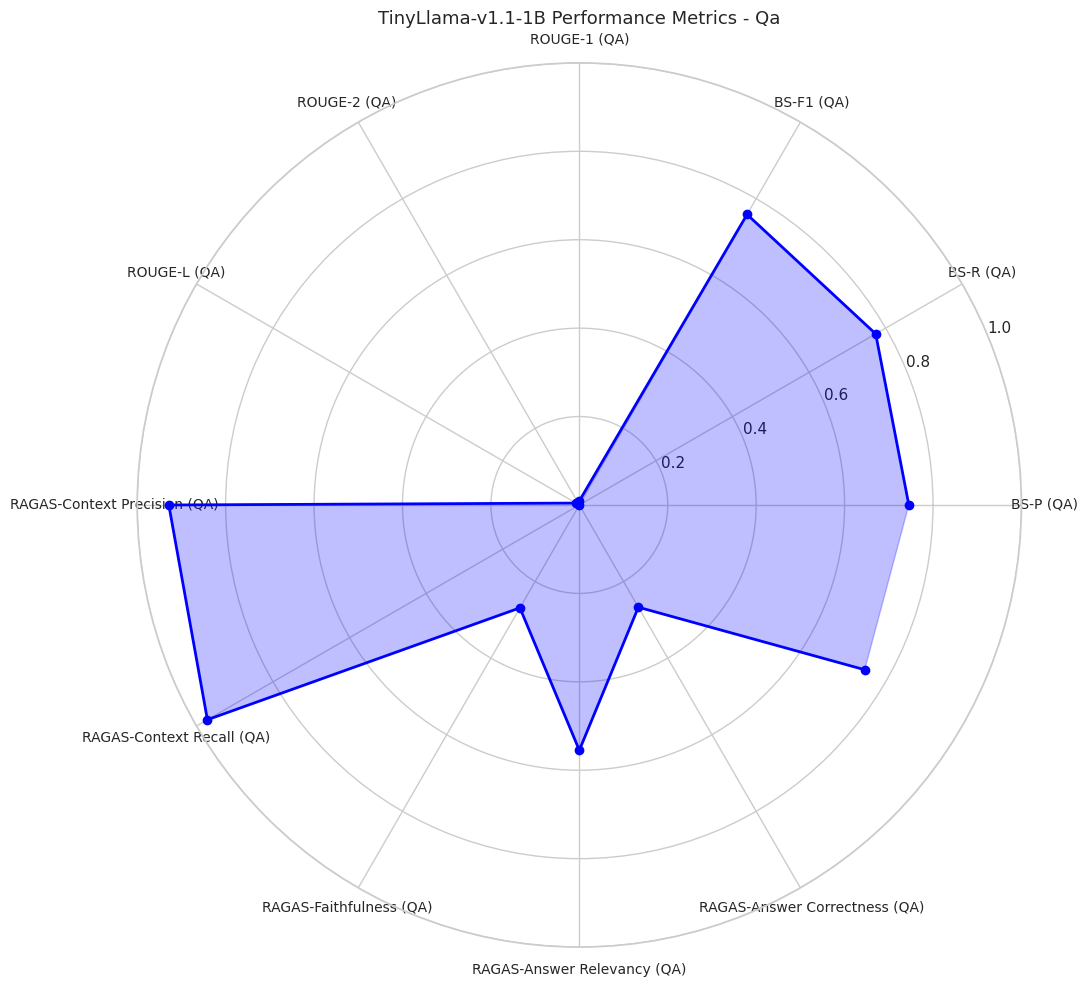

<Figure size 1200x800 with 0 Axes>

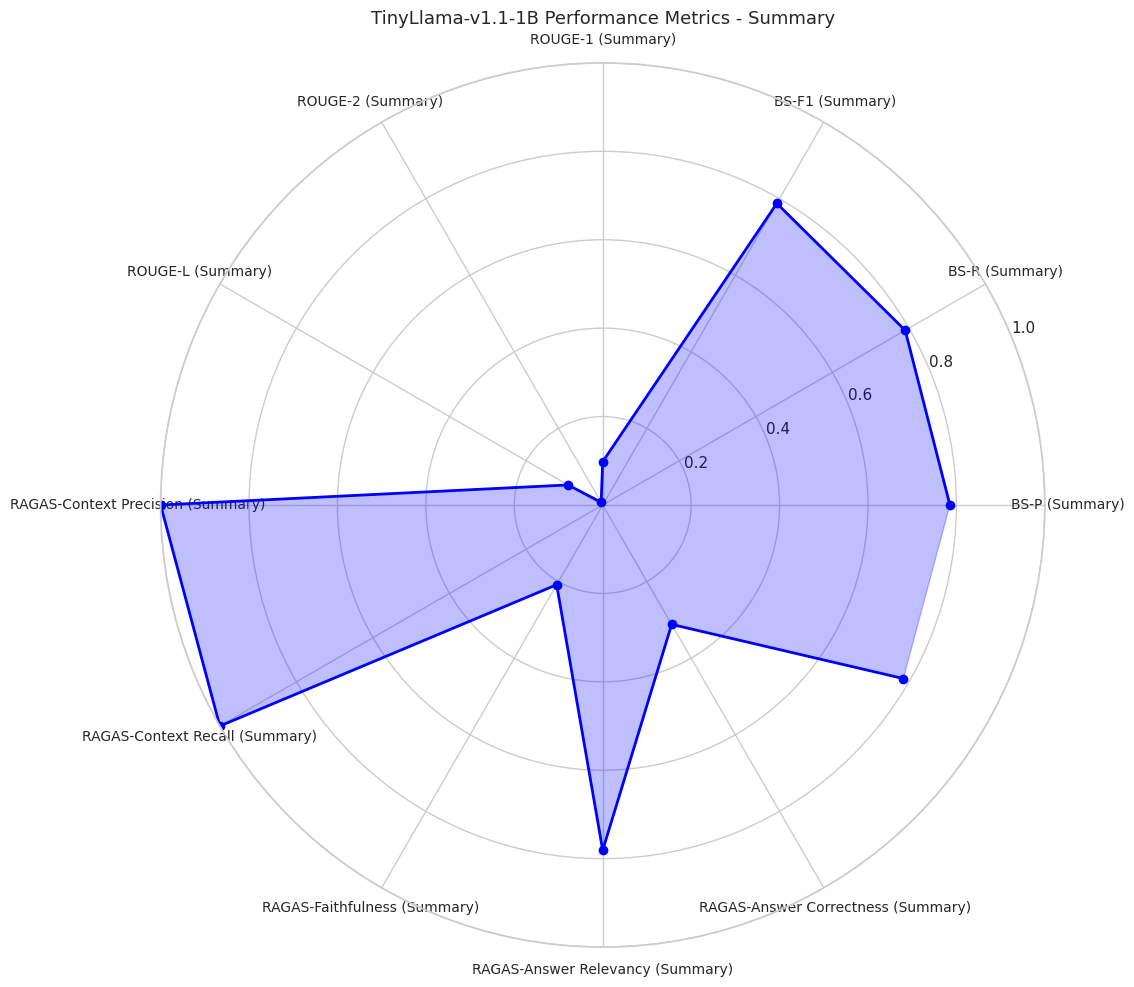

<Figure size 1200x800 with 0 Axes>

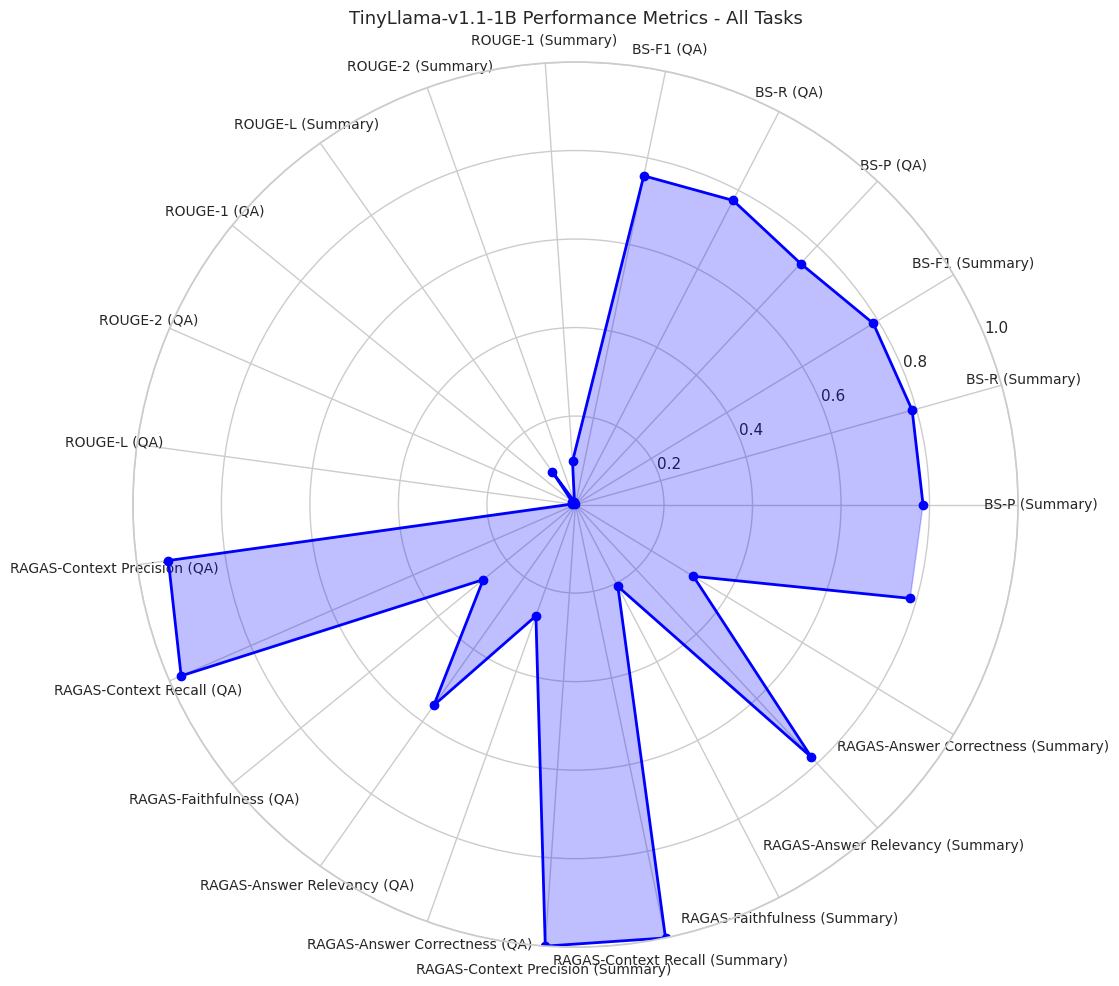

<Figure size 1200x800 with 0 Axes>

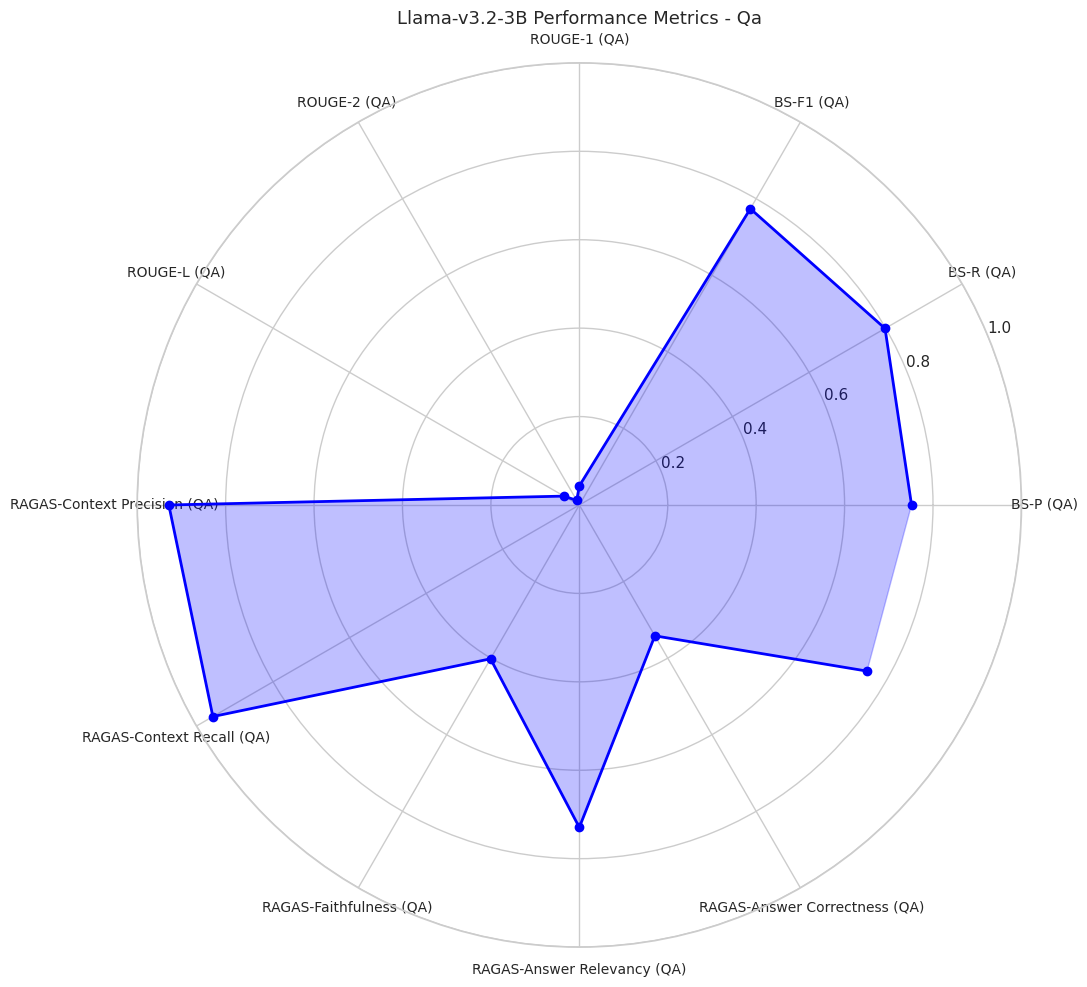

<Figure size 1200x800 with 0 Axes>

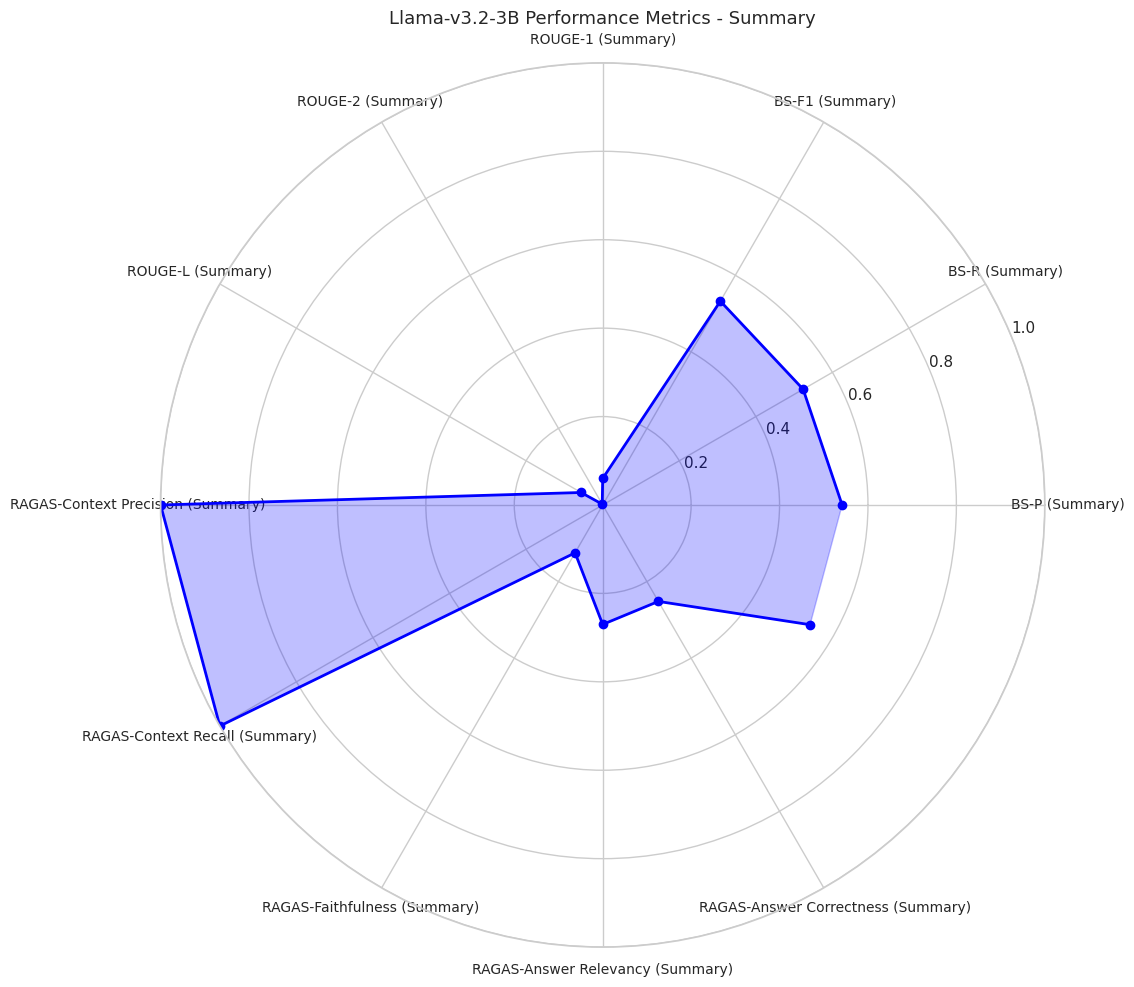

<Figure size 1200x800 with 0 Axes>

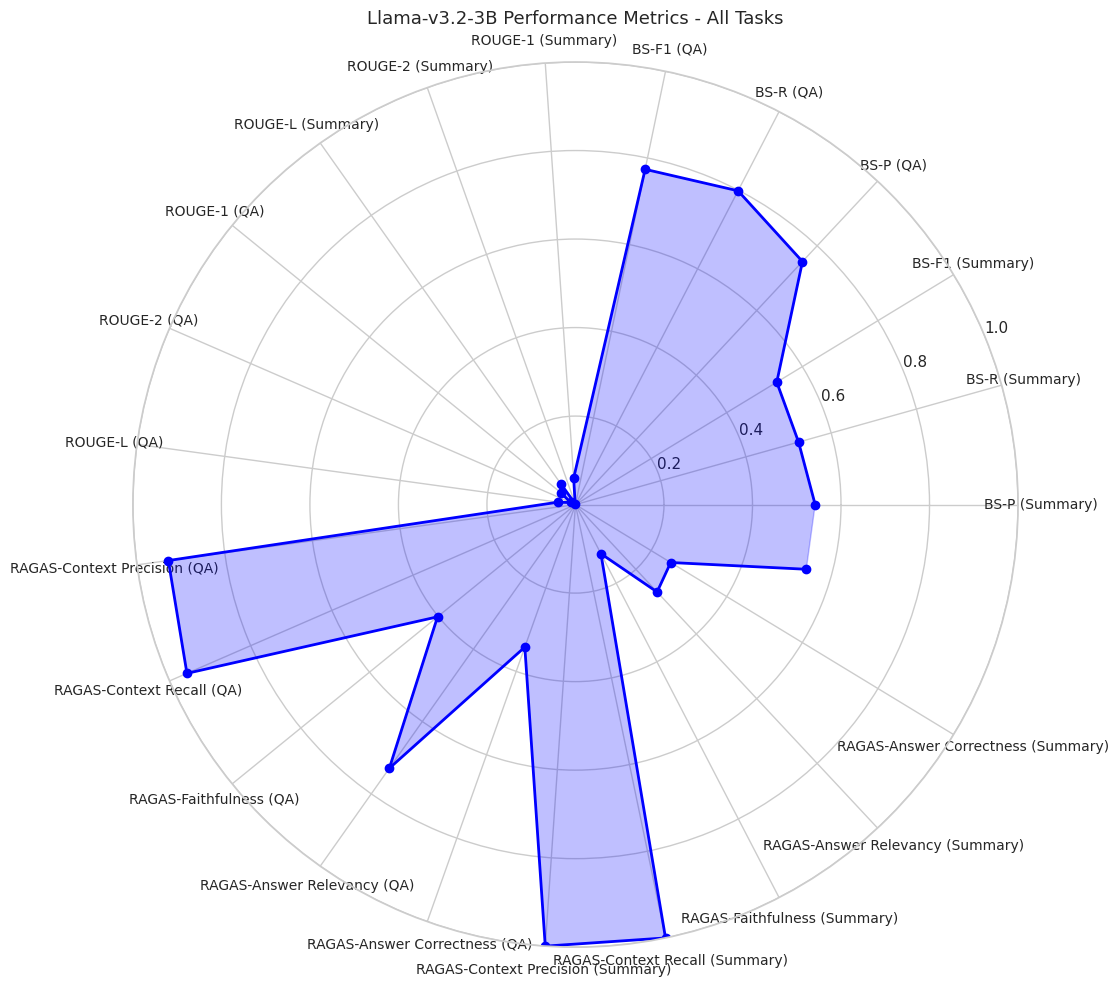

<Figure size 1200x800 with 0 Axes>

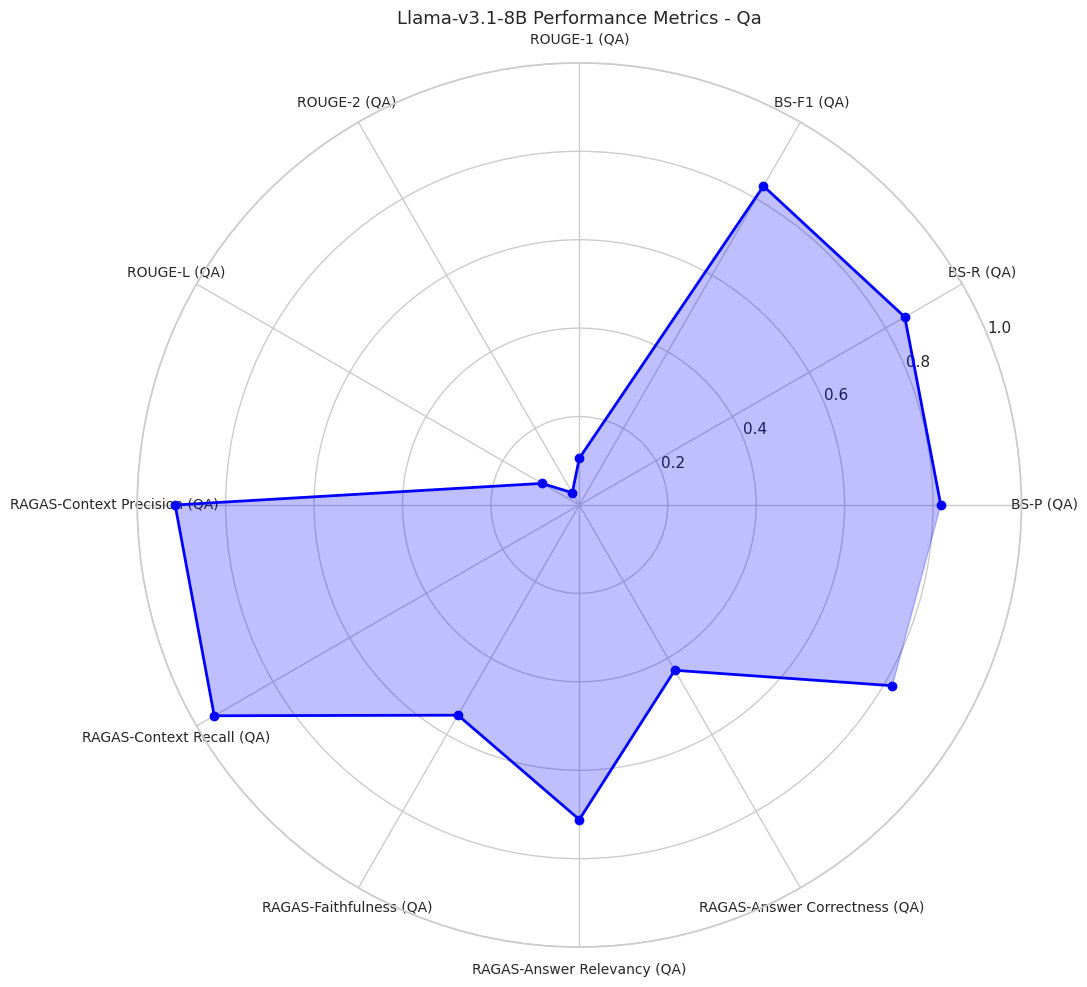

<Figure size 1200x800 with 0 Axes>

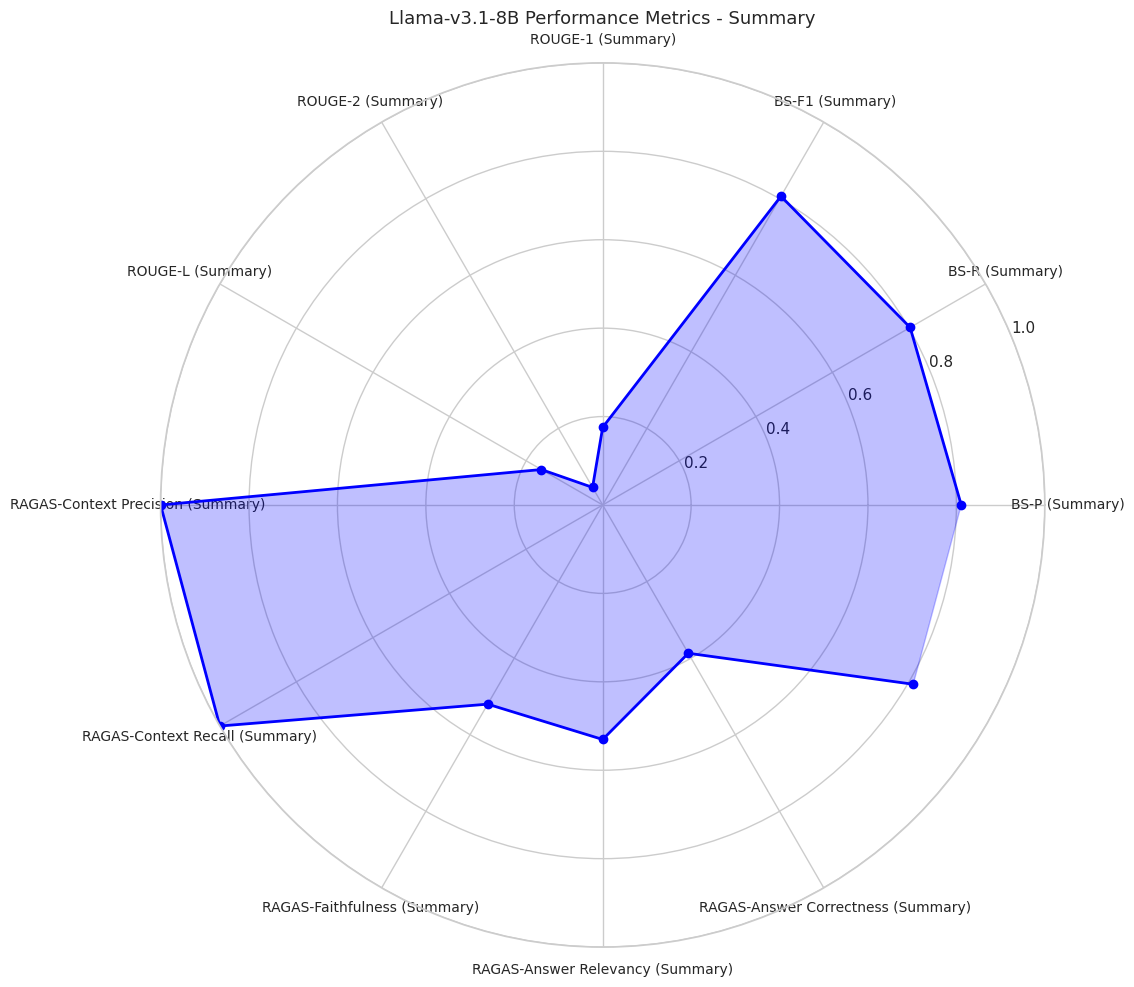

<Figure size 1200x800 with 0 Axes>

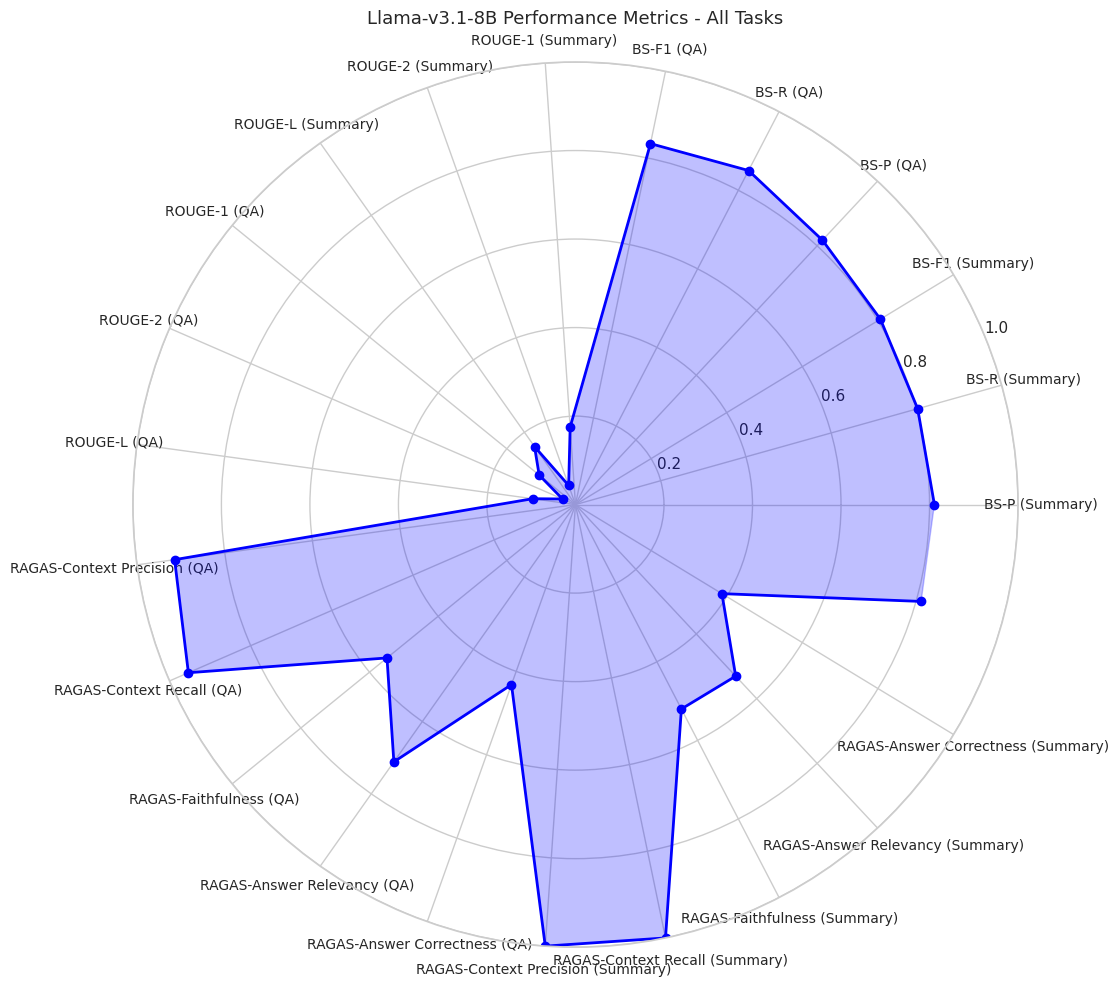

<Figure size 1200x800 with 0 Axes>

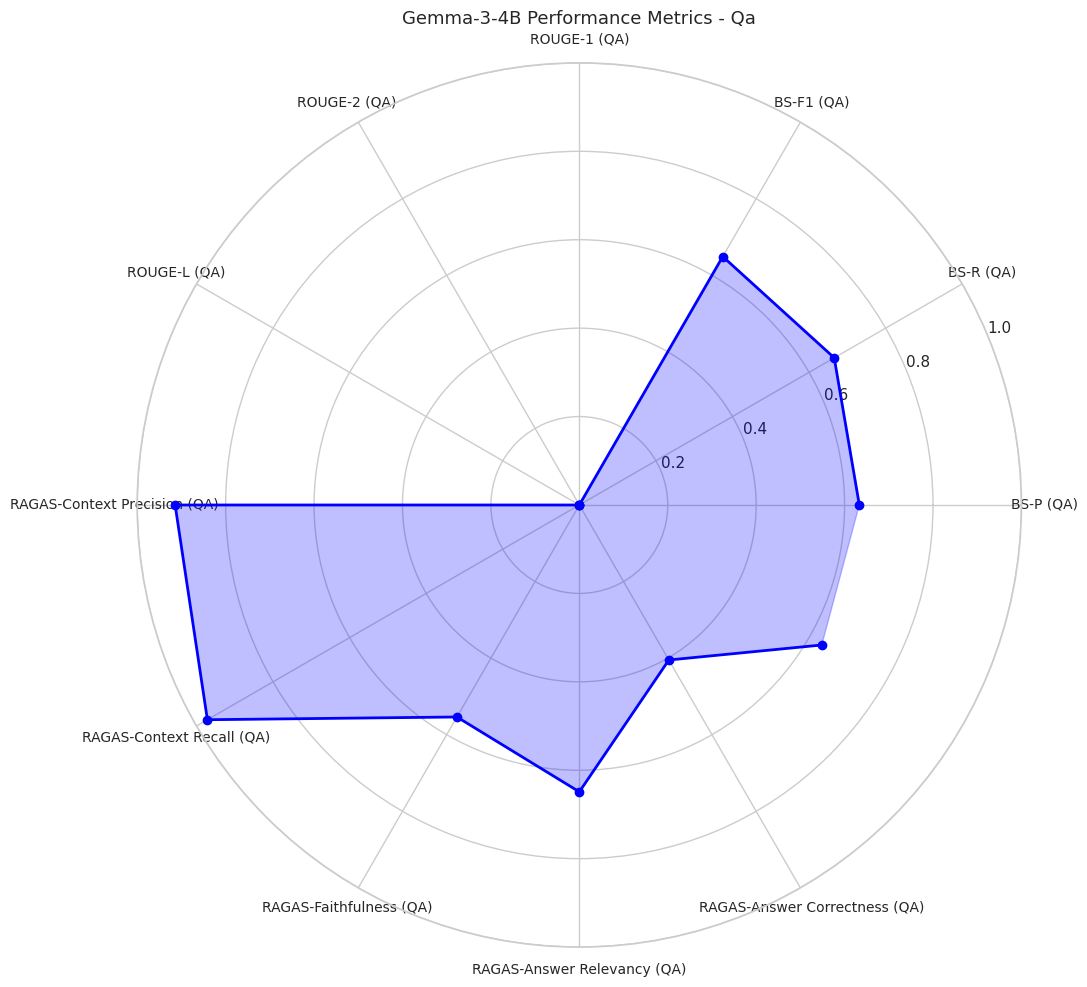

<Figure size 1200x800 with 0 Axes>

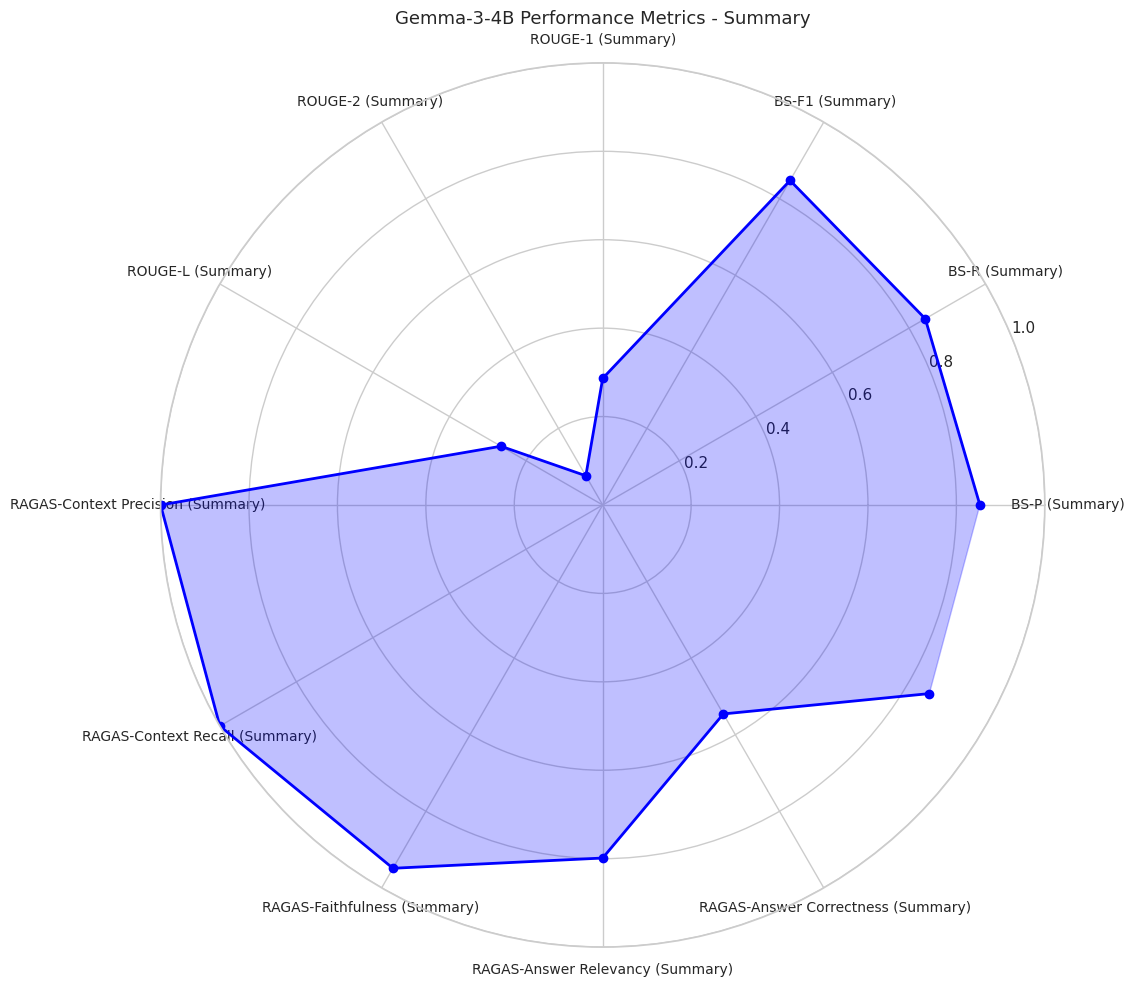

<Figure size 1200x800 with 0 Axes>

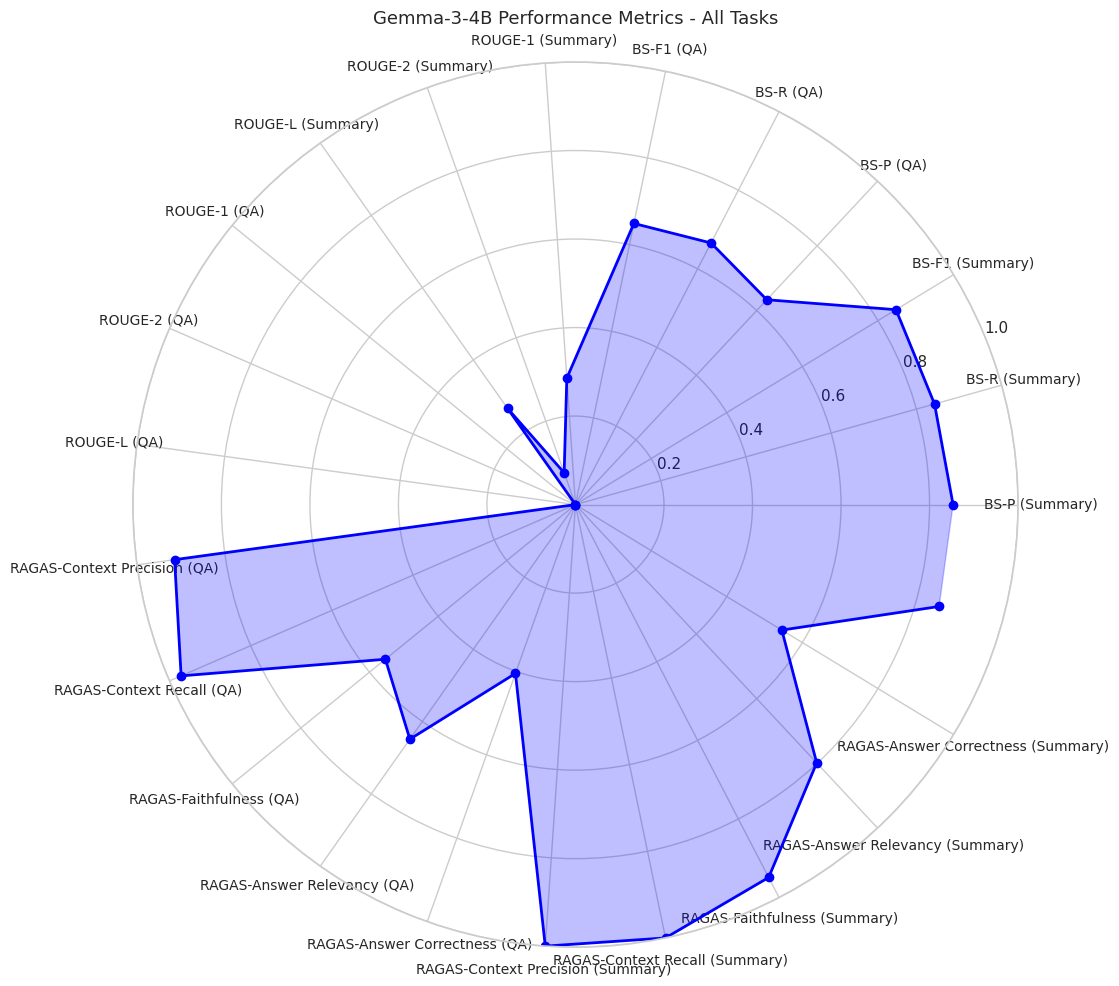

<Figure size 1200x800 with 0 Axes>

In [ ]:

# 1.Create radar charts for all models and tasks
for model in MODEL_NAMES:
    # Create chart for QA task only
    create_radar_chart(all_results, model, "qa")

    # Create chart for summary task only
    create_radar_chart(all_results, model, "summary")

    # Create chart for all tasks combined
    create_radar_chart(all_results, model, "all")

 2. Model Size vs. Performance Scatter Plots

 Plotting model sizes against performance metrics to identify efficiency sweet spots.

In [ ]:
def extract_model_size(model_name):
    """Extract model size in billions from model name"""
    match = re.search(r'(\d+(\.\d+)?)B', model_name)
    if match:
        return float(match.group(1))
    return None

# Create model size vs. performance scatter plots
def create_size_performance_plot(results_dict, metric_type, specific_metric, task_type):
    """Create scatter plot of model size vs. specific performance metric"""

    # Collect data points
    model_sizes = []
    performance_values = []
    model_labels = []

    for model in MODEL_NAMES:
        model_size = extract_model_size(model)
        if model_size is None:
            print(f"Could not extract size for {model}, skipping")
            continue

        # Get the correct dataframe based on metric type
        if metric_type == "bertscore" or metric_type == "rouge":
            if model in results_dict[metric_type]:
                df = results_dict[metric_type][model]
                # Filter by task type
                task_df = df[df['task'] == task_type]
                if not task_df.empty and specific_metric in task_df.columns:
                    model_sizes.append(model_size)
                    performance_values.append(task_df[specific_metric].mean())
                    model_labels.append(model)
        elif metric_type == "ragas_qa" and task_type == "qa":
            if model in results_dict["ragas_qa"]:
                df = results_dict["ragas_qa"][model]
                if not df.empty and specific_metric in df.columns:
                    model_sizes.append(model_size)
                    performance_values.append(df[specific_metric].mean())
                    model_labels.append(model)
        elif metric_type == "ragas_summary" and task_type == "summary":
            if model in results_dict["ragas_summary"]:
                df = results_dict["ragas_summary"][model]
                if not df.empty and specific_metric in df.columns:
                    model_sizes.append(model_size)
                    performance_values.append(df[specific_metric].mean())
                    model_labels.append(model)

    # Create the plot if we have data
    if model_sizes and performance_values:
        plt.figure(figsize=(10, 6))

        # Scatter plot
        scatter = plt.scatter(model_sizes, performance_values, s=100,
                             c=[MODEL_COLORS.get(model, 'blue') for model in model_labels],
                             alpha=0.7)

        # Add model names as labels
        for i, model in enumerate(model_labels):
            plt.annotate(model, (model_sizes[i], performance_values[i]),
                        textcoords="offset points", xytext=(0, 10), ha='center')

        # Connect points with a line
        plt.plot(model_sizes, performance_values, '--', color='gray', alpha=0.5)

        # Add labels and title
        plt.xlabel('Model Size (Billion Parameters)')
        plt.ylabel(f'{specific_metric}')
        plt.title(f'Model Size vs. {specific_metric} for {task_type.title()} Task')

        # Add grid
        plt.grid(True, linestyle='--', alpha=0.7)

        # Save the figure
        plt.tight_layout()
        plt.savefig(f"size_vs_{specific_metric}_{task_type}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Not enough data for model size vs. {specific_metric} plot for {task_type} task")

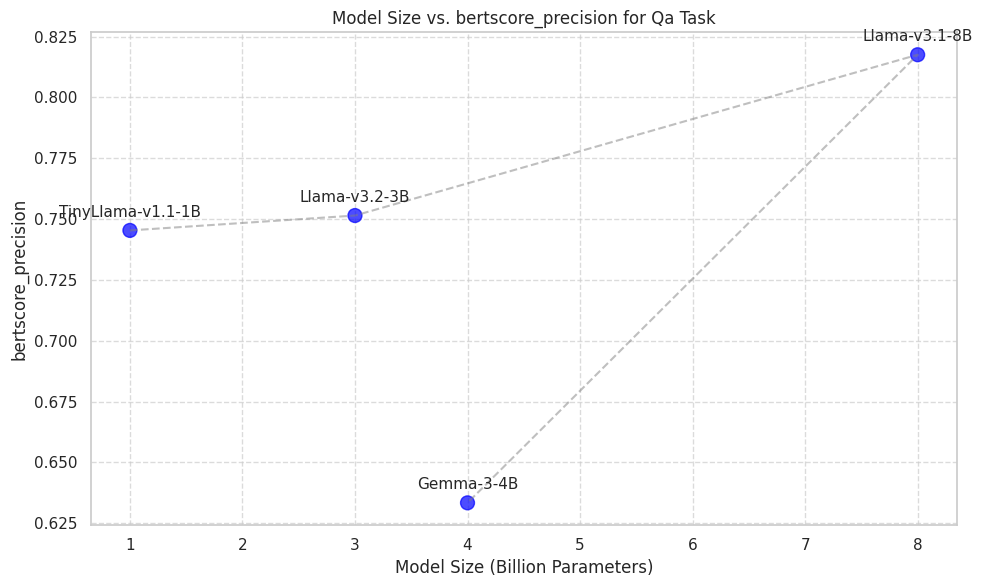

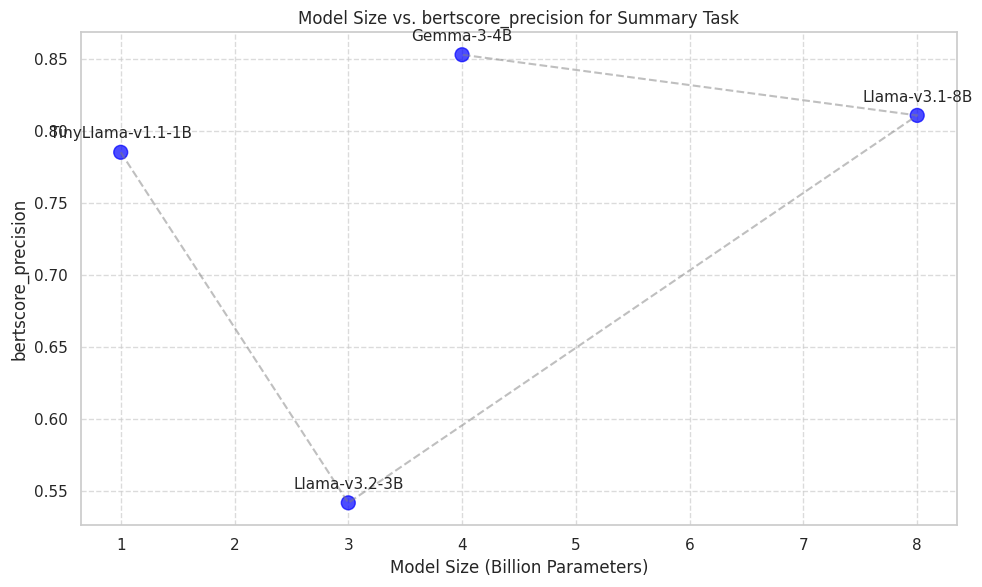

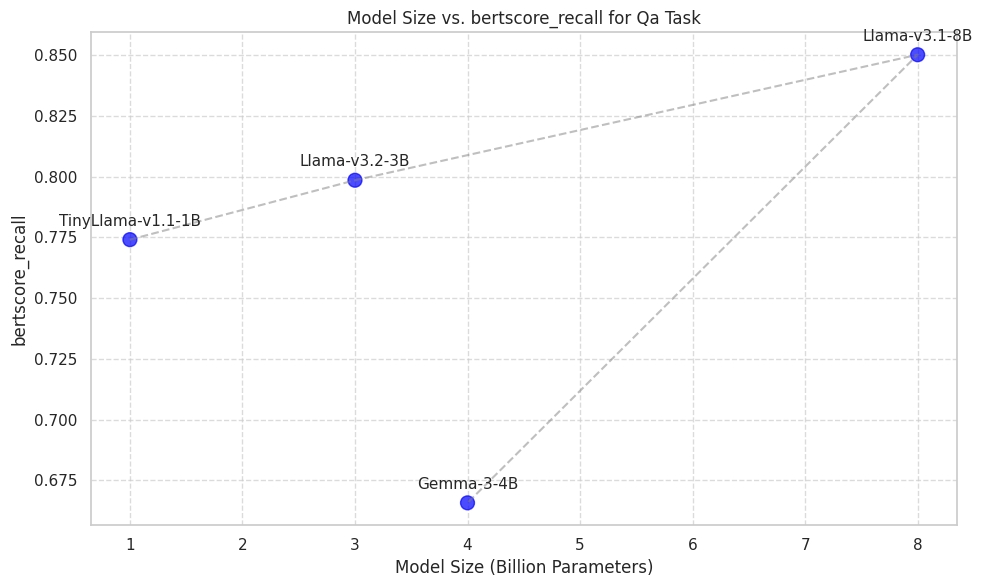

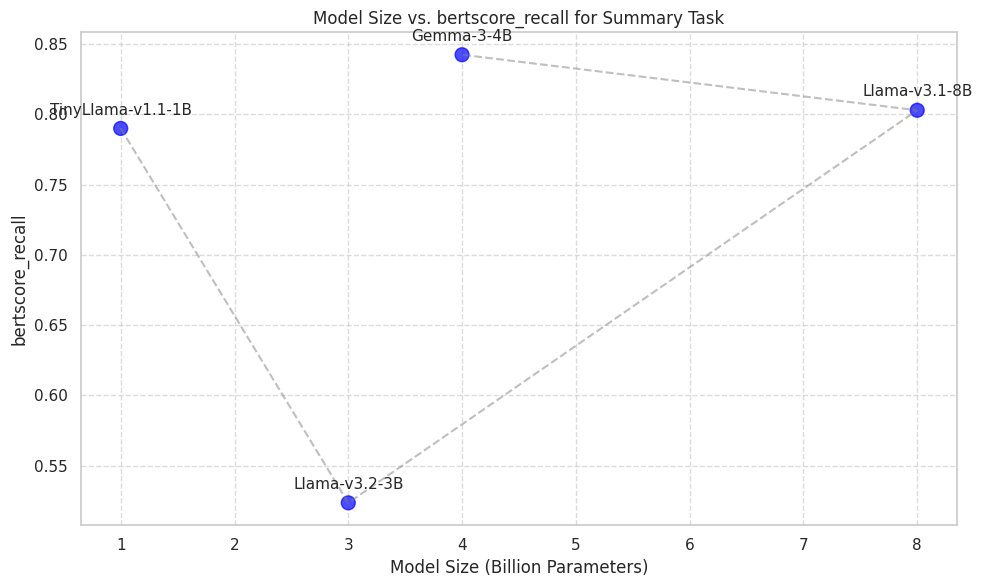

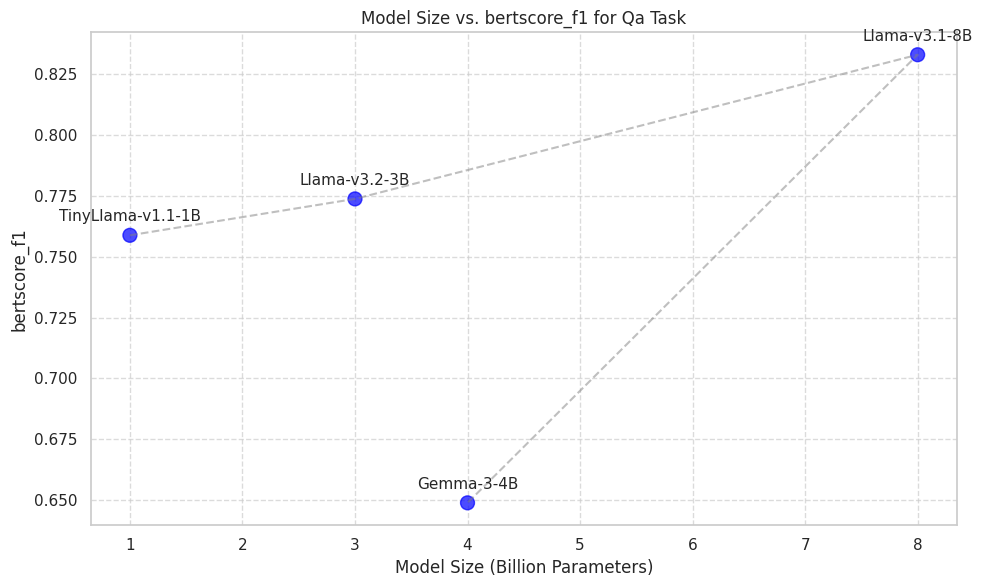

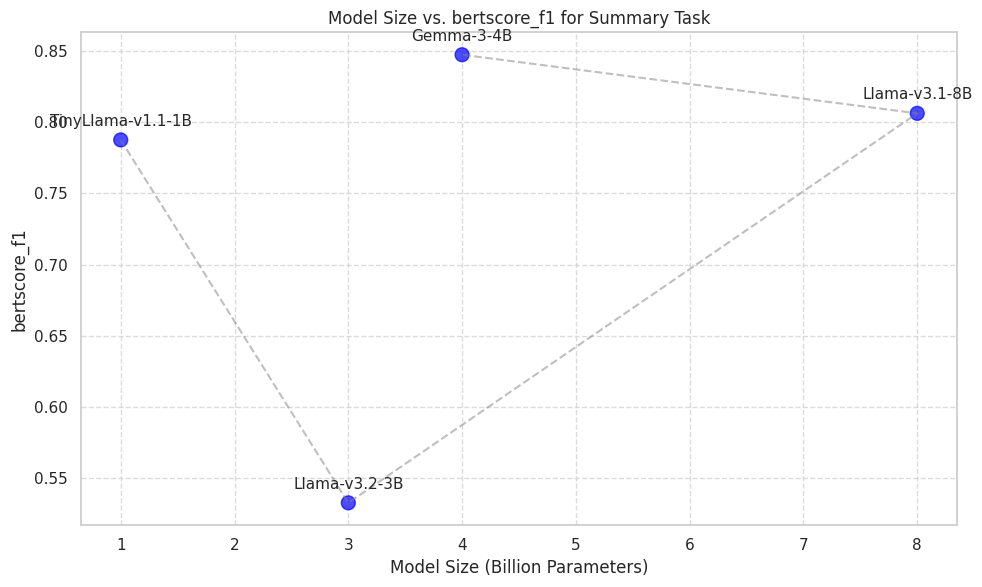

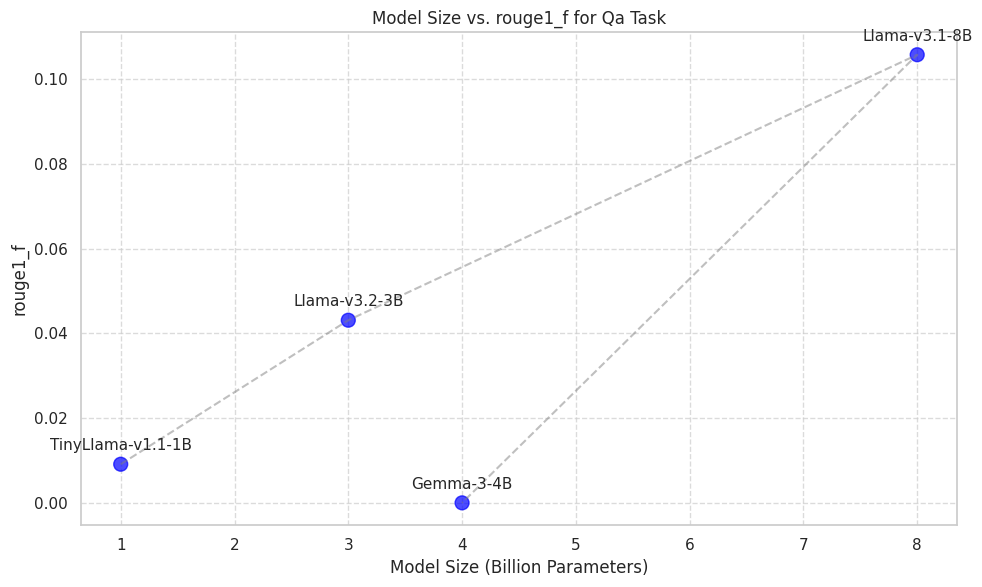

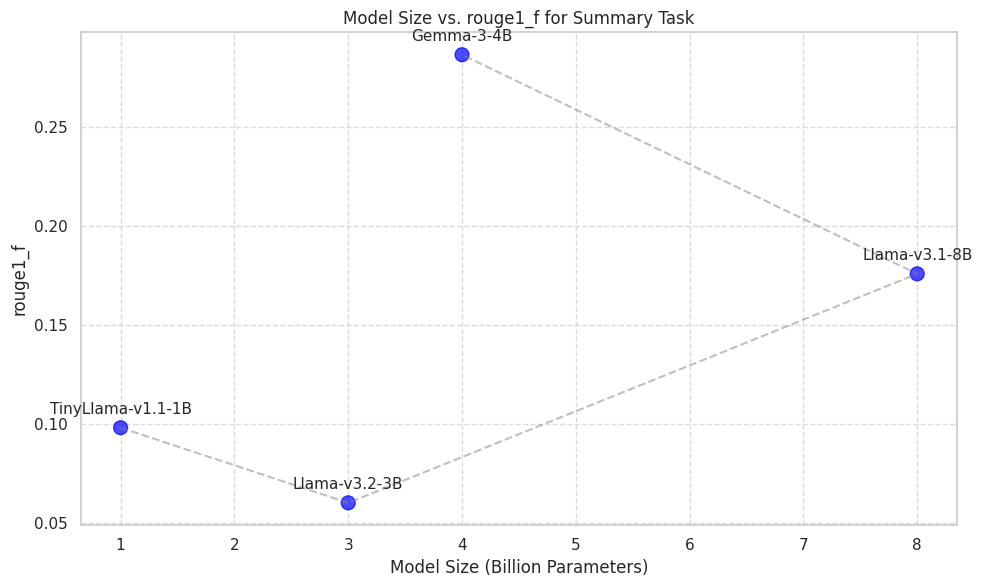

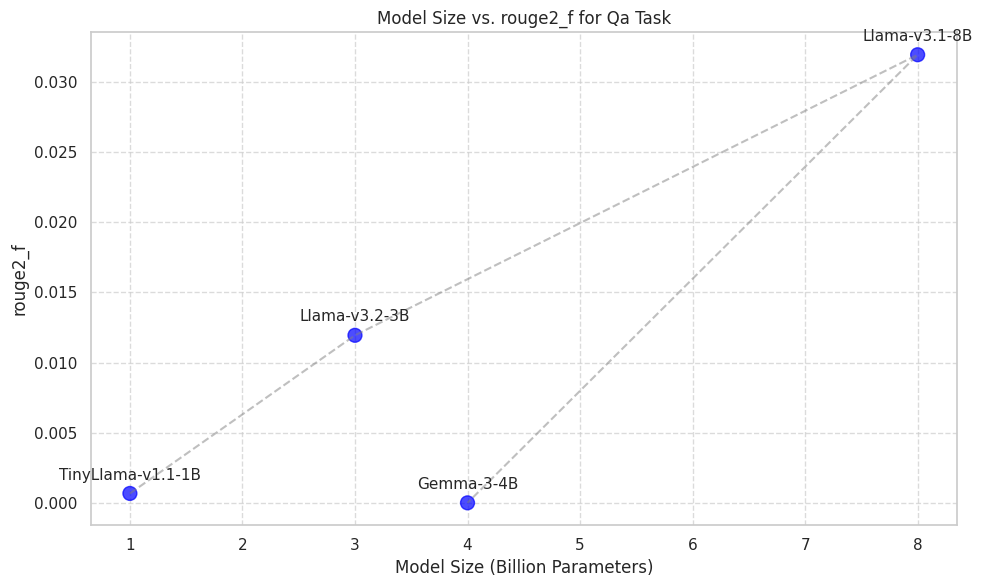

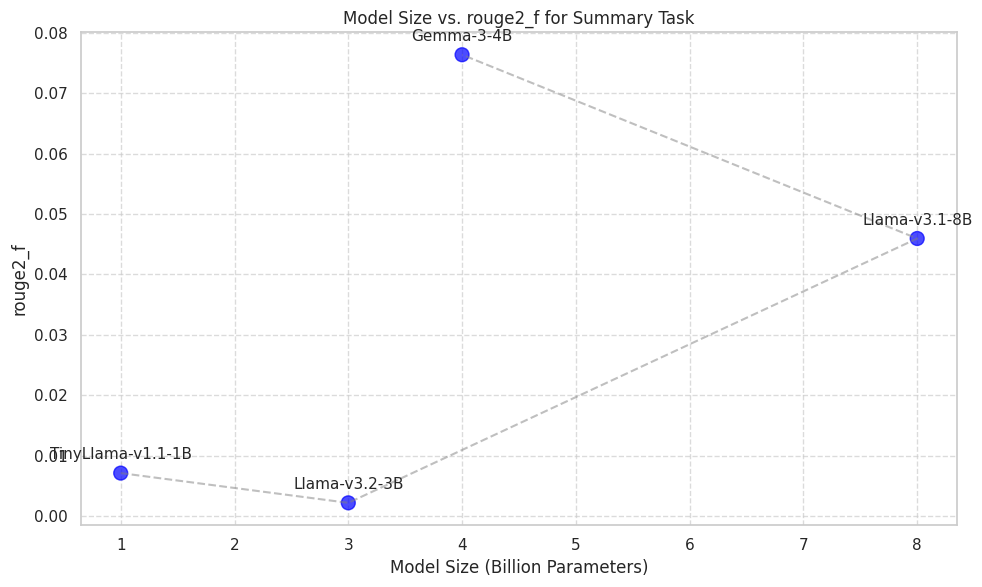

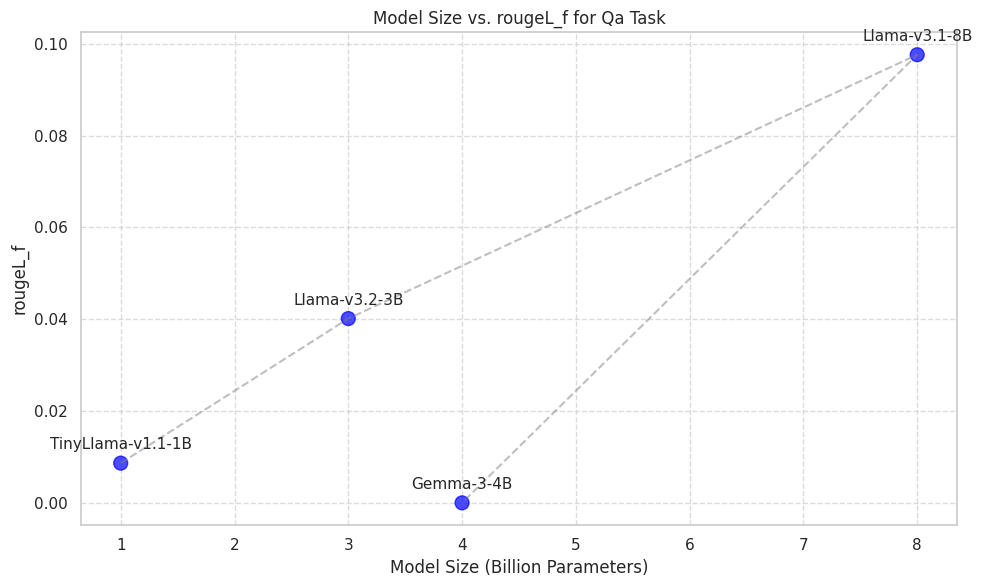

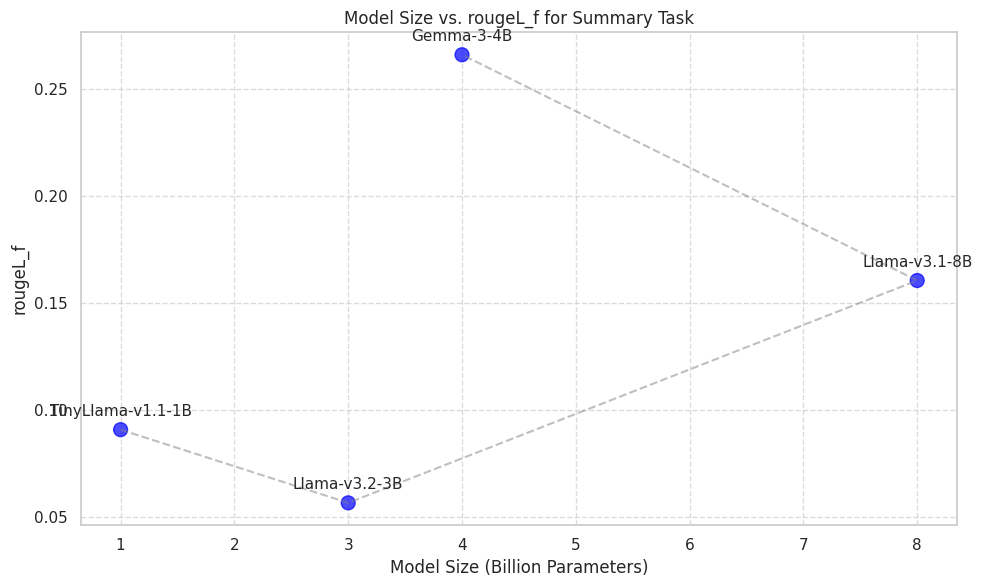

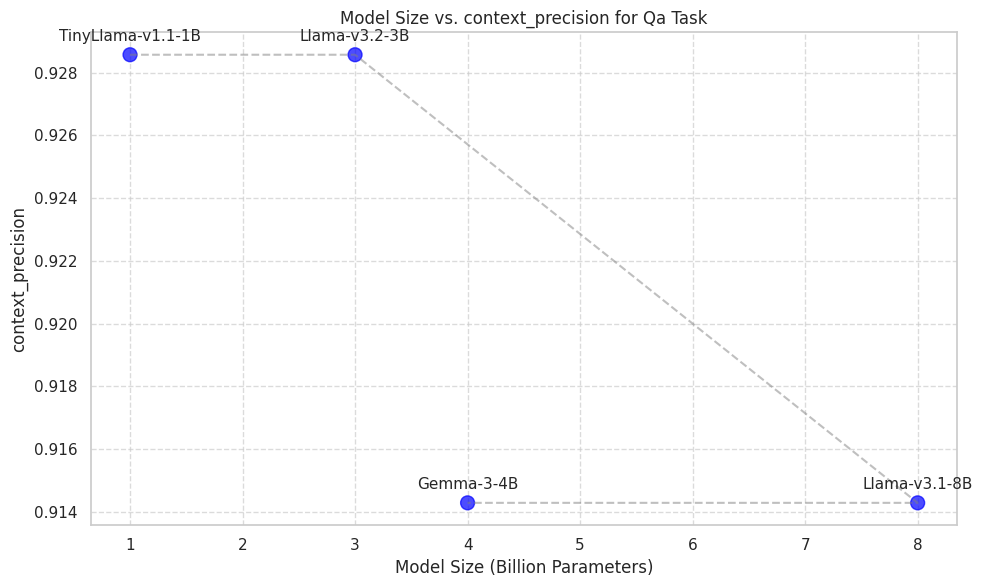

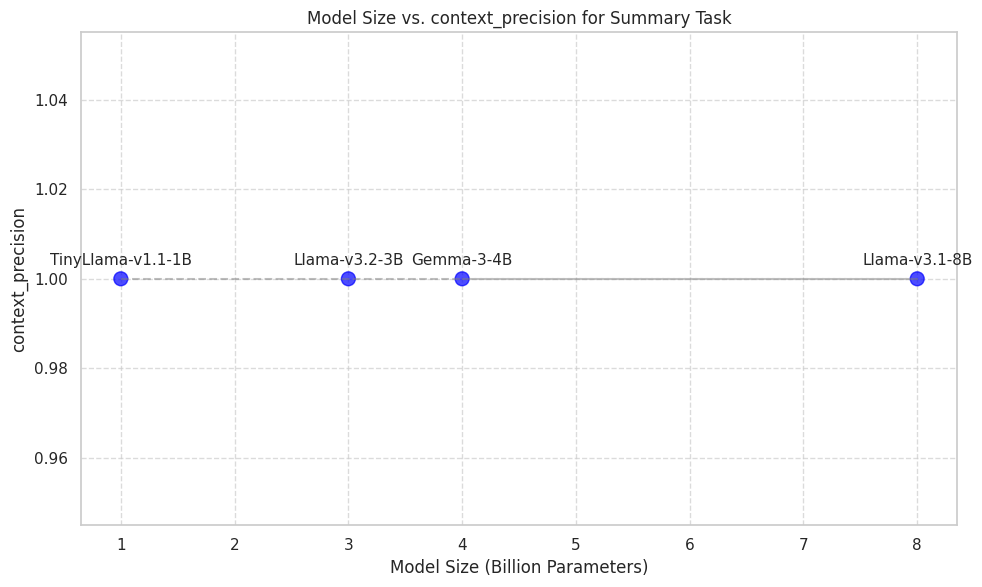

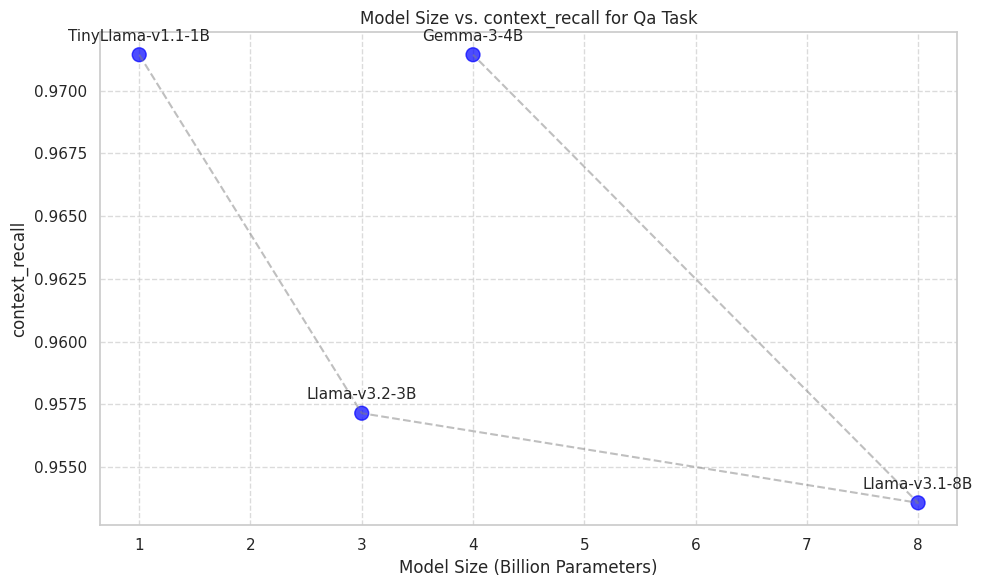

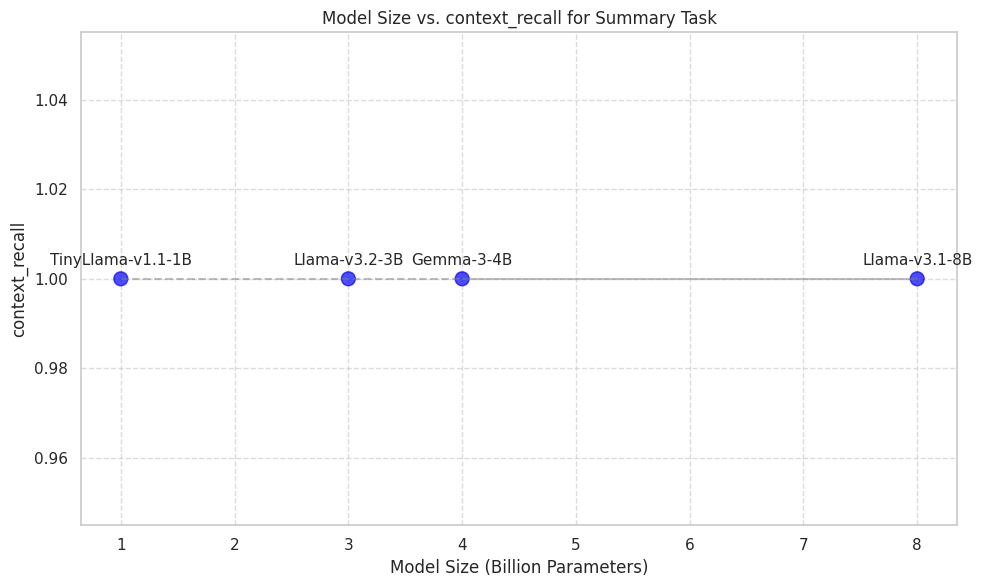

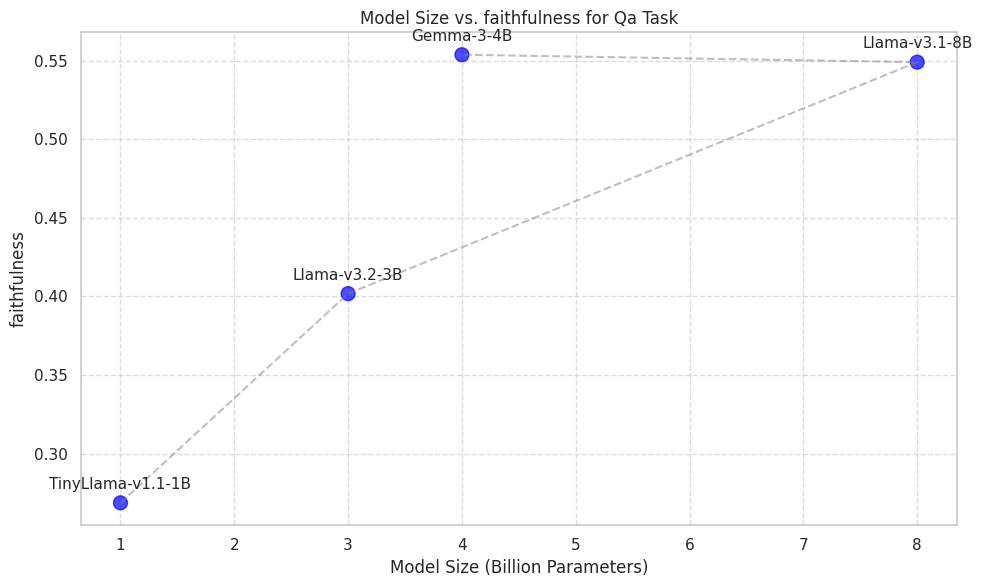

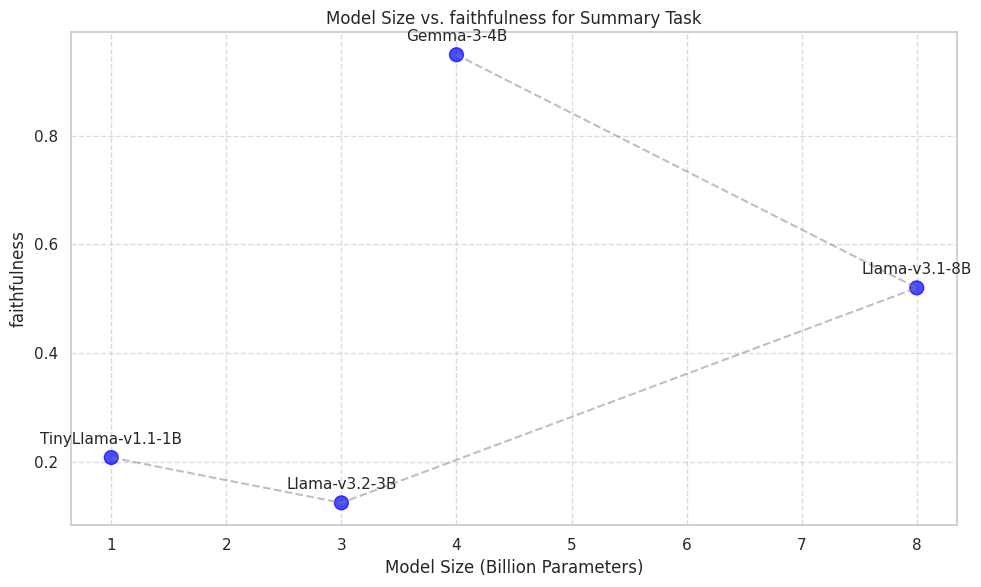

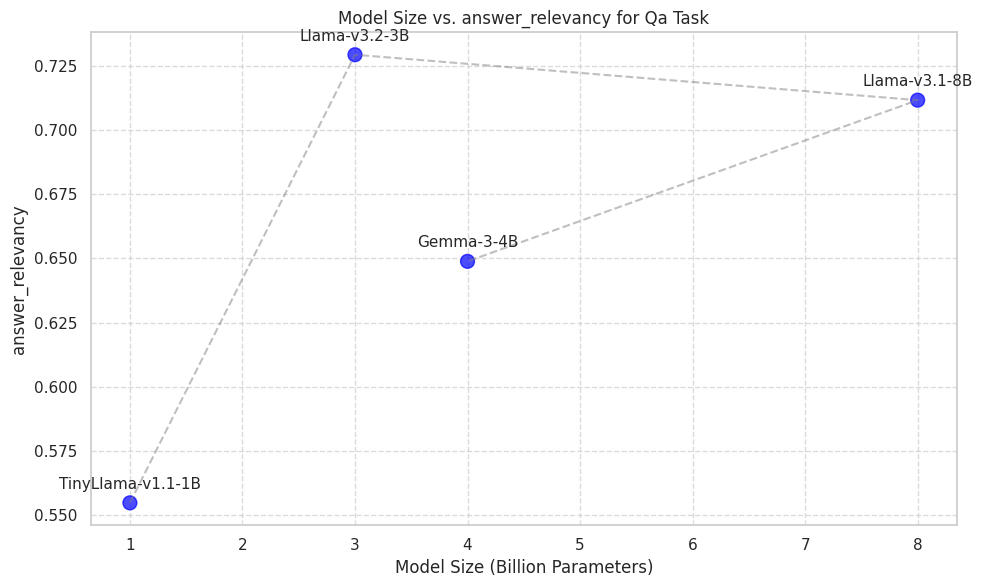

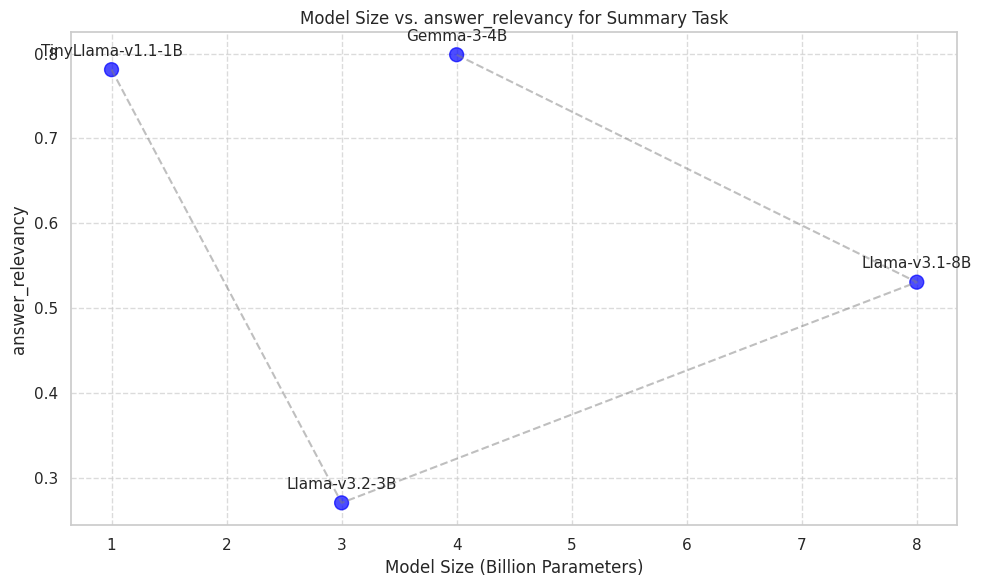

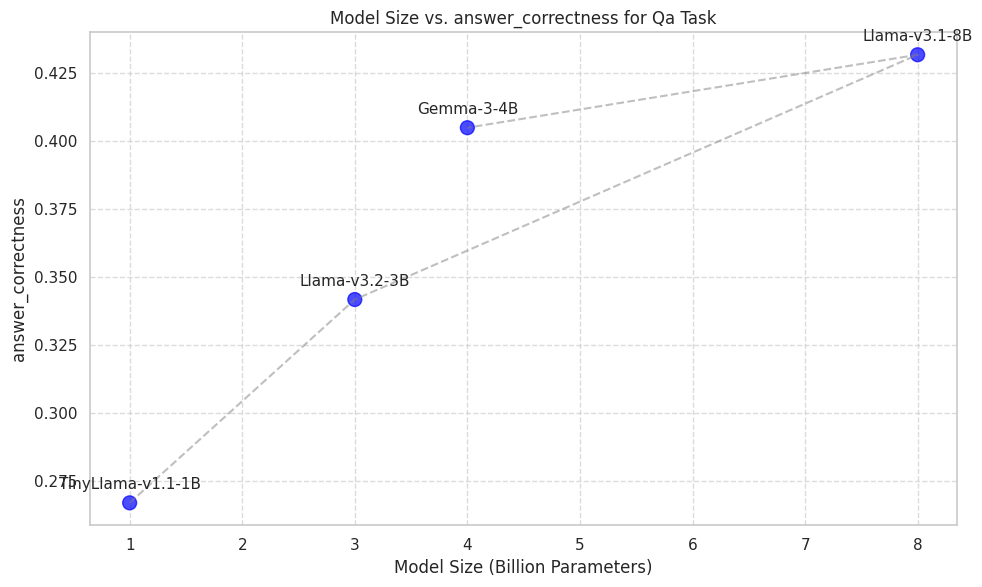

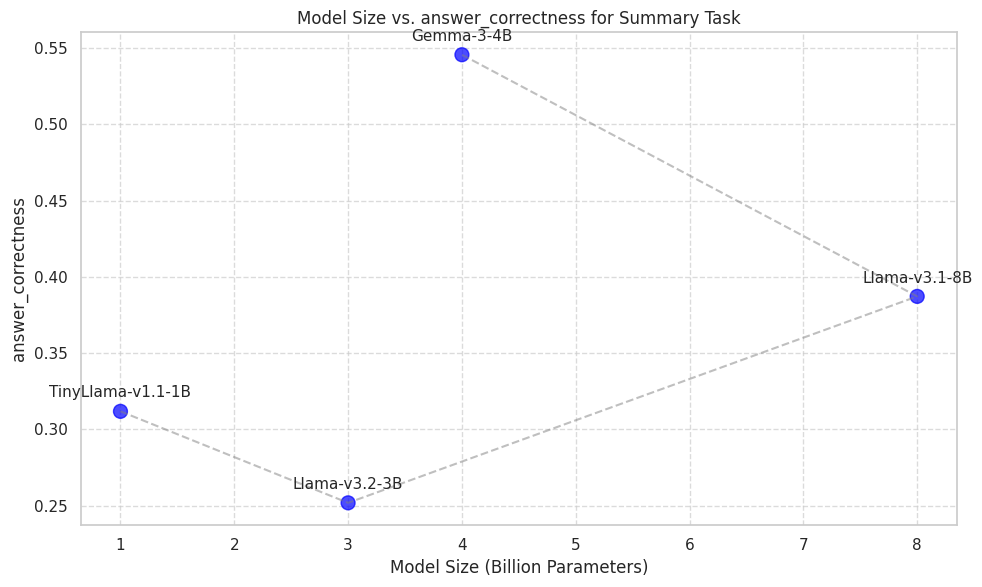

In [ ]:
# 2. Create plots for various metrics
# BERTScore metrics
bertscore_metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1']
for metric in bertscore_metrics:
    create_size_performance_plot(all_results, "bertscore", metric, "qa")
    create_size_performance_plot(all_results, "bertscore", metric, "summary")

# ROUGE metrics
rouge_metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']
for metric in rouge_metrics:
    create_size_performance_plot(all_results, "rouge", metric, "qa")
    create_size_performance_plot(all_results, "rouge", metric, "summary")

# RAGAS metrics
ragas_metrics = ['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy', 'answer_correctness']
for metric in ragas_metrics:
    create_size_performance_plot(all_results, "ragas_qa", metric, "qa")
    create_size_performance_plot(all_results, "ragas_summary", metric, "summary")


 3. Heatmap of Metric Scores

 Creating a heatmap with models as rows and metrics as columns, color-coded by performance.

In [ ]:
# Create heatmap of metric scores
def create_metric_heatmap(results_dict, task_type):
    """Create a heatmap showing model performance across multiple metrics"""

    # Collect data for the heatmap
    heatmap_data = {}
    all_metrics = []

    # Process BERTScore metrics
    bertscore_metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1']
    for model in MODEL_NAMES:
        heatmap_data[model] = {}

        # BERTScore
        if model in results_dict["bertscore"]:
            df = results_dict["bertscore"][model]
            task_df = df[df['task'] == task_type]
            if not task_df.empty:
                for metric in bertscore_metrics:
                    if metric in task_df.columns:
                        metric_name = f"{metric.replace('bertscore_', 'BS-').upper()}"
                        heatmap_data[model][metric_name] = task_df[metric].mean()
                        if metric_name not in all_metrics:
                            all_metrics.append(metric_name)

        # ROUGE
        if model in results_dict["rouge"]:
            df = results_dict["rouge"][model]
            task_df = df[df['task'] == task_type]
            if not task_df.empty:
                rouge_metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']
                for metric in rouge_metrics:
                    if metric in task_df.columns:
                        metric_name = f"{metric.upper()}"
                        heatmap_data[model][metric_name] = task_df[metric].mean()
                        if metric_name not in all_metrics:
                            all_metrics.append(metric_name)

        # RAGAS
        ragas_type = "ragas_qa" if task_type == "qa" else "ragas_summary"
        if model in results_dict[ragas_type]:
            df = results_dict[ragas_type][model]
            if not df.empty:
                ragas_metrics = ['context_precision', 'context_recall', 'faithfulness',
                                'answer_relevancy', 'answer_correctness']
                for metric in ragas_metrics:
                    if metric in df.columns:
                        metric_name = f"RAGAS-{metric.replace('_', '-')}"
                        heatmap_data[model][metric_name] = df[metric].mean()
                        if metric_name not in all_metrics:
                            all_metrics.append(metric_name)

    # Convert to DataFrame for heatmap
    heatmap_df = pd.DataFrame(index=MODEL_NAMES, columns=all_metrics)
    for model in MODEL_NAMES:
        for metric in all_metrics:
            if metric in heatmap_data[model]:
                heatmap_df.loc[model, metric] = heatmap_data[model][metric]
                heatmap_df = heatmap_df.apply(pd.to_numeric, errors='coerce')
            else:
                heatmap_df.loc[model, metric] = np.nan

    # Create the heatmap
    plt.figure(figsize=(15, len(MODEL_NAMES) * 1.5))

    # Plot heatmap
    sns.heatmap(heatmap_df, annot=True, cmap="YlGnBu", fmt=".3f",
                linewidths=0.5, cbar_kws={"label": "Score Value"})

    plt.title(f"Model Performance Heatmap - {task_type.title()} Task", fontsize=16)
    plt.ylabel("Model")
    plt.tight_layout()

    # Save the figure
    plt.savefig(f"heatmap_{task_type}.png", dpi=300, bbox_inches='tight')
    plt.show()

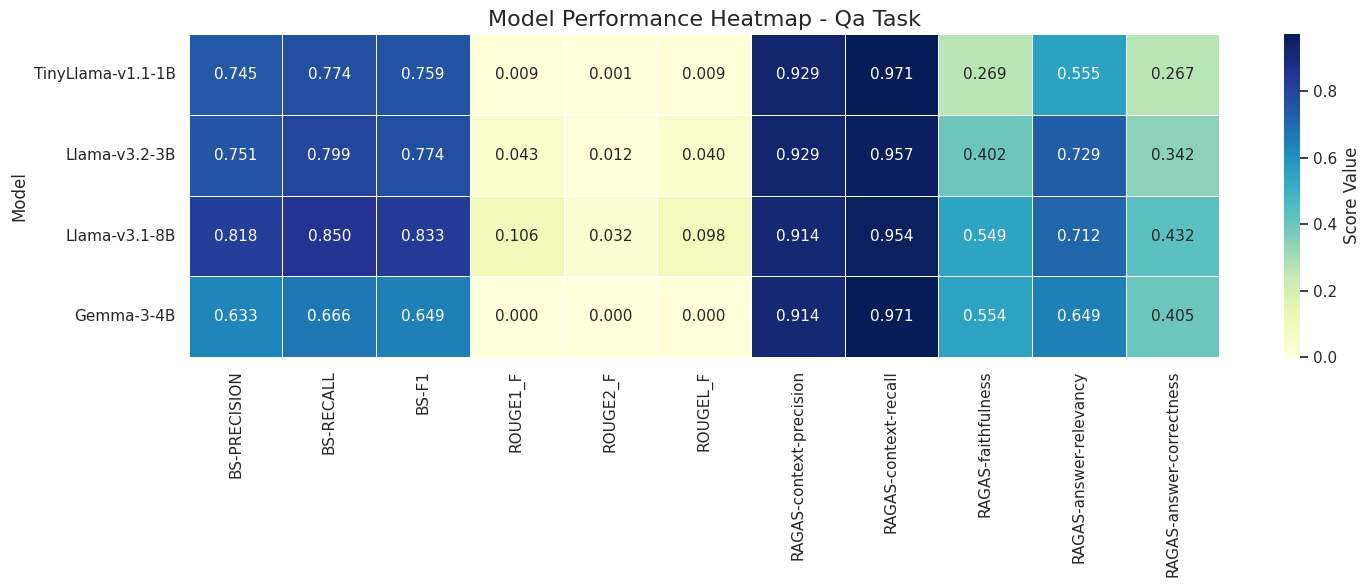

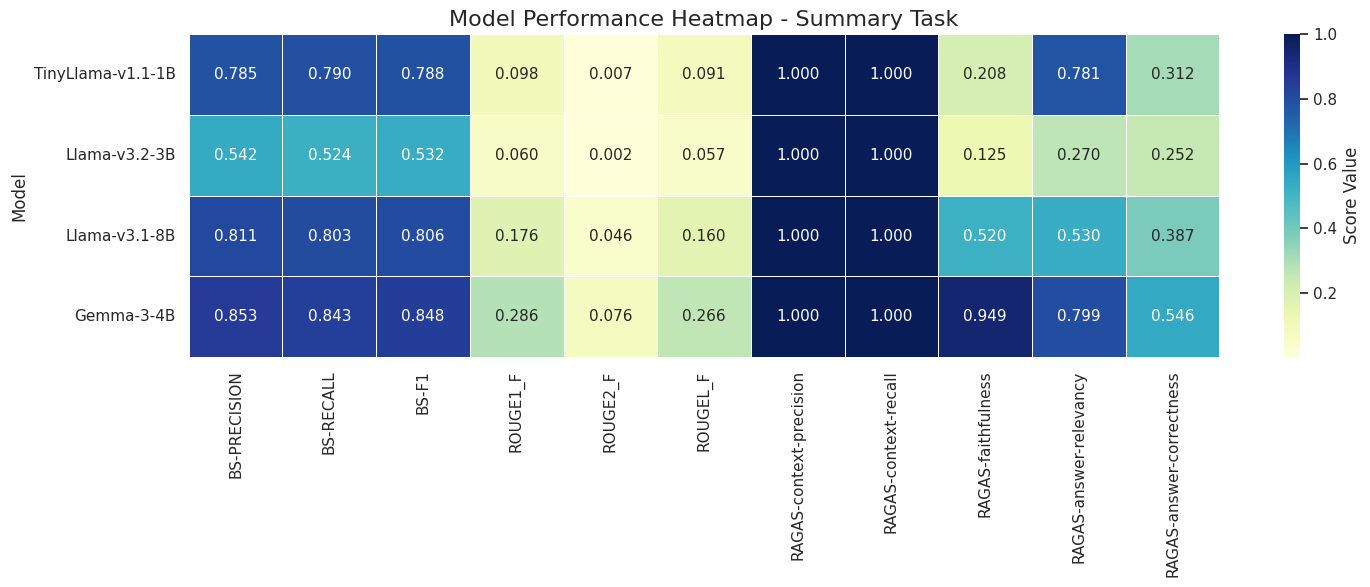

In [ ]:
# 3. Create heatmaps for both tasks
create_metric_heatmap(all_results, "qa")
create_metric_heatmap(all_results, "summary")

 4. Box Plots for Consistency Analysis

 Using box plots to show not just average performance but also consistency across different source materials.

In [ ]:
# Create box plots for consistency analysis
def create_consistency_boxplots(results_dict, metric_type, specific_metric, task_type):
    """Create box plots to show consistency of model performance across papers"""

    # Collect data for each model
    plot_data = []
    model_names = []

    for model in MODEL_NAMES:
        if metric_type == "bertscore" or metric_type == "rouge":
            if model in results_dict[metric_type]:
                df = results_dict[metric_type][model]
                # Filter by task type
                task_df = df[df['task'] == task_type]
                if not task_df.empty and specific_metric in task_df.columns:
                    # Get values for this model
                    values = task_df[specific_metric].values
                    if len(values) > 0:
                        plot_data.append(values)
                        model_names.append(model)

        elif metric_type == "ragas_qa" and task_type == "qa":
            if model in results_dict["ragas_qa"]:
                df = results_dict["ragas_qa"][model]
                if not df.empty and specific_metric in df.columns:
                    # Group by paper
                    if 'paper' in df.columns:
                        paper_groups = df.groupby('paper')[specific_metric]
                        values = []
                        for paper, group in paper_groups:
                            values.append(group.mean())
                        if values:
                            plot_data.append(values)
                            model_names.append(model)
                    else:
                        values = df[specific_metric].values
                        if len(values) > 0:
                            plot_data.append(values)
                            model_names.append(model)

        elif metric_type == "ragas_summary" and task_type == "summary":
            if model in results_dict["ragas_summary"]:
                df = results_dict["ragas_summary"][model]
                if not df.empty and specific_metric in df.columns:
                    # Group by paper
                    if 'paper' in df.columns:
                        paper_groups = df.groupby('paper')[specific_metric]
                        values = []
                        for paper, group in paper_groups:
                            values.append(group.mean())
                        if values:
                            plot_data.append(values)
                            model_names.append(model)
                    else:
                        values = df[specific_metric].values
                        if len(values) > 0:
                            plot_data.append(values)
                            model_names.append(model)

    # Create box plot if we have data
    if plot_data and model_names:
        plt.figure(figsize=(10, 6))

        # Create box plot
        box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,
                         showmeans=True, meanline=True)

        # Set colors for each model's box
        for i, model in enumerate(model_names):
            box['boxes'][i].set_facecolor(MODEL_COLORS.get(model, 'lightblue'))

        # Set labels and title
        metric_display = specific_metric.replace('_', ' ').title()
        plt.ylabel(metric_display)
        plt.title(f'Consistency of {metric_display} Across Papers - {task_type.title()} Task')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Improve appearance
        plt.tight_layout()

        # Save the figure
        plt.savefig(f"boxplot_{specific_metric}_{task_type}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Not enough data for box plot of {specific_metric} on {task_type} task")

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


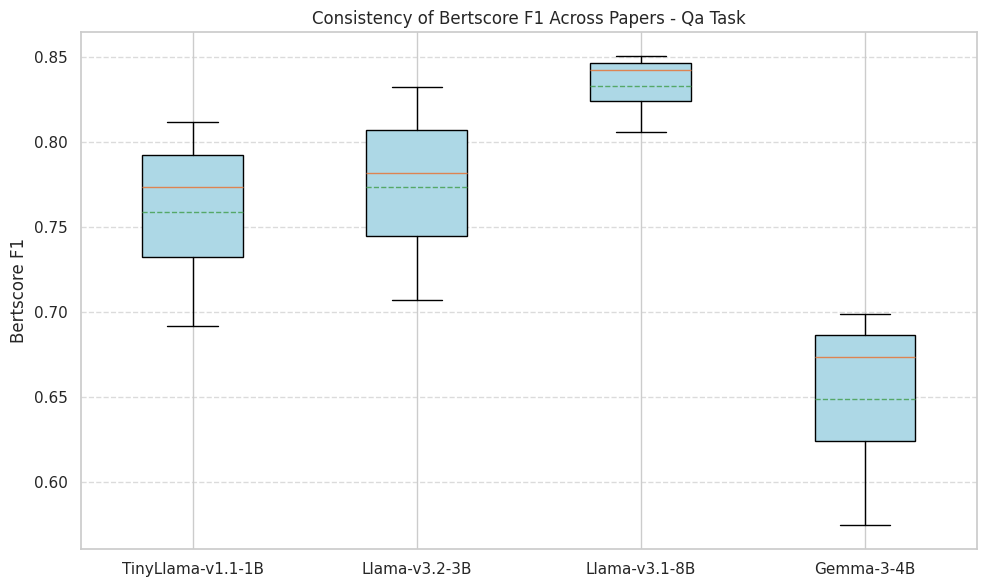

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


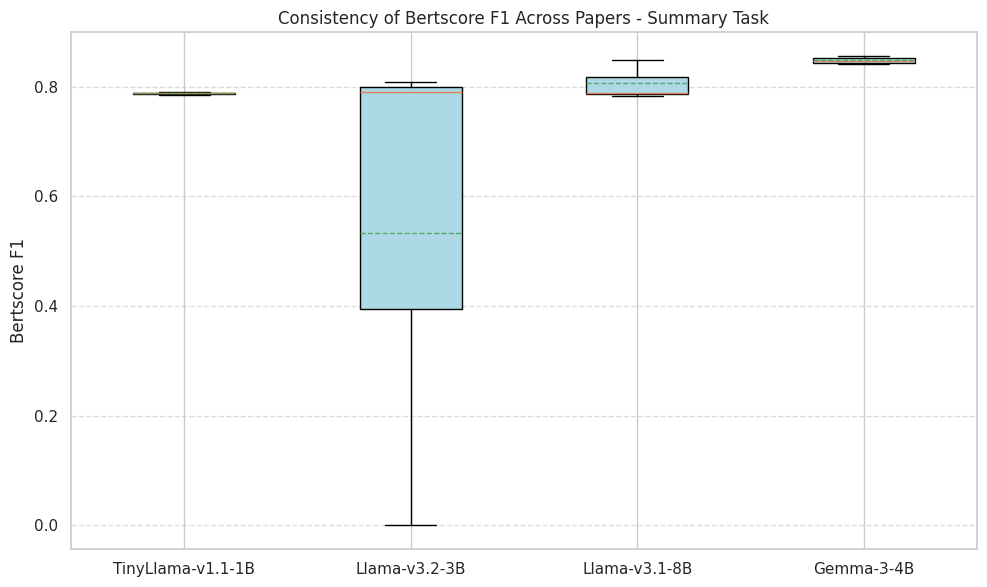

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


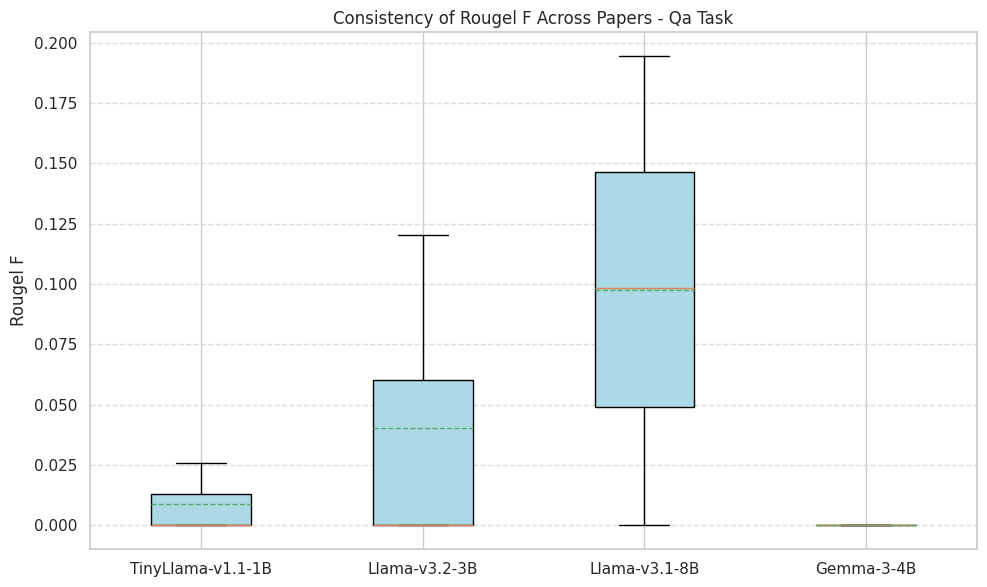

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


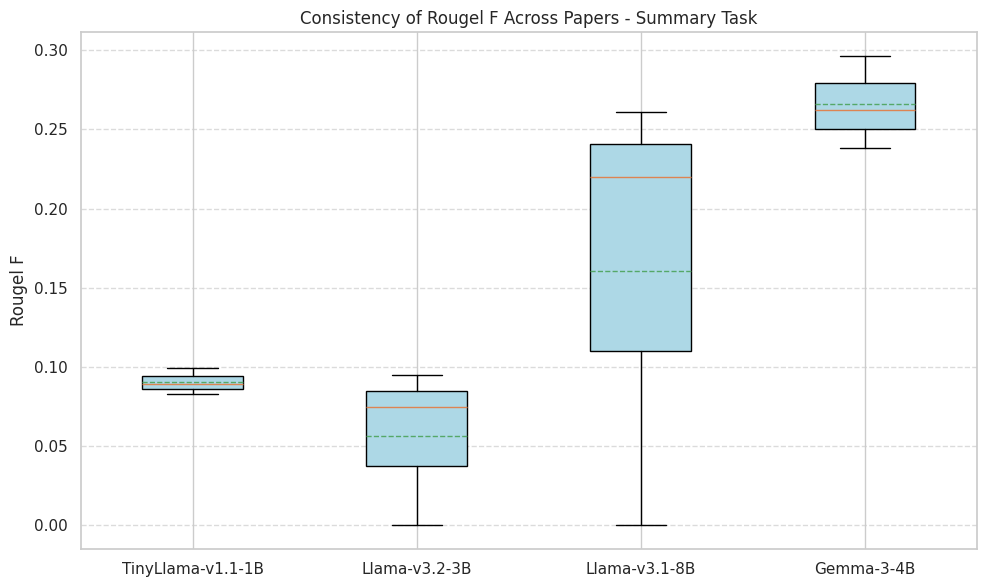

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


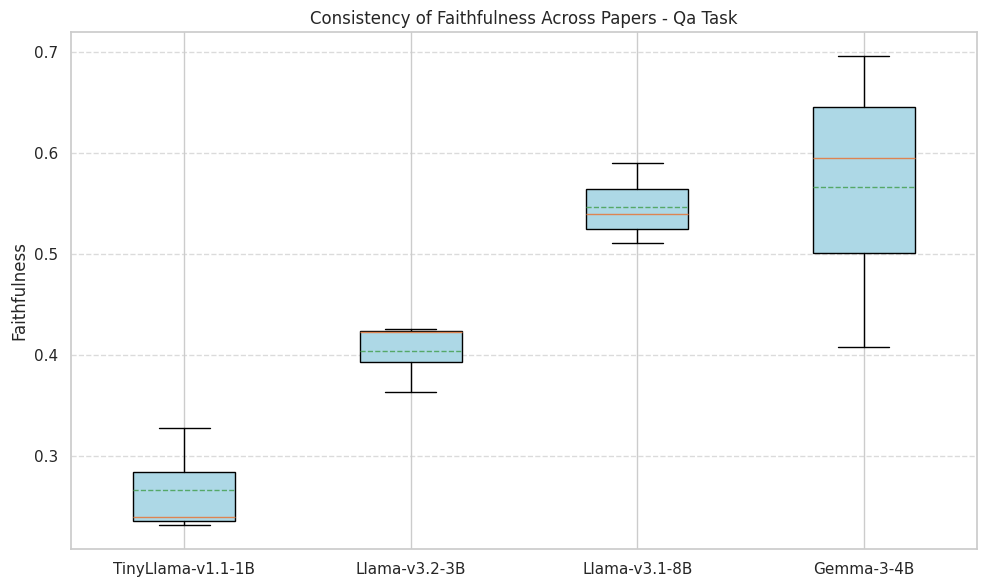

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


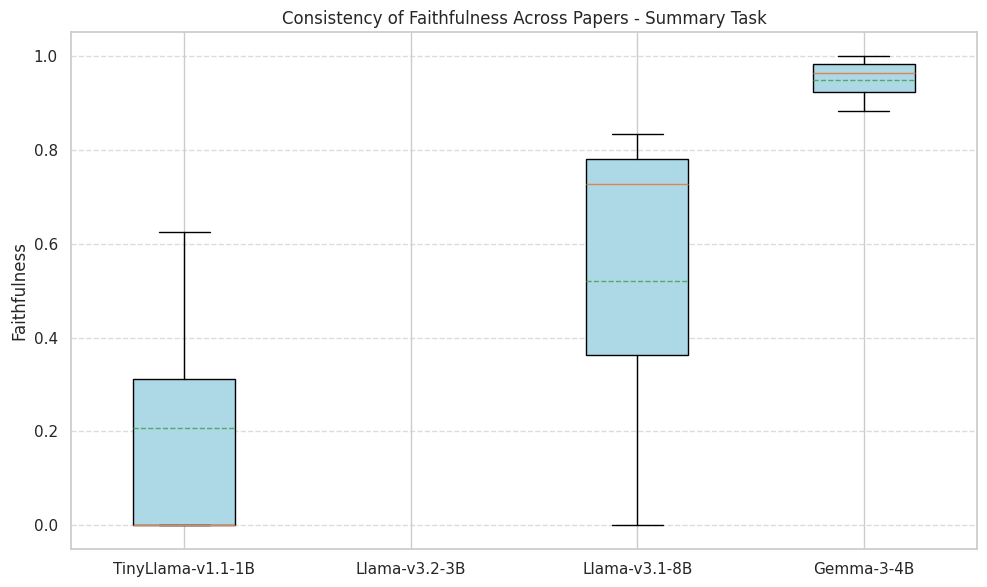

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


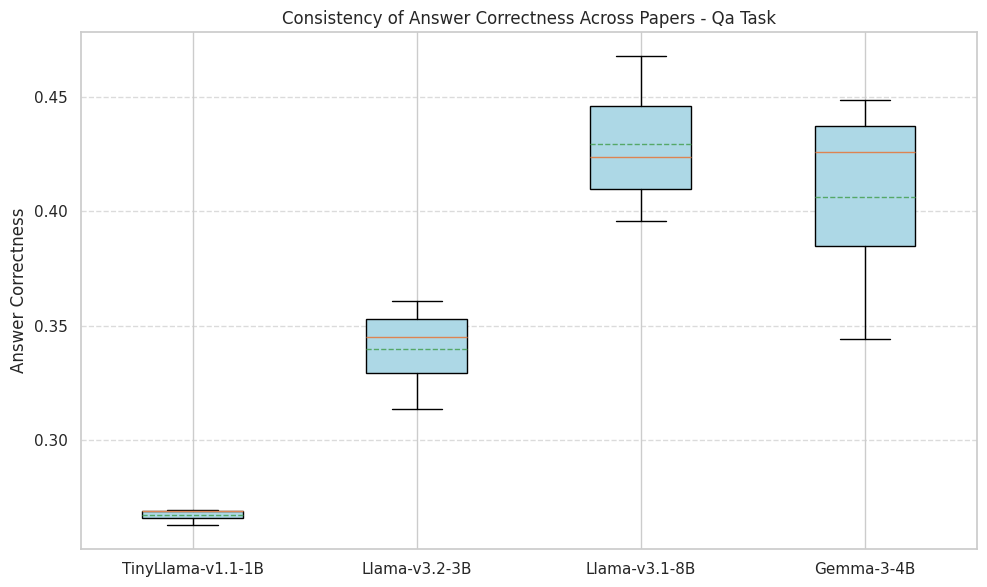

<ipython-input-16-5fc644bacdfe>:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(plot_data, patch_artist=True, labels=model_names,


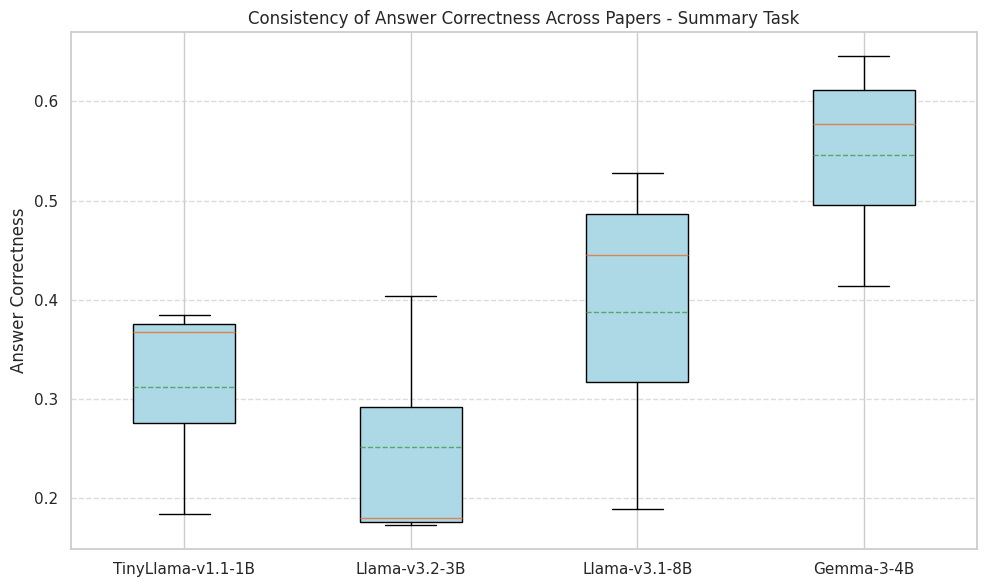

In [ ]:
# Use the consistency boxplots for important metrics
# BERTScore F1
create_consistency_boxplots(all_results, "bertscore", "bertscore_f1", "qa")
create_consistency_boxplots(all_results, "bertscore", "bertscore_f1", "summary")

# ROUGE-L
create_consistency_boxplots(all_results, "rouge", "rougeL_f", "qa")
create_consistency_boxplots(all_results, "rouge", "rougeL_f", "summary")

# RAGAS metrics
for metric in ['faithfulness', 'answer_correctness']:
    create_consistency_boxplots(all_results, "ragas_qa", metric, "qa")
    create_consistency_boxplots(all_results, "ragas_summary", metric, "summary")

5. Time-Performance Trade-off Plots (if available)

 Plotting inference time against quality metrics to visualize computational efficiency versus performance.


In [ ]:
MODEL_INFERENCE_TIMES = {
    "TinyLlama-v1.1-1B": 0.2,  # seconds per generation
    "Llama-v3.2-3B": 0.6,  # seconds per generation
    "Llama-v3.1-8B": 1.5      # seconds per generation
}

def create_time_performance_plot(results_dict, metric_type, specific_metric, task_type):
    """Create scatter plot showing the trade-off between inference time and performance"""

    inference_times = []
    performance_values = []
    model_labels = []

    for model in MODEL_NAMES:
        if model not in MODEL_INFERENCE_TIMES:
            print(f"No inference time data for {model}, skipping")
            continue

        # Get the correct dataframe based on metric type
        if metric_type == "bertscore" or metric_type == "rouge":
            if model in results_dict[metric_type]:
                df = results_dict[metric_type][model]
                # Filter by task type
                task_df = df[df['task'] == task_type]
                if not task_df.empty and specific_metric in task_df.columns:
                    inference_times.append(MODEL_INFERENCE_TIMES[model])
                    performance_values.append(task_df[specific_metric].mean())
                    model_labels.append(model)
        elif metric_type == "ragas_qa" and task_type == "qa":
            if model in results_dict["ragas_qa"]:
                df = results_dict["ragas_qa"][model]
                if not df.empty and specific_metric in df.columns:
                    inference_times.append(MODEL_INFERENCE_TIMES[model])
                    performance_values.append(df[specific_metric].mean())
                    model_labels.append(model)
        elif metric_type == "ragas_summary" and task_type == "summary":
            if model in results_dict["ragas_summary"]:
                df = results_dict["ragas_summary"][model]
                if not df.empty and specific_metric in df.columns:
                    inference_times.append(MODEL_INFERENCE_TIMES[model])
                    performance_values.append(df[specific_metric].mean())
                    model_labels.append(model)

    # Create the plot if we have data
    if inference_times and performance_values:
        plt.figure(figsize=(10, 6))

        # Scatter plot
        scatter = plt.scatter(inference_times, performance_values, s=100,
                             c=[MODEL_COLORS.get(model, 'blue') for model in model_labels],
                             alpha=0.7)

        # Add model names as labels
        for i, model in enumerate(model_labels):
            plt.annotate(model, (inference_times[i], performance_values[i]),
                        textcoords="offset points", xytext=(0, 10), ha='center')

        # Connect points with a line
        plt.plot(inference_times, performance_values, '--', color='gray', alpha=0.5)

        # Add labels and title
        plt.xlabel('Inference Time (seconds)')
        plt.ylabel(f'{specific_metric}')
        metric_display = specific_metric.replace('_', ' ').title().replace('Bertscore', 'BERTScore')
        plt.title(f'Inference Time vs. {metric_display} for {task_type.title()} Task')

        # Add grid
        plt.grid(True, linestyle='--', alpha=0.7)

        # Add diagonal reference line for illustration of Pareto frontier
        if min(performance_values) > 0:
            plt.plot([min(inference_times), max(inference_times)],
                    [min(performance_values), max(performance_values)],
                    'k:', alpha=0.3, label="Hypothetical Pareto Frontier")
            plt.legend()

        # Save the figure
        plt.tight_layout()
        plt.savefig(f"time_vs_{specific_metric}_{task_type}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Not enough data for time vs. {specific_metric} plot for {task_type} task")

 6. Component Bar Charts

 Creating grouped bar charts comparing specific components of evaluation across models

In [ ]:
def create_component_bar_chart(results_dict, component_group, task_type):
    """Create grouped bar chart for comparing specific evaluation components across models"""

    if component_group == "bertscore":
        metrics = ["bertscore_precision", "bertscore_recall", "bertscore_f1"]
        metric_display = ["Precision", "Recall", "F1"]
        title = "BERTScore Components"
        source_type = "bertscore"
    elif component_group == "rouge":
        metrics = ["rouge1_f", "rouge2_f", "rougeL_f"]
        metric_display = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
        title = "ROUGE Components"
        source_type = "rouge"
    elif component_group == "ragas":
        metrics = ["context_precision", "context_recall", "faithfulness",
                  "answer_relevancy", "answer_correctness"]
        metric_display = ["Context Precision", "Context Recall", "Faithfulness",
                         "Answer Relevancy", "Answer Correctness"]
        title = "RAGAS Components"
        source_type = "ragas_qa" if task_type == "qa" else "ragas_summary"
    else:
        print(f"Unknown component group: {component_group}")
        return

    # Collect data for bar chart
    data = []

    for model in MODEL_NAMES:
        model_data = {"Model": model}

        if component_group in ["bertscore", "rouge"]:
            if model in results_dict[source_type]:
                df = results_dict[source_type][model]
                task_df = df[df['task'] == task_type]
                if not task_df.empty:
                    for i, metric in enumerate(metrics):
                        if metric in task_df.columns:
                            model_data[metric_display[i]] = task_df[metric].mean()
        else:  # RAGAS
            if model in results_dict[source_type]:
                df = results_dict[source_type][model]
                for i, metric in enumerate(metrics):
                    if metric in df.columns:
                        model_data[metric_display[i]] = df[metric].mean()

        if len(model_data) > 1:  # Only add if we have some metric data
            data.append(model_data)

    # Create DataFrame for plotting
    if data:
        df_plot = pd.DataFrame(data)

        # Set up the figure
        plt.figure(figsize=(12, 7))

        # Get number of metrics and models
        n_metrics = len(metric_display)
        n_models = len(data)

        # Set up x-coordinates for bars
        x = np.arange(n_metrics)
        width = 0.8 / n_models  # Bar width

        # Plot bars for each model
        for i, model in enumerate(df_plot['Model']):
            values = [df_plot[df_plot['Model'] == model][m].values[0] if m in df_plot.columns else 0
                     for m in metric_display]
            plt.bar(x + i*width - 0.4 + width/2, values, width,
                   label=model, color=MODEL_COLORS.get(model, 'blue'), alpha=0.7)

        # Add labels and legend
        plt.xlabel('Metrics')
        plt.ylabel('Score')
        plt.title(f'{title} Comparison - {task_type.title()} Task')
        plt.xticks(x, metric_display, rotation=45)
        plt.legend(title='Model')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Improve layout
        plt.tight_layout()

        # Save the figure
        plt.savefig(f"{component_group}_components_{task_type}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Not enough data for {component_group} components bar chart on {task_type} task")

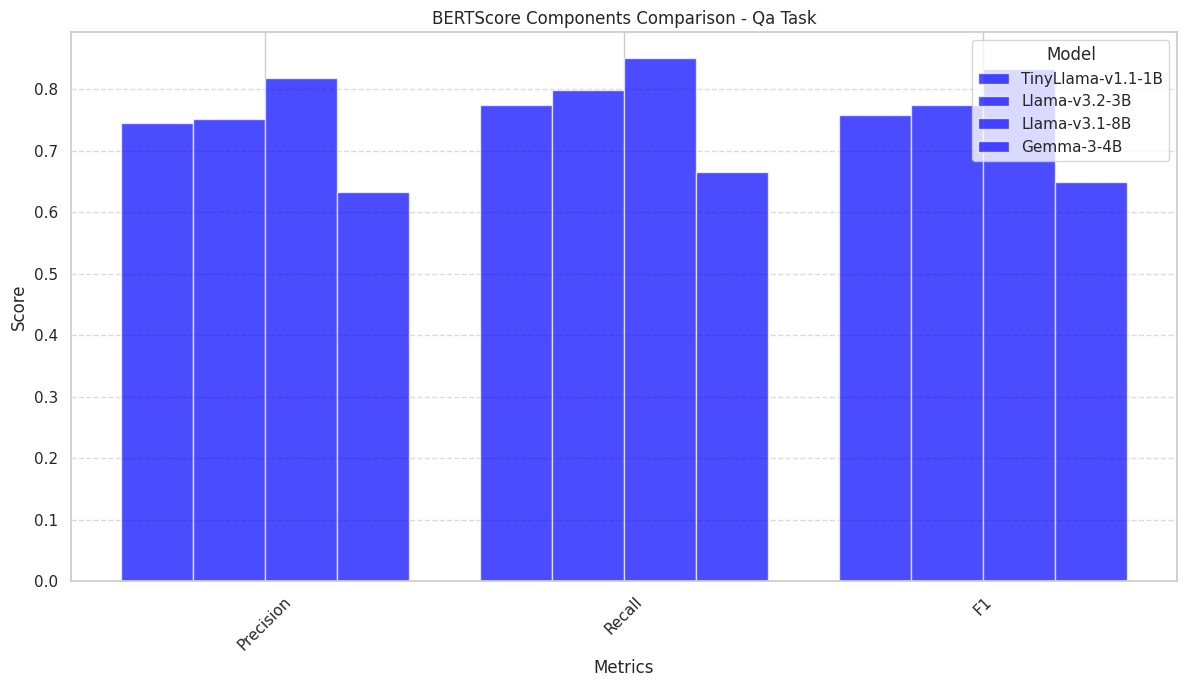

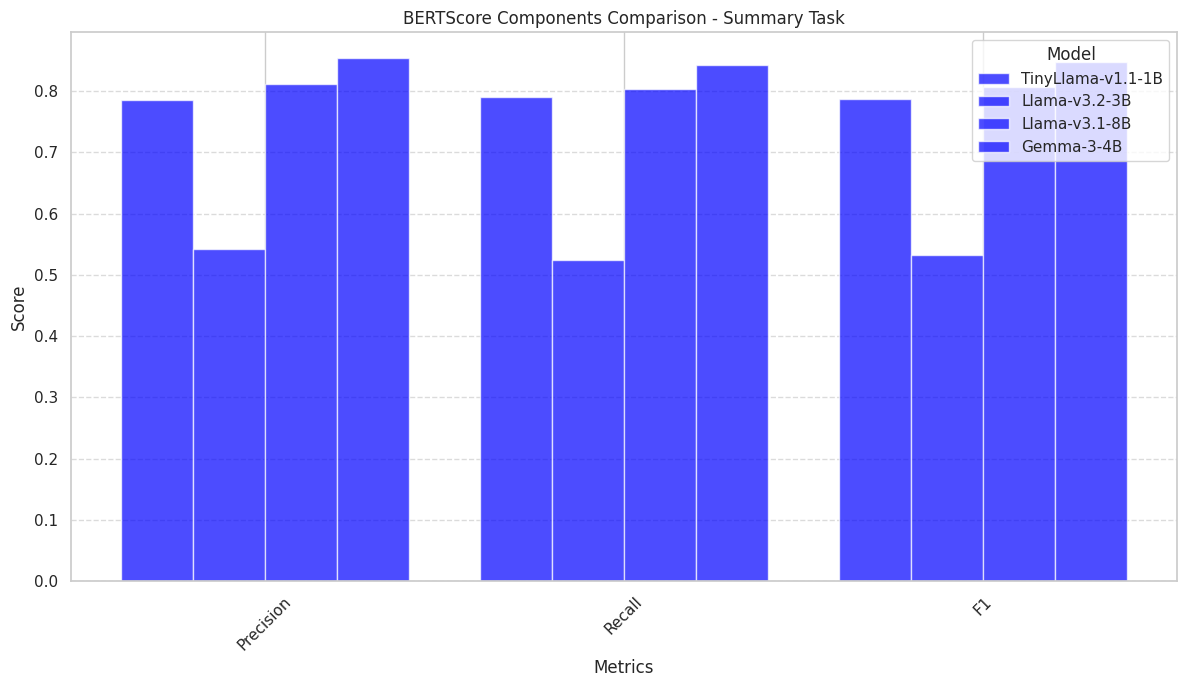

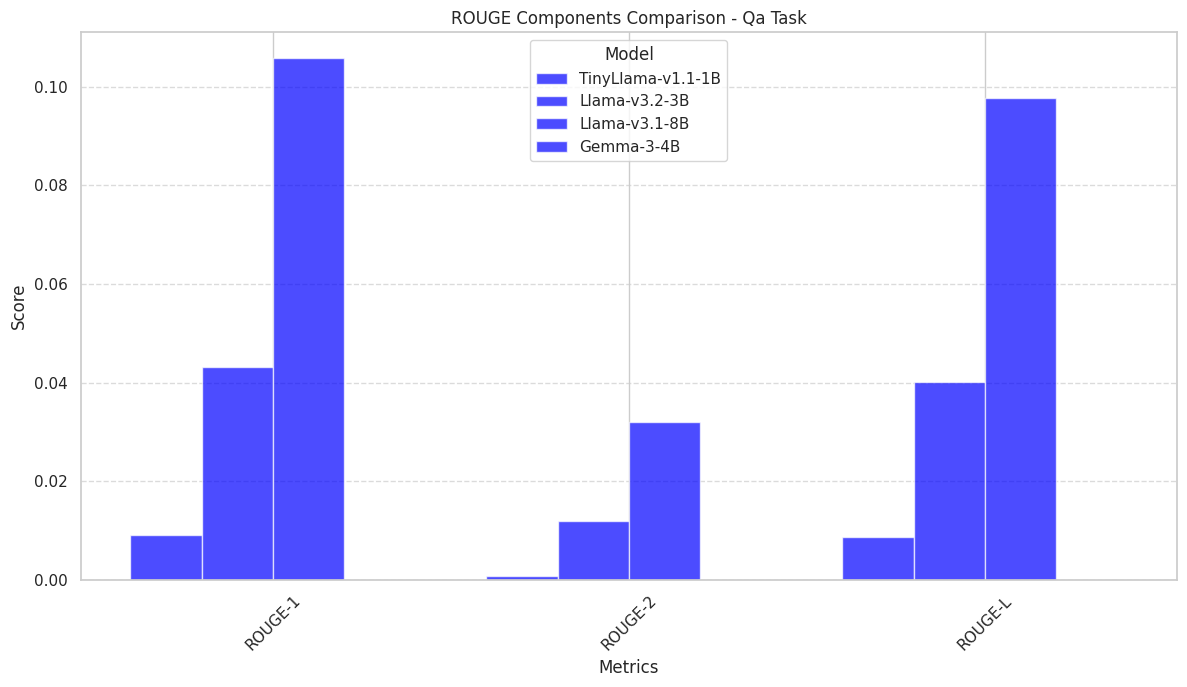

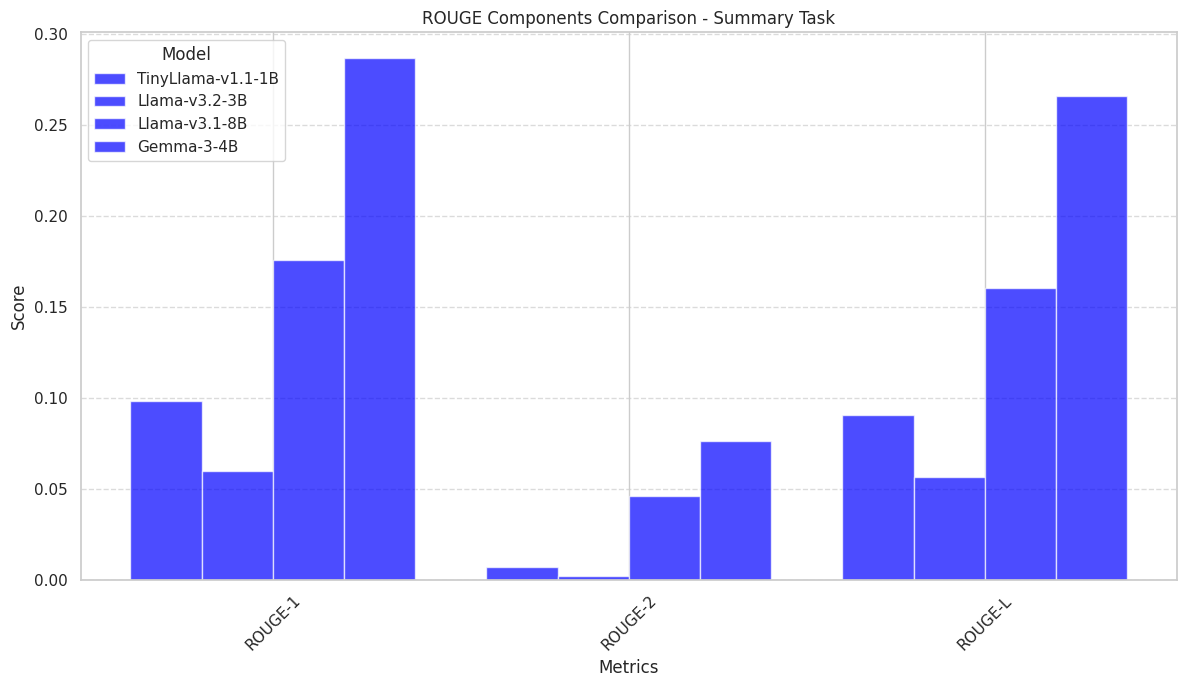

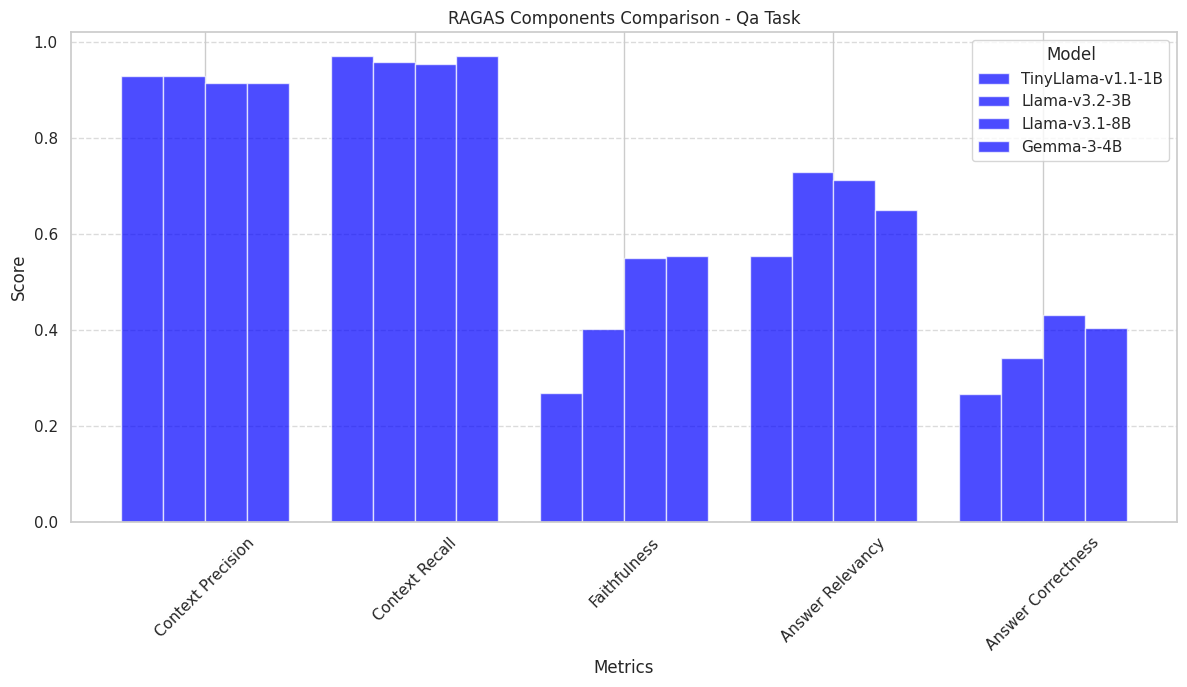

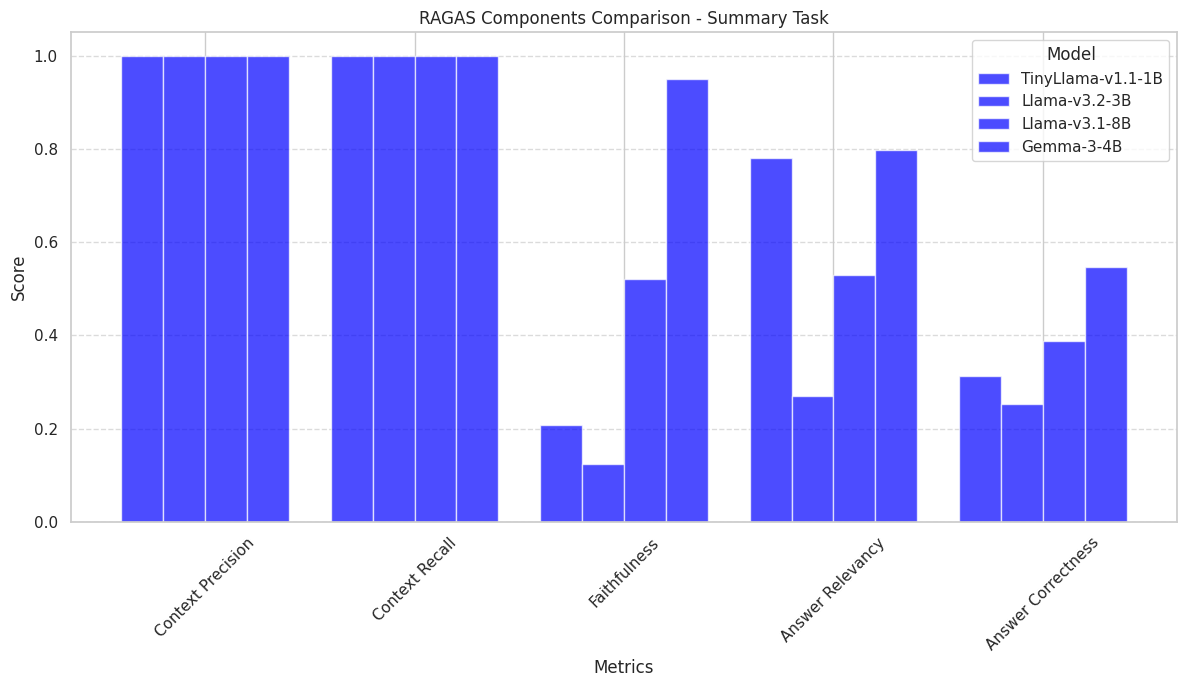

In [ ]:
# 6. Create component bar charts
# BERTScore components
create_component_bar_chart(all_results, "bertscore", "qa")
create_component_bar_chart(all_results, "bertscore", "summary")

# ROUGE components
create_component_bar_chart(all_results, "rouge", "qa")
create_component_bar_chart(all_results, "rouge", "summary")

# RAGAS components
create_component_bar_chart(all_results, "ragas", "qa")
create_component_bar_chart(all_results, "ragas", "summary")

7. Parallel Coordinates Plot

  Using parallel coordinates to visualize how models perform across all metrics simultaneously and identify patterns.

In [ ]:
def create_parallel_coordinates_plot(results_dict, task_type):
    """Create a parallel coordinates plot to visualize model performance across all metrics"""

    # Collect data for the plot
    data = {}

    # Get BERTScore metrics for this task
    bertscore_metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1']
    rouge_metrics = ['rouge1_f', 'rouge2_f', 'rougeL_f']
    ragas_metrics = ['context_precision', 'context_recall', 'faithfulness',
                    'answer_relevancy', 'answer_correctness']

    # Create a single dataframe with all metrics for this task
    for model in MODEL_NAMES:
        model_data = {"model": model}

        # BERTScore
        if model in results_dict["bertscore"]:
            df = results_dict["bertscore"][model]
            task_df = df[df['task'] == task_type]
            if not task_df.empty:
                for metric in bertscore_metrics:
                    if metric in task_df.columns:
                        metric_name = f"BS-{metric.replace('bertscore_', '')}"
                        model_data[metric_name] = task_df[metric].mean()

        # ROUGE
        if model in results_dict["rouge"]:
            df = results_dict["rouge"][model]
            task_df = df[df['task'] == task_type]
            if not task_df.empty:
                for metric in rouge_metrics:
                    if metric in task_df.columns:
                        model_data[metric] = task_df[metric].mean()

        # RAGAS
        ragas_type = "ragas_qa" if task_type == "qa" else "ragas_summary"
        if model in results_dict[ragas_type]:
            df = results_dict[ragas_type][model]
            for metric in ragas_metrics:
                if metric in df.columns:
                    model_data[f"RAGAS-{metric}"] = df[metric].mean()

        # Store in main data dictionary
        data[model] = model_data

    # Convert to DataFrame for plotting
    plot_data = pd.DataFrame([data[model] for model in MODEL_NAMES])

    if not plot_data.empty and len(plot_data.columns) > 2:  # Need at least model column + 1 metric
        # Plot using plotly
        fig = px.parallel_coordinates(
            plot_data,
            #color="sepal_length",
            #color_continuous_scale="Inferno",
            labels={col: col for col in plot_data.columns},
            title=f"Model Performance Across All Metrics - {task_type.title()} Task"
        )

        # Update layout
        fig.update_layout(
            font=dict(size=12),
            height=600,
            margin=dict(l=80, r=80, t=100, b=80),
        )

        fig.update_traces(line=dict(color=px.colors.qualitative.Plotly))

        # Show plot
        fig.show()

        # Save as HTML for interactive viewing
        fig.write_html(f"parallel_coordinates_{task_type}.html")

        # Also save as image
        fig.write_image(f"parallel_coordinates_{task_type}.png", scale=2)

    else:
        print(f"Not enough data for parallel coordinates plot on {task_type} task")

In [ ]:
# 7. Create parallel coordinates plots for both tasks
create_parallel_coordinates_plot(all_results, "qa")
#create_parallel_coordinates_plot(all_results, "summary")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


 8. Qualitative Error Visualization

 Creating visuals highlighting where models make errors, such as using colored text highlighting for hallucinations.


In [ ]:
def visualize_qa_errors(results_dict, model_name, max_examples=3):
    """Create visualizations of QA errors for a specific model"""

    if model_name not in results_dict["ragas_qa"]:
        print(f"No RAGAS QA data for {model_name}")
        return

    # Get QA data for this model
    qa_df = results_dict["ragas_qa"][model_name]

    # Sort by faithfulness score to find potential error cases
    if 'faithfulness' in qa_df.columns:
        error_examples = qa_df.sort_values('faithfulness').head(max_examples)

        for i, row in error_examples.iterrows():
            # Get the relevant data
            question = row.get('user_input', 'Question not available')
            response = row.get('response', 'Response not available')
            reference = row.get('reference', 'Reference not available')
            faithfulness = row.get('faithfulness', 0)
            answer_correctness = row.get('answer_correctness', 0)

            # Create a figure with text
            plt.figure(figsize=(12, 8))
            plt.text(0.5, 0.95, f"Model: {model_name} - Faithfulness: {faithfulness:.3f}, Correctness: {answer_correctness:.3f}",
                    ha='center', va='top', fontsize=14, fontweight='bold')

            plt.text(0.5, 0.85, f"Question:", ha='center', va='top', fontsize=12, fontweight='bold')
            plt.text(0.5, 0.80, question, ha='center', va='top', fontsize=11, wrap=True)

            plt.text(0.5, 0.65, f"Model Response:", ha='center', va='top', fontsize=12, fontweight='bold')
            plt.text(0.5, 0.60, response[:500] + ("..." if len(response) > 500 else ""),
                    ha='center', va='top', fontsize=11, wrap=True)

            plt.text(0.5, 0.30, f"Reference Answer:", ha='center', va='top', fontsize=12, fontweight='bold')
            plt.text(0.5, 0.25, reference[:500] + ("..." if len(reference) > 500 else ""),
                    ha='center', va='top', fontsize=11, wrap=True)

            # Remove axes
            plt.axis('off')

            # Save the figure
            plt.tight_layout()
            plt.savefig(f"{model_name}_qa_error_{i}.png", dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"No faithfulness metric found for {model_name} in QA data")

def visualize_summary_errors(results_dict, model_name, max_examples=3):
    """Create visualizations of summary errors for a specific model"""

    if model_name not in results_dict["ragas_summary"]:
        print(f"No RAGAS summary data for {model_name}")
        return

    # Get summary data for this model
    summary_df = results_dict["ragas_summary"][model_name]

    # Sort by faithfulness score to find potential error cases
    if 'faithfulness' in summary_df.columns:
        error_examples = summary_df.sort_values('faithfulness').head(max_examples)

        for i, row in error_examples.iterrows():
            # Get the relevant data
            question = row.get('user_input', 'Question not available')
            response = row.get('response', 'Response not available')
            reference = row.get('reference', 'Reference not available')
            faithfulness = row.get('faithfulness', 0)

            # Create a figure with text
            plt.figure(figsize=(12, 10))
            plt.text(0.5, 0.98, f"Model: {model_name} - Summary Faithfulness: {faithfulness:.3f}",
                    ha='center', va='top', fontsize=14, fontweight='bold')

            plt.text(0.5, 0.90, f"Model Summary:", ha='center', va='top', fontsize=12, fontweight='bold')
            plt.text(0.5, 0.85, response[:800] + ("..." if len(response) > 800 else ""),
                    ha='center', va='top', fontsize=11, wrap=True)

            plt.text(0.5, 0.50, f"Reference Summary:", ha='center', va='top', fontsize=12, fontweight='bold')
            plt.text(0.5, 0.45, reference[:800] + ("..." if len(reference) > 800 else ""),
                    ha='center', va='top', fontsize=11, wrap=True)

            # Remove axes
            plt.axis('off')

            # Save the figure
            plt.tight_layout()
            plt.savefig(f"{model_name}_summary_error_{i}.png", dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print(f"No faithfulness metric found for {model_name} in summary data")


Visualizing QA errors for TinyLlama-v1.1-1B:


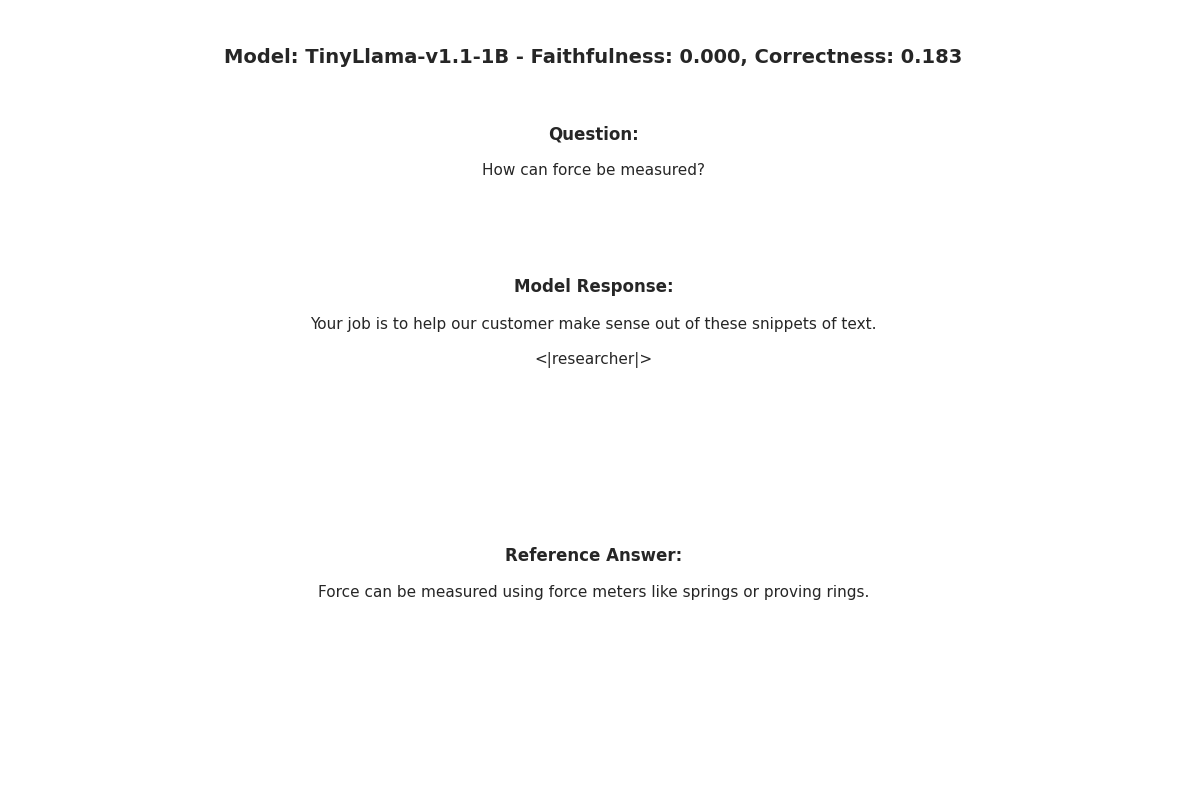

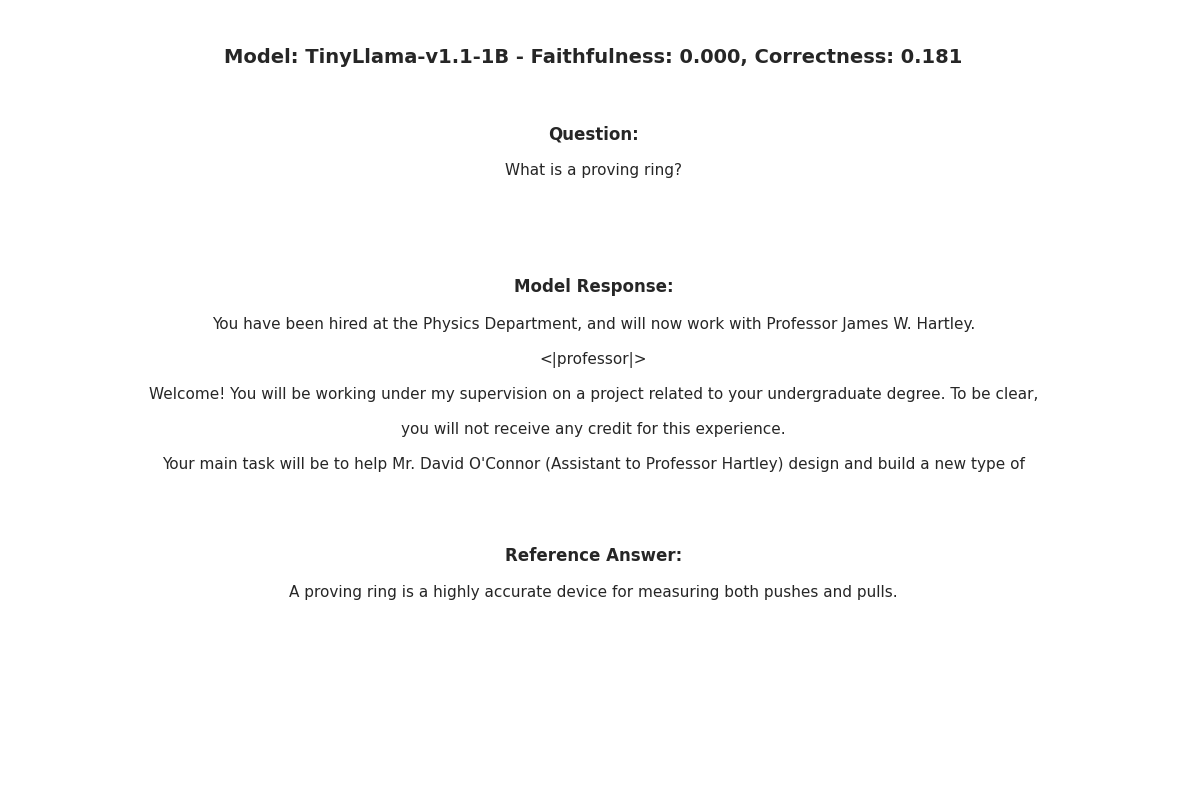


Visualizing summary errors for TinyLlama-v1.1-1B:


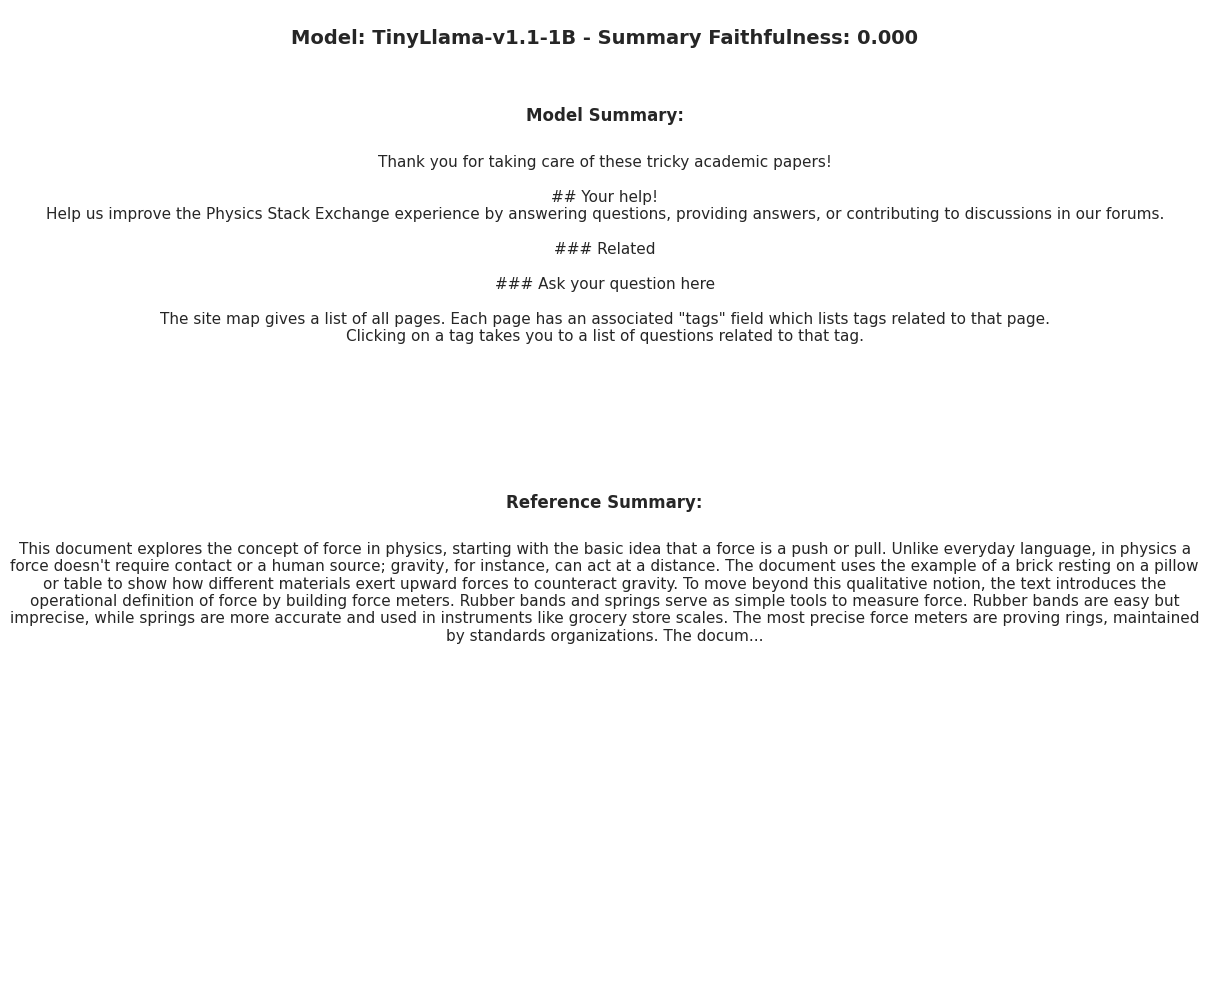

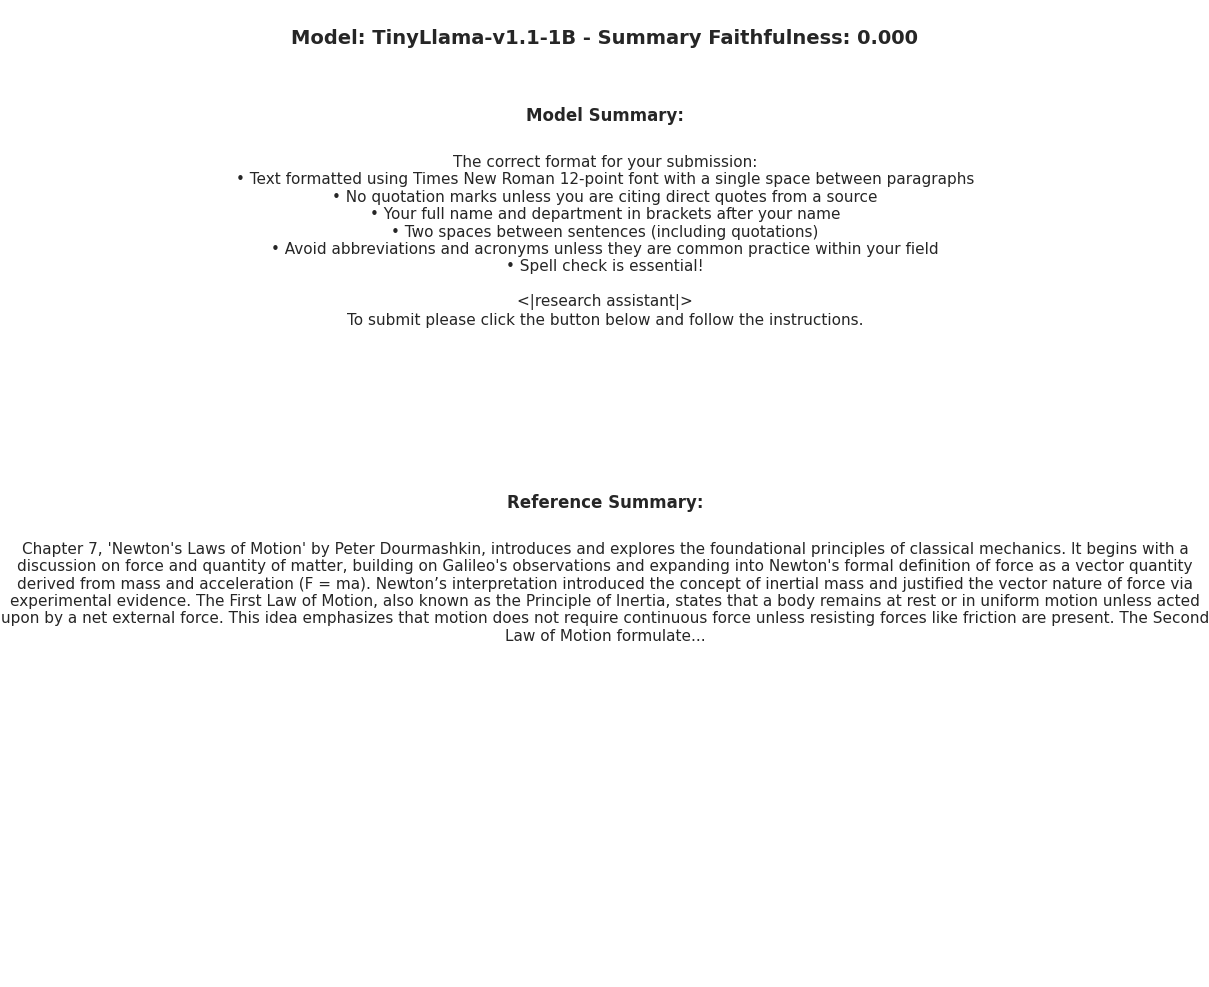


Visualizing QA errors for Llama-v3.2-3B:


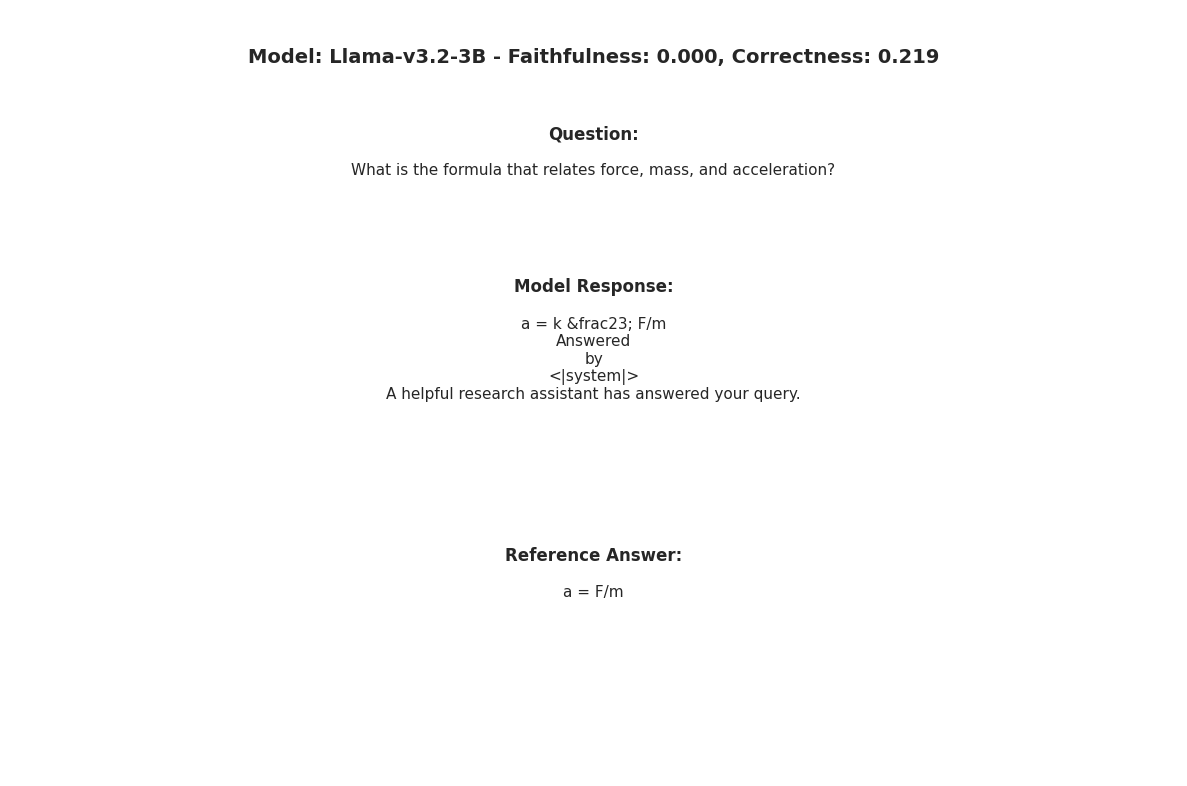

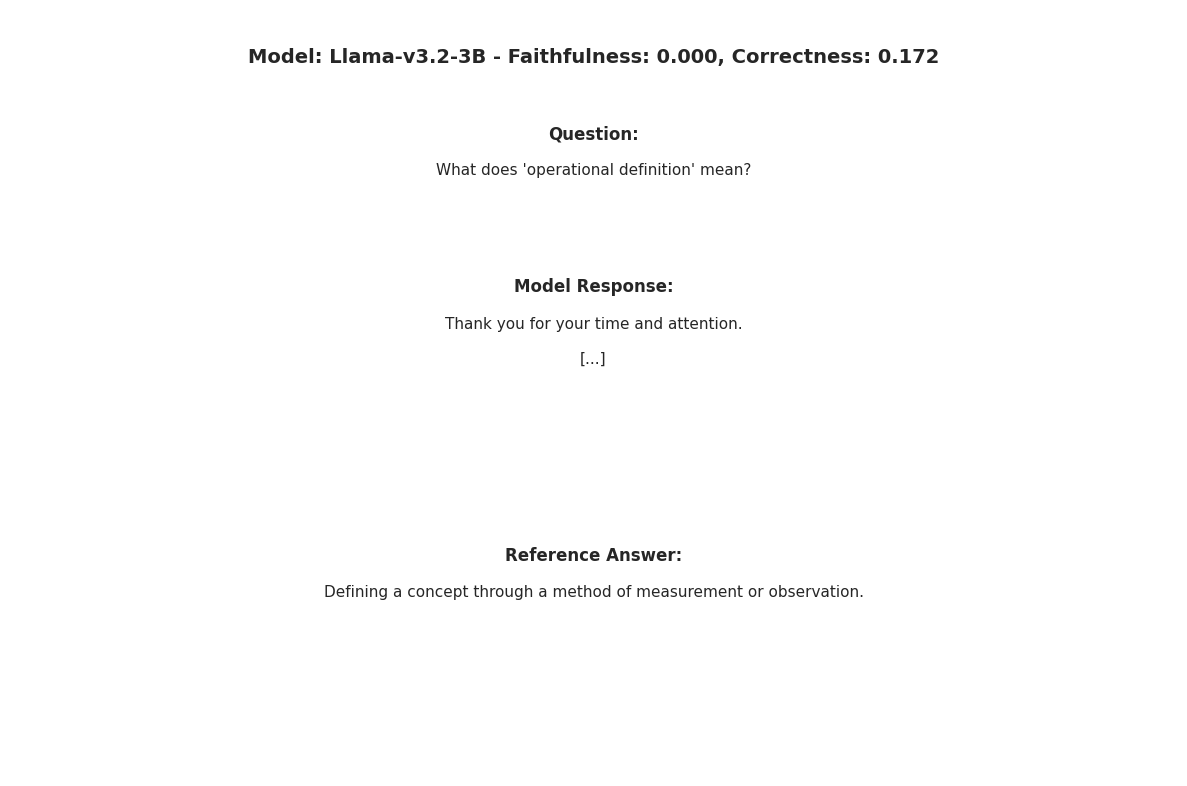


Visualizing summary errors for Llama-v3.2-3B:


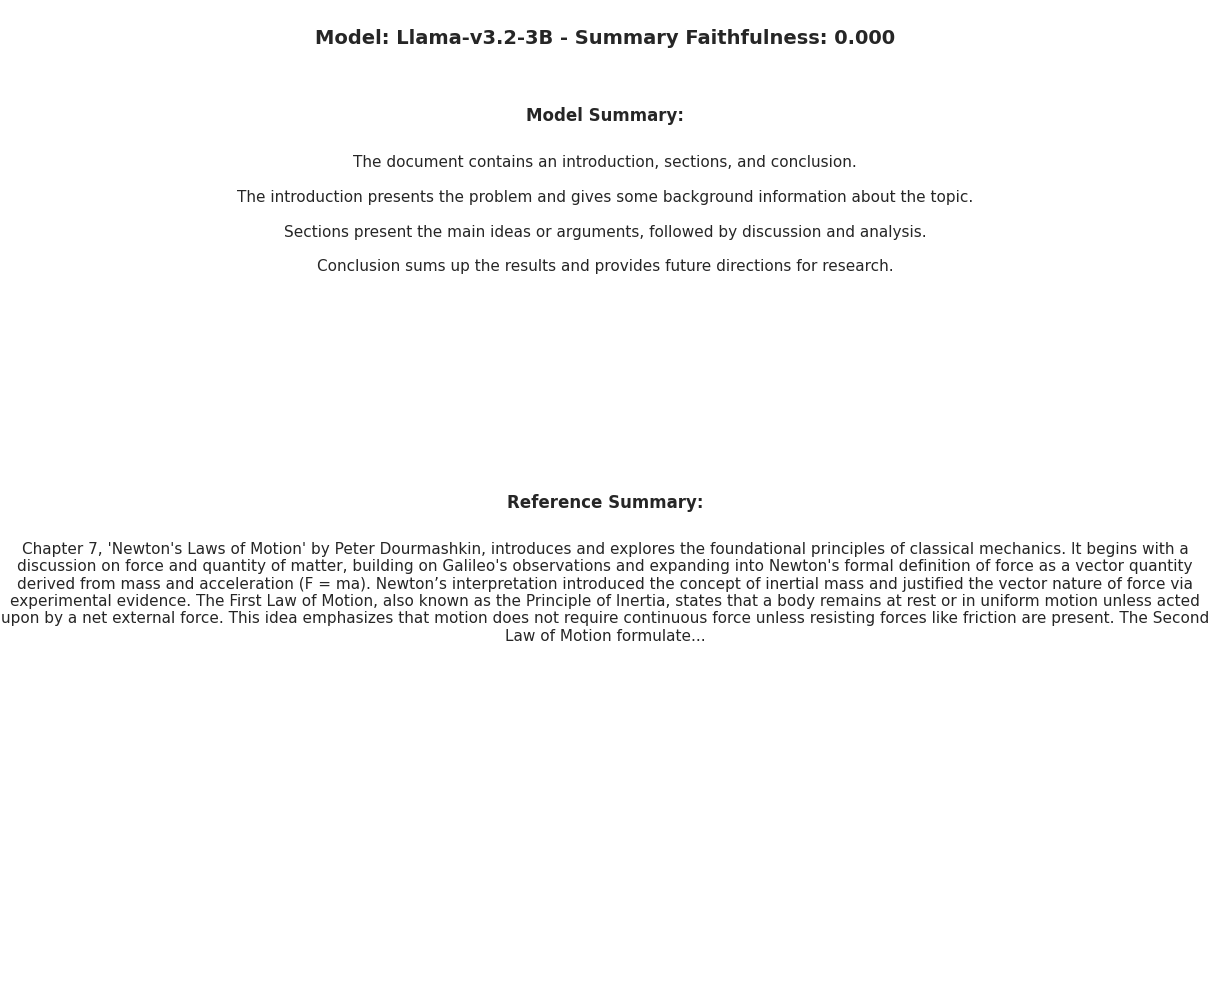

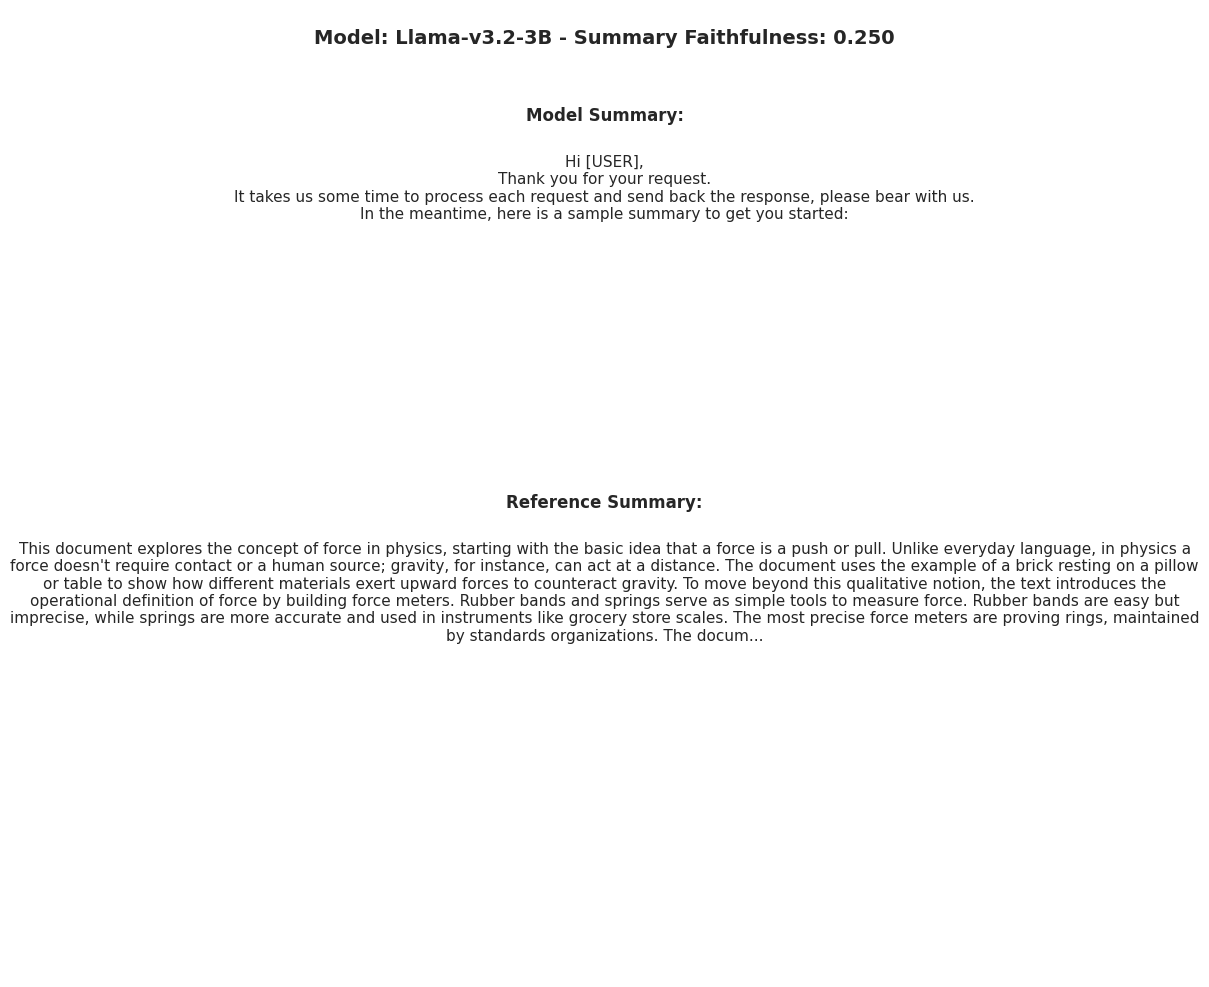


Visualizing QA errors for Llama-v3.1-8B:


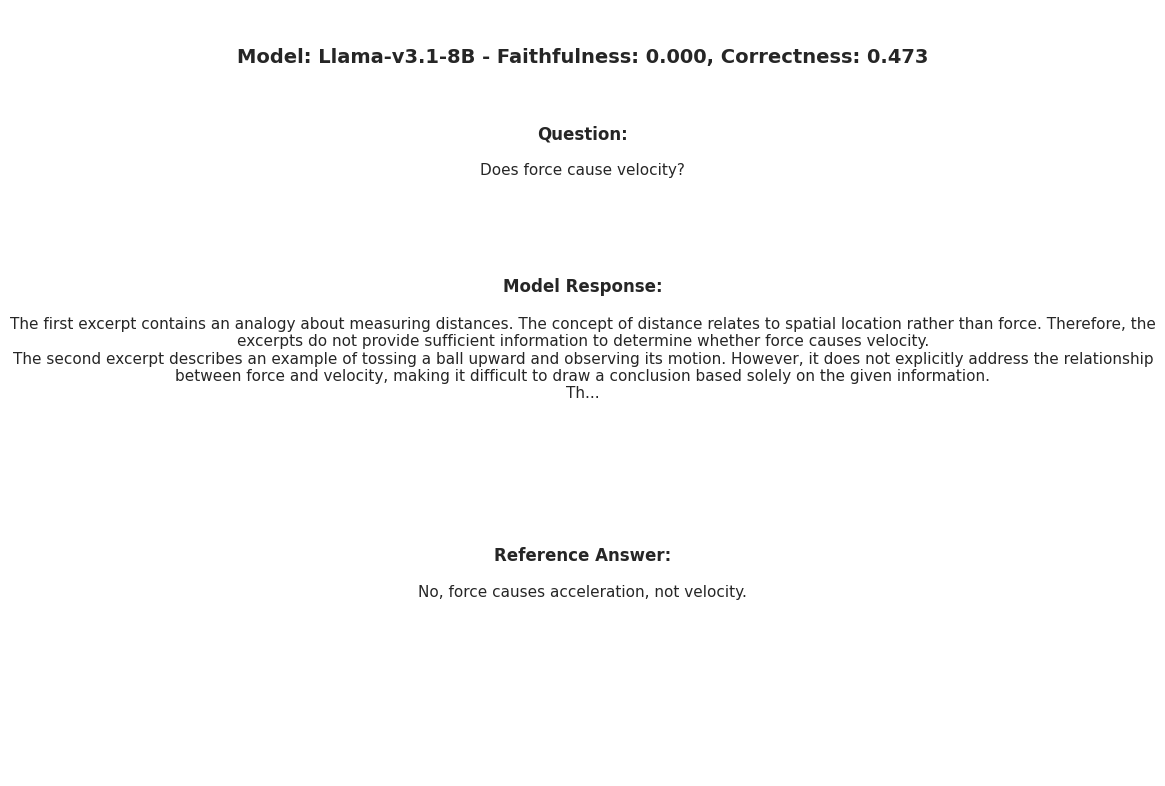

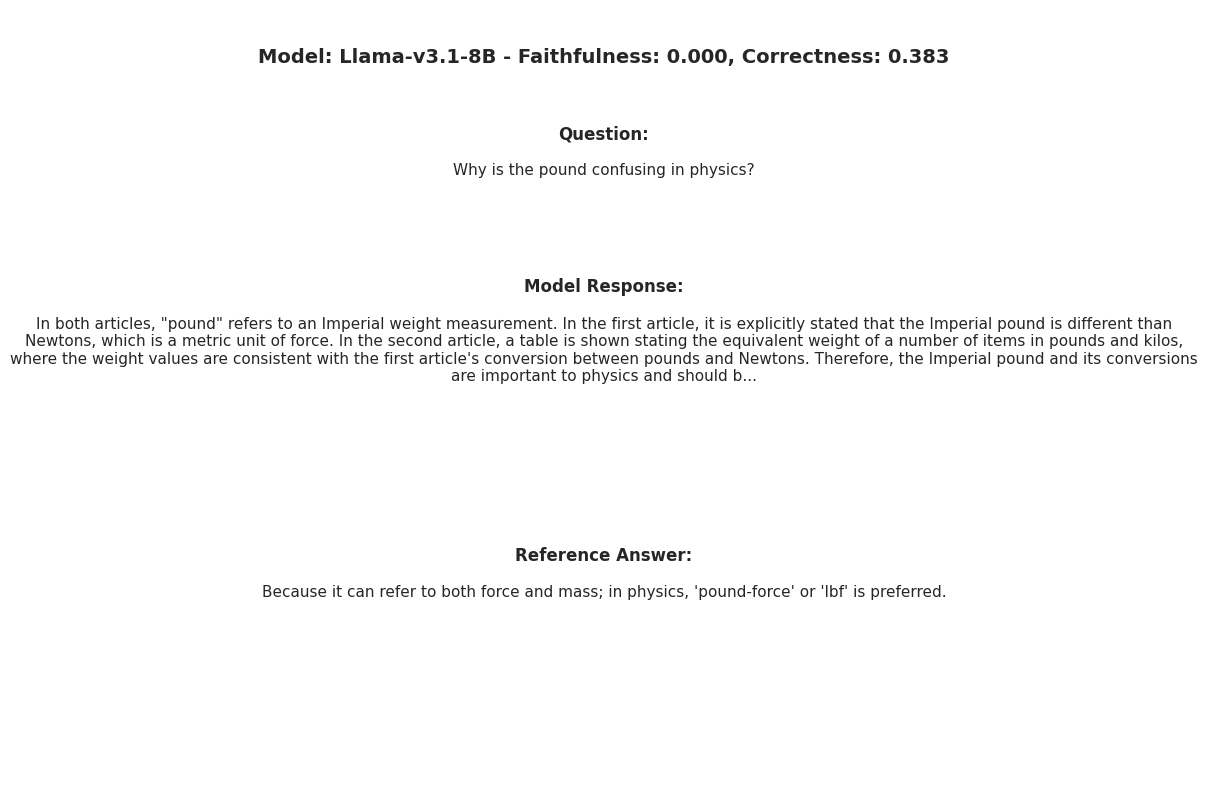


Visualizing summary errors for Llama-v3.1-8B:


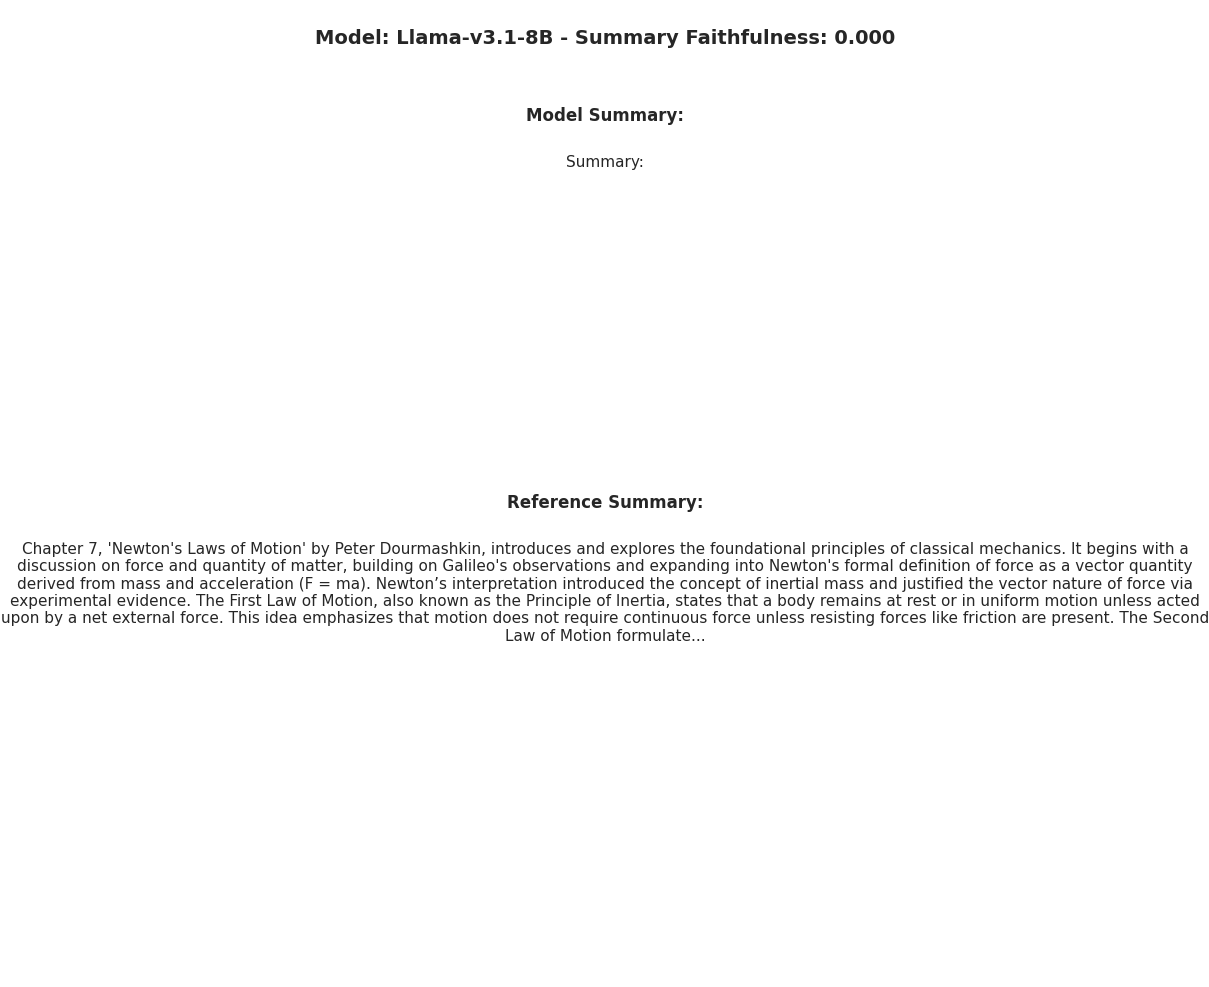

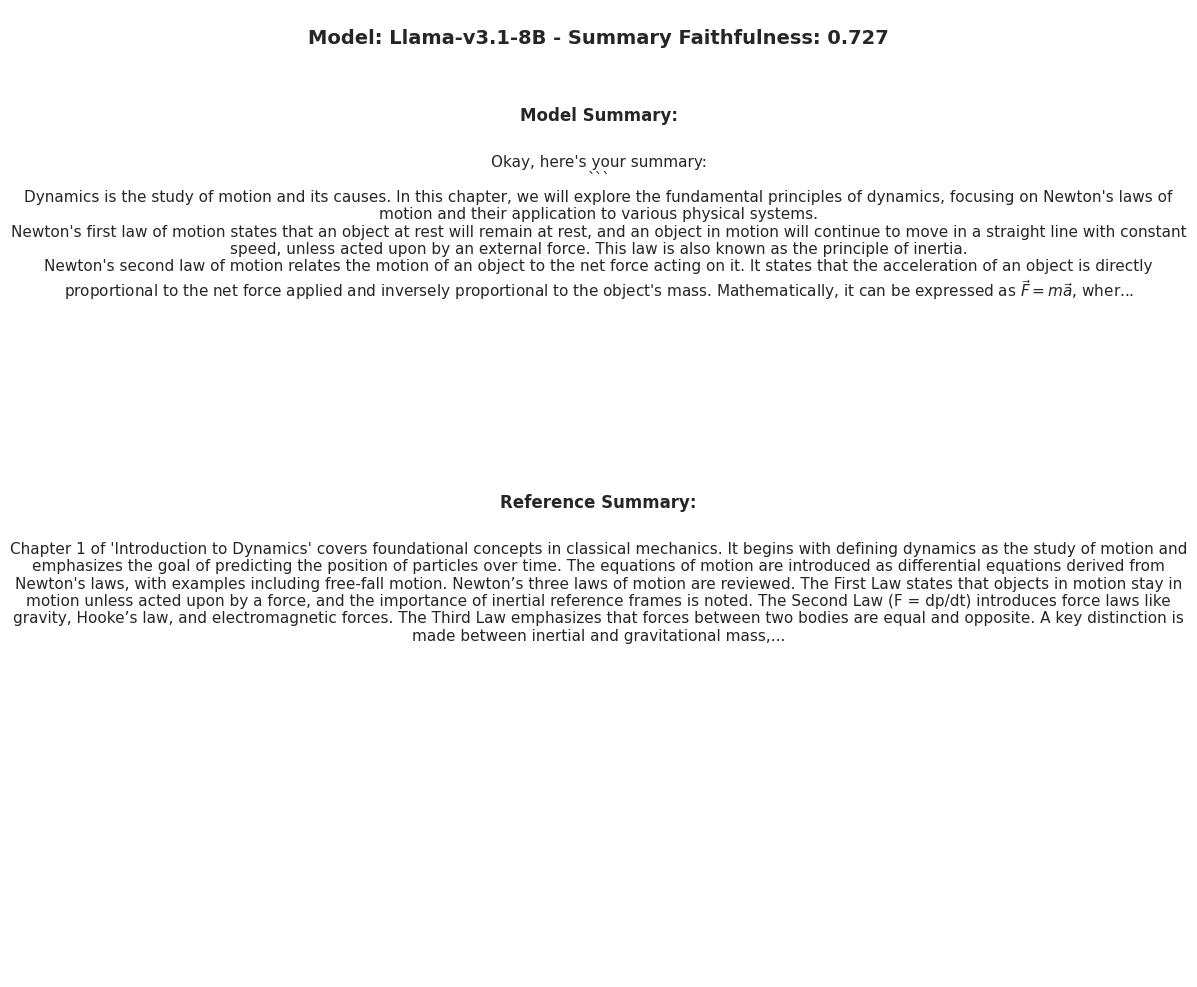


Visualizing QA errors for Gemma-3-4B:


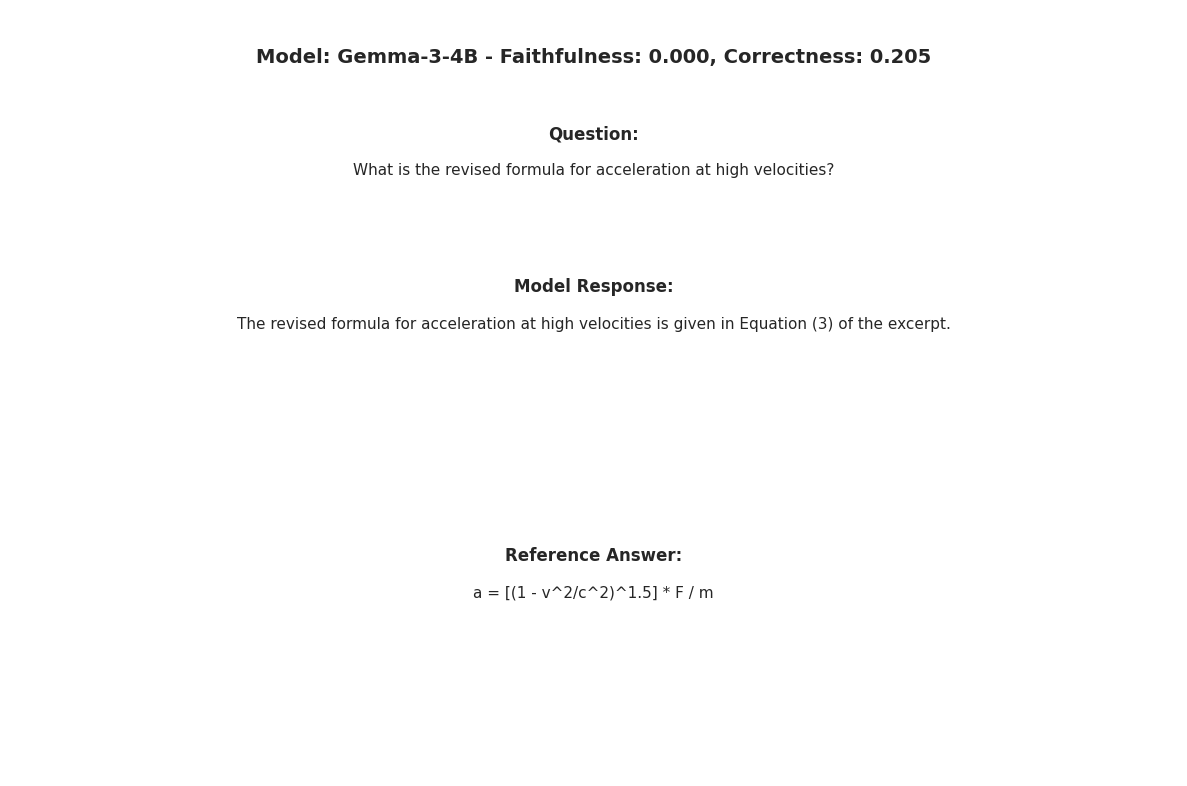

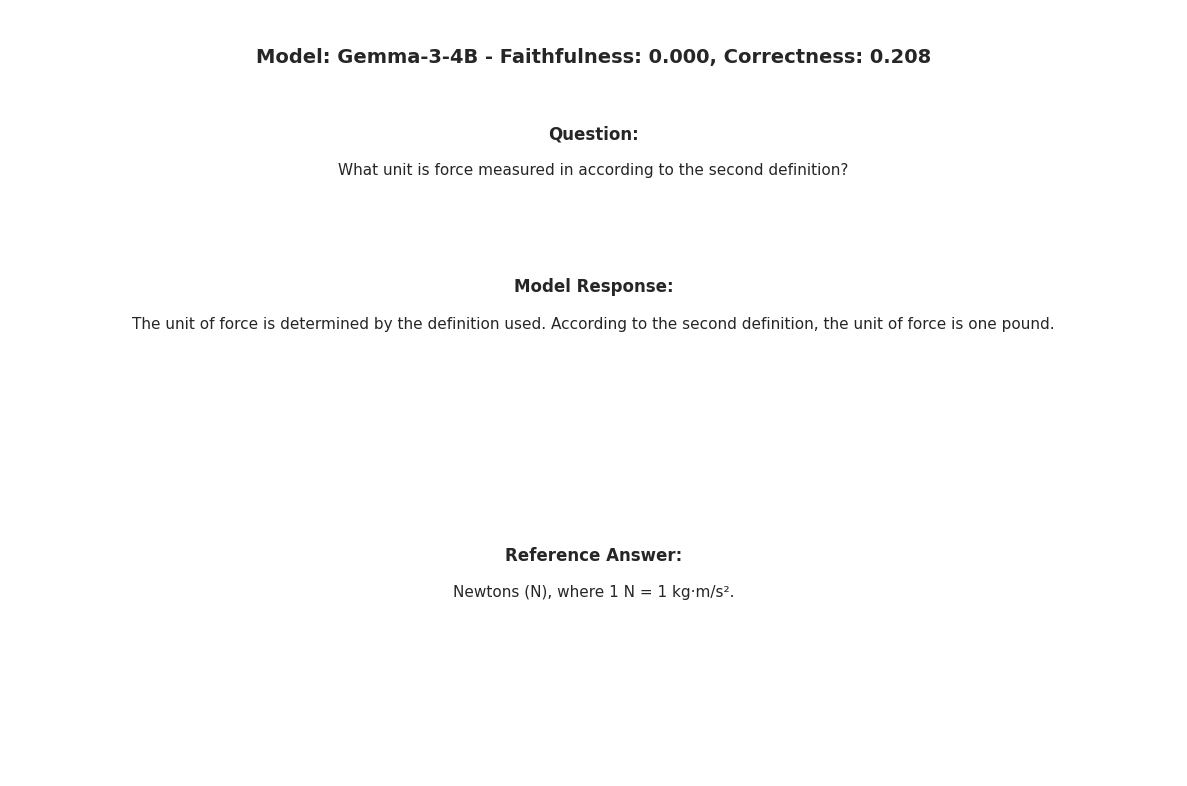


Visualizing summary errors for Gemma-3-4B:


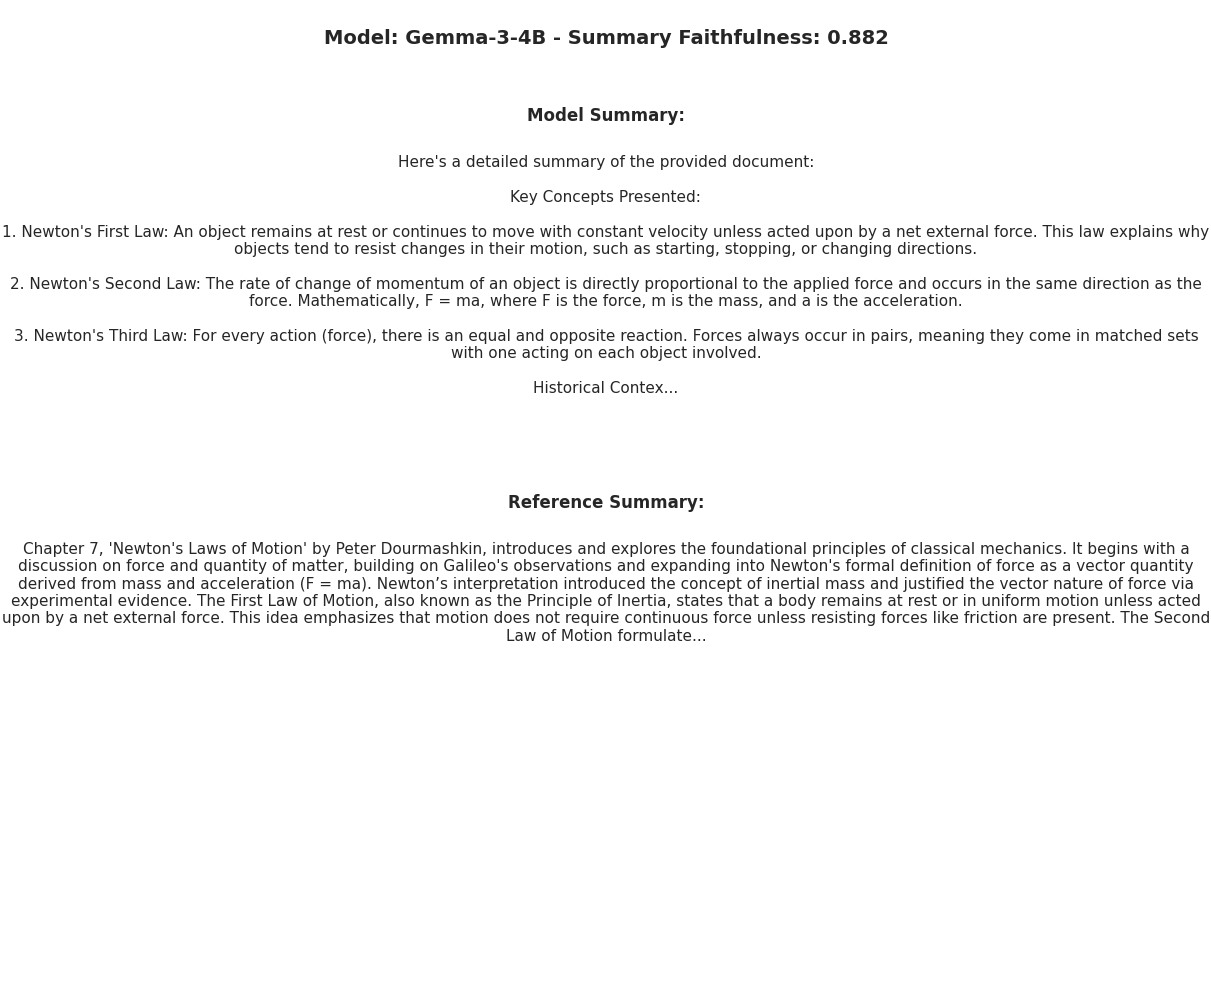

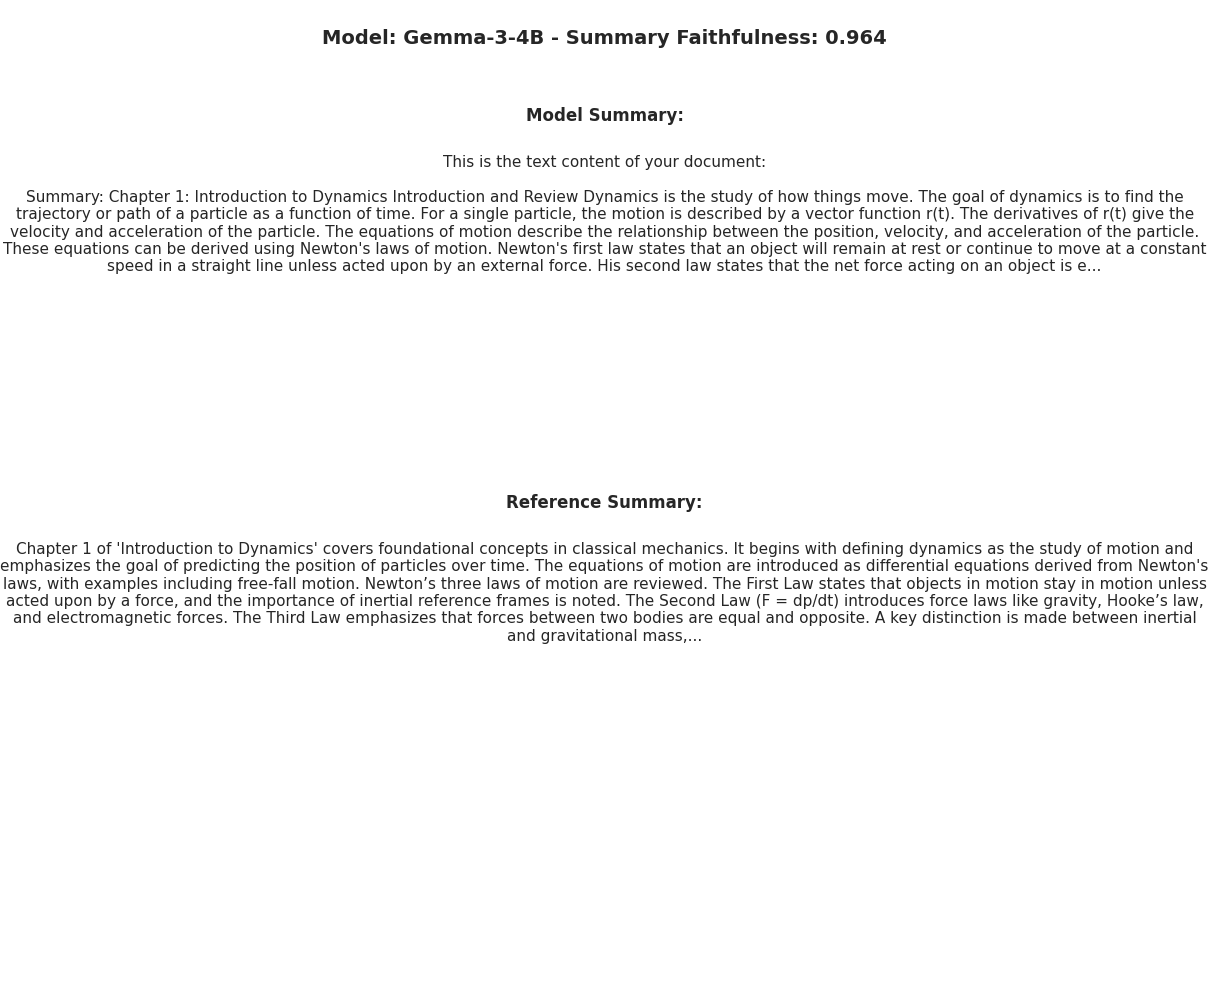

In [ ]:
# 8. Create error visualizations for all models
for model in MODEL_NAMES:
    print(f"\nVisualizing QA errors for {model}:")
    visualize_qa_errors(all_results, model, max_examples=2)

    print(f"\nVisualizing summary errors for {model}:")
    visualize_summary_errors(all_results, model, max_examples=2)

 9. Final Model Comparison Visualizations

 Creating comprehensive visualizations to compare all three models across key metrics.

In [ ]:
def create_comparative_radar_chart():
    """Create a single radar chart comparing all models"""

    # Key metrics to include
    metrics = {
        "BS-F1 (QA)": {"type": "bertscore", "metric": "bertscore_f1", "task": "qa"},
        "BS-F1 (Summary)": {"type": "bertscore", "metric": "bertscore_f1", "task": "summary"},
        "ROUGE-L (QA)": {"type": "rouge", "metric": "rougeL_f", "task": "qa"},
        "ROUGE-L (Summary)": {"type": "rouge", "metric": "rougeL_f", "task": "summary"},
        "RAGAS-Faithfulness (QA)": {"type": "ragas_qa", "metric": "faithfulness", "task": "qa"},
        "RAGAS-Correctness (QA)": {"type": "ragas_qa", "metric": "answer_correctness", "task": "qa"}
    }

    # Collect data for each model
    model_values = {}

    for model in MODEL_NAMES:
        values = []

        for metric_name, metric_info in metrics.items():
            metric_type = metric_info["type"]
            metric = metric_info["metric"]
            task = metric_info["task"]

            if metric_type in ["bertscore", "rouge"]:
                if model in all_results[metric_type]:
                    df = all_results[metric_type][model]
                    task_df = df[df['task'] == task]
                    if not task_df.empty and metric in task_df.columns:
                        values.append(task_df[metric].mean())
                    else:
                        values.append(0)
                else:
                    values.append(0)
            elif metric_type == "ragas_qa":
                if model in all_results["ragas_qa"]:
                    df = all_results["ragas_qa"][model]
                    if not df.empty and metric in df.columns:
                        values.append(df[metric].mean())
                    else:
                        values.append(0)
                else:
                    values.append(0)
            elif metric_type == "ragas_summary":
                if model in all_results["ragas_summary"]:
                    df = all_results["ragas_summary"][model]
                    if not df.empty and metric in df.columns:
                        values.append(df[metric].mean())
                    else:
                        values.append(0)
                else:
                    values.append(0)

        model_values[model] = values

    # Create the radar chart
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, polar=True)

    # Angles for each metric
    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    # Make it a full circle
    angles += angles[:1]

    # Add metric names
    metric_names = list(metrics.keys())
    metric_names += [metric_names[0]]

    # Plot each model
    for model, values in model_values.items():
        # Close the loop
        values += [values[0]]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=MODEL_COLORS.get(model, 'blue'))
        ax.fill(angles, values, alpha=0.1, color=MODEL_COLORS.get(model, 'blue'))

    # Set labels and styling
    ax.set_thetagrids(np.degrees(angles[:-1]), metric_names[:-1], fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title("Model Comparison Across Key Metrics", size=15, pad=20)
    ax.grid(True)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    plt.tight_layout()
    plt.savefig("model_comparison_radar.png", dpi=300, bbox_inches='tight')
    plt.show()

def create_model_comparison_bar_chart(metric_type, specific_metric, task_type, title=None):
    """Create a bar chart comparing all models on a specific metric"""

    # Collect values for each model
    models = []
    values = []

    for model in MODEL_NAMES:
        if metric_type in ["bertscore", "rouge"]:
            if model in all_results[metric_type]:
                df = all_results[metric_type][model]
                task_df = df[df['task'] == task_type]
                if not task_df.empty and specific_metric in task_df.columns:
                    models.append(model)
                    values.append(task_df[specific_metric].mean())
        elif metric_type == "ragas_qa" and task_type == "qa":
            if model in all_results["ragas_qa"]:
                df = all_results["ragas_qa"][model]
                if not df.empty and specific_metric in df.columns:
                    models.append(model)
                    values.append(df[specific_metric].mean())
        elif metric_type == "ragas_summary" and task_type == "summary":
            if model in all_results["ragas_summary"]:
                df = all_results["ragas_summary"][model]
                if not df.empty and specific_metric in df.columns:
                    models.append(model)
                    values.append(df[specific_metric].mean())

    if models and values:
        plt.figure(figsize=(10, 6))

        # Create bars
        bars = plt.bar(models, values, color=[MODEL_COLORS.get(model, 'blue') for model in models])

        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)

        # Add labels and title
        plt.ylabel(specific_metric)
        metric_display = specific_metric.replace('_', ' ').title().replace('Bertscore', 'BERTScore')
        if title:
            plt.title(title)
        else:
            plt.title(f'{metric_display} Comparison - {task_type.title()} Task')

        # Add grid
        plt.grid(axis='y', linestyle='--', alpha=0.7)

        # Improve layout
        plt.tight_layout()

        # Save the figure
        plt.savefig(f"model_comparison_{specific_metric}_{task_type}.png", dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print(f"Not enough data for model comparison on {specific_metric} for {task_type} task")

Creating final model comparison visualizations...


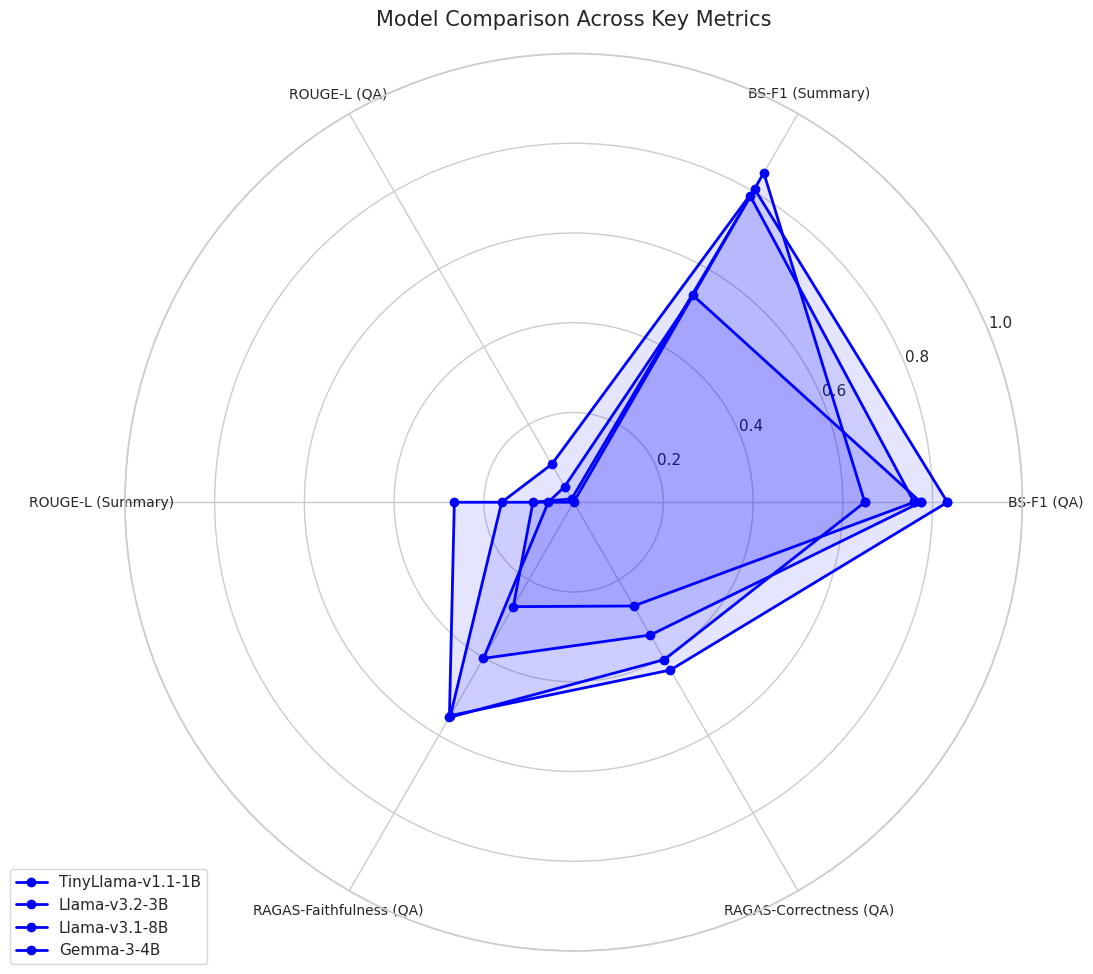

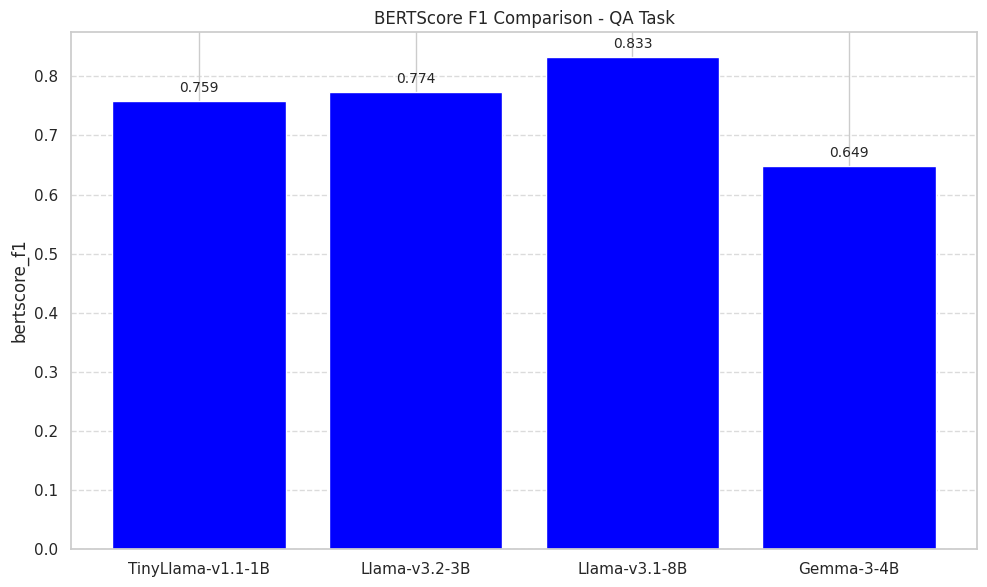

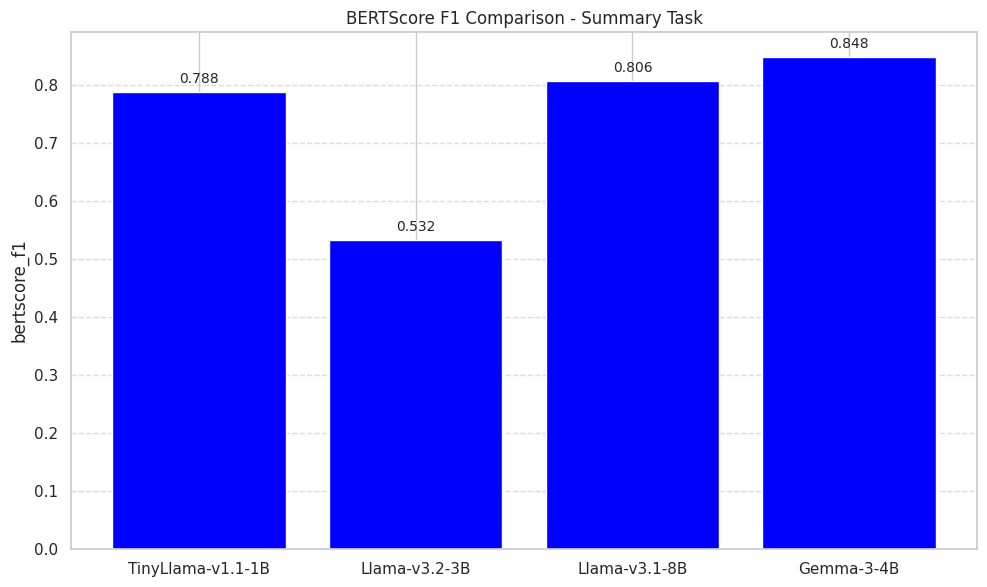

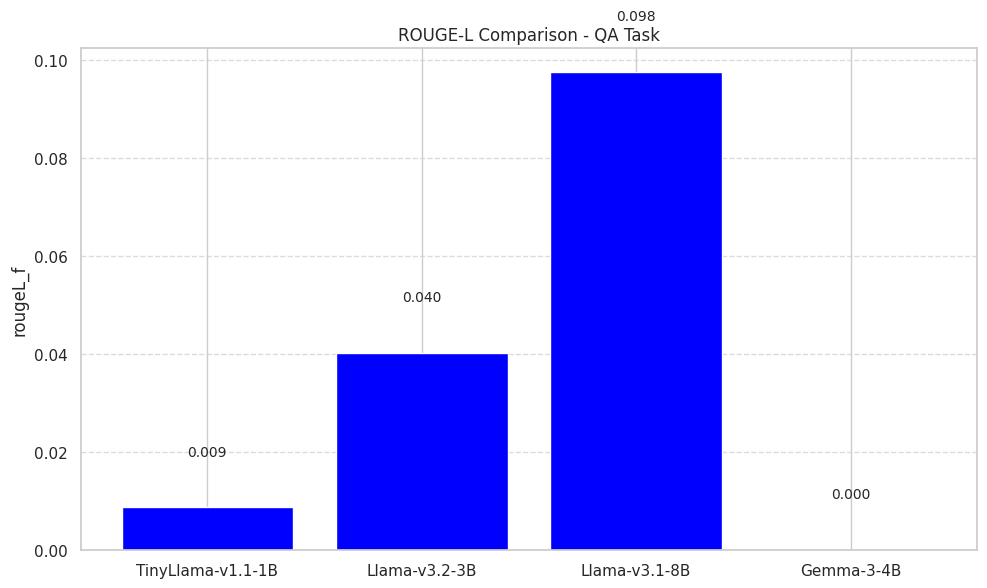

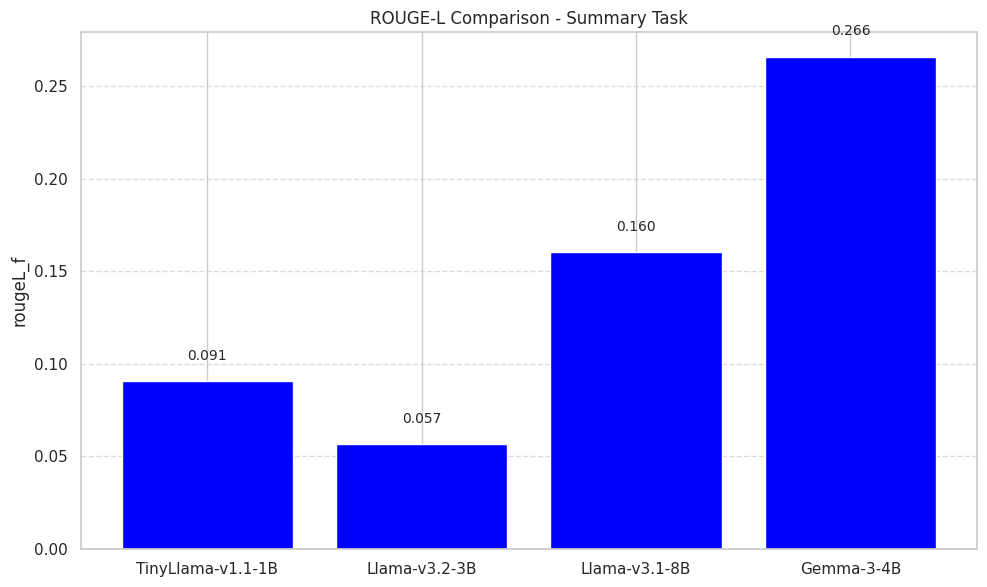

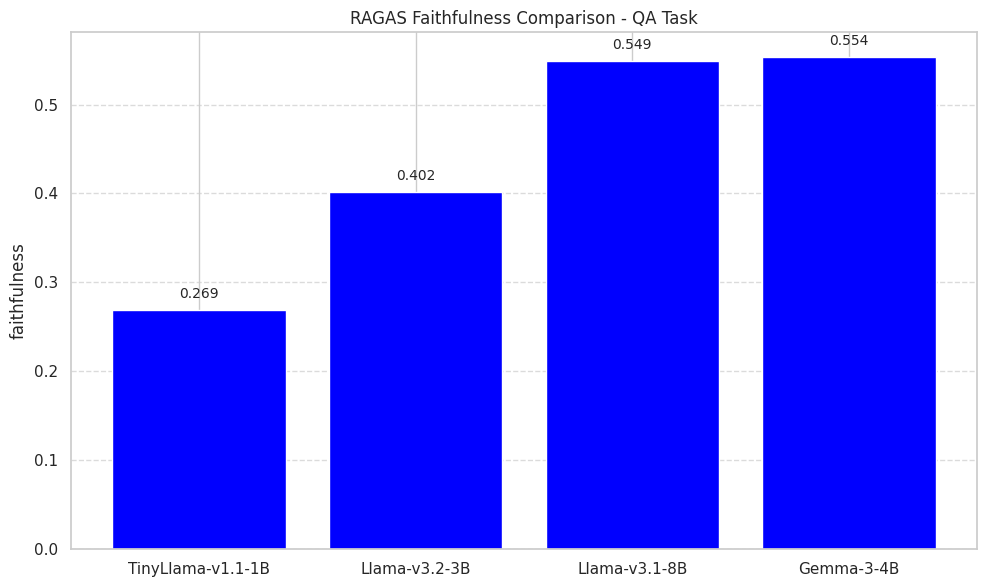

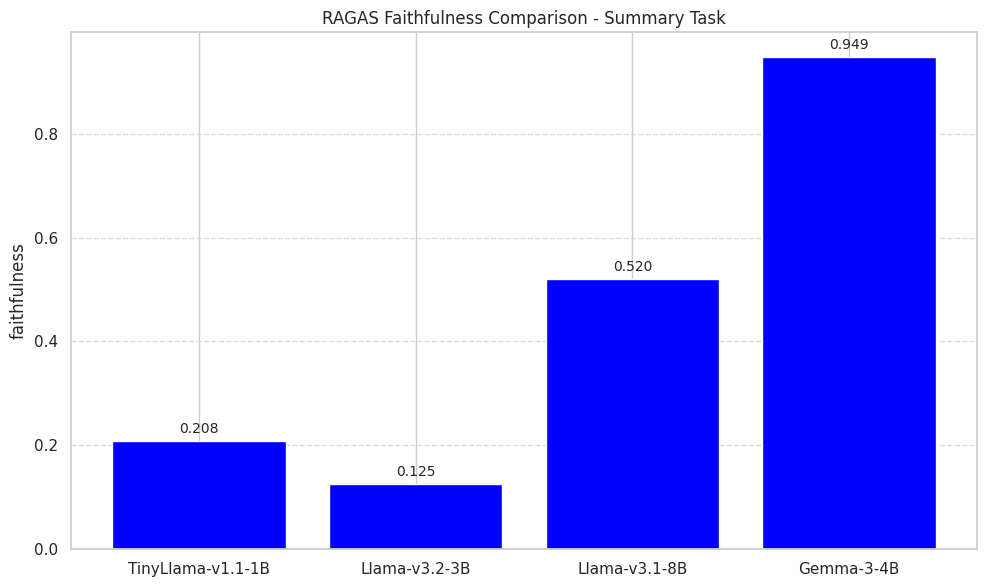

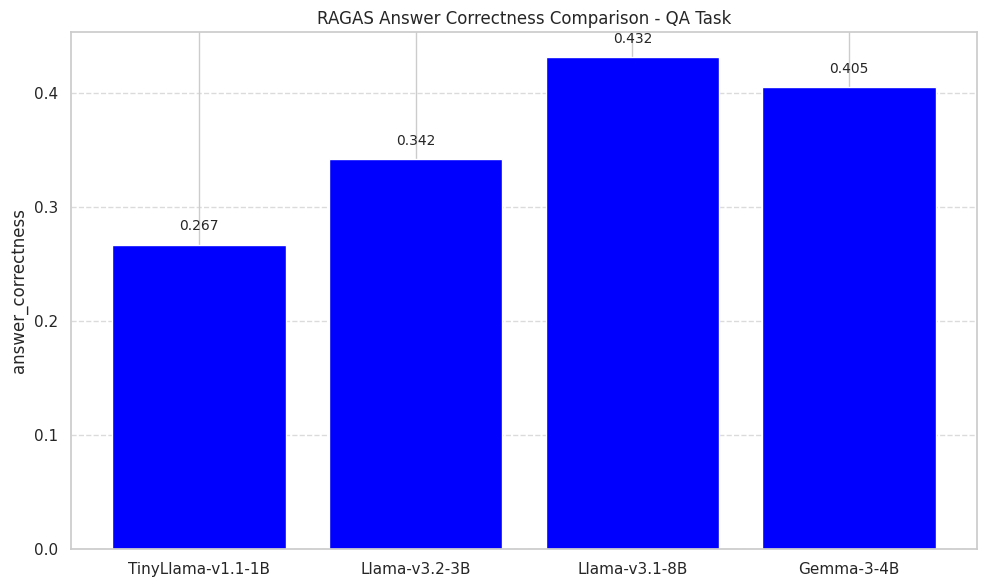

All model comparison visualizations complete!


In [ ]:

# 9. Create the final comparison visualizations
print("Creating final model comparison visualizations...")

# Create comparative radar chart with all models
create_comparative_radar_chart()

# Create bar charts for key metrics
# BERTScore F1
create_model_comparison_bar_chart("bertscore", "bertscore_f1", "qa", "BERTScore F1 Comparison - QA Task")
create_model_comparison_bar_chart("bertscore", "bertscore_f1", "summary", "BERTScore F1 Comparison - Summary Task")

# ROUGE-L
create_model_comparison_bar_chart("rouge", "rougeL_f", "qa", "ROUGE-L Comparison - QA Task")
create_model_comparison_bar_chart("rouge", "rougeL_f", "summary", "ROUGE-L Comparison - Summary Task")

# RAGAS Faithfulness
create_model_comparison_bar_chart("ragas_qa", "faithfulness", "qa", "RAGAS Faithfulness Comparison - QA Task")
create_model_comparison_bar_chart("ragas_summary", "faithfulness", "summary", "RAGAS Faithfulness Comparison - Summary Task")

# RAGAS Correctness
create_model_comparison_bar_chart("ragas_qa", "answer_correctness", "qa", "RAGAS Answer Correctness Comparison - QA Task")

print("All model comparison visualizations complete!")